In [1]:
import torch
import torchvision
from diffusers import DDPMScheduler, UNet2DModel, UNet2DConditionModel
from torch.optim.lr_scheduler import ReduceLROnPlateau
from matplotlib import pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm
import sys
import requests
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\PC\Desktop\ML_Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
class PhysicsDataset(torch.utils.data.Dataset):
    """
    one element: (energy deposit, (point, momentum))
    """
    def __init__(self, energy: torch.Tensor, condition: torch.Tensor,
                 transform=None, inverse_transform=None) -> None:
        self.transform = transform
        self.inverse_transform = inverse_transform  # for outer use

        if transform is not None:
            energy = self.transform(energy)

        self.energy = energy
        self.physic_condition = condition

    def __getitem__(self, idx: int) -> tuple:
        return self.energy[idx], self.physic_condition[idx]

    def __len__(self) -> int:
        return self.energy.shape[0]

# принимают batch-и x-ов
def log1p_transform(x: torch.Tensor):
    return torch.log1p(x)


def log1p_inverse_transform(x: torch.Tensor):
    return torch.expm1(x)

def get_physics_dataset(path: str, train: bool = True, val_ratio: float = 0.5,
                        log1p_energy: bool = True) -> torch.utils.data.Dataset:

    """
    Получение данных из файла .npz и формирование датасета для обучения. 
    Данные получаются из файла все, но на обучение идет только импульс и координаты
    """
    TRAIN_VAL_SPLIT_SEED = 0x3df3fa

    data_train = np.load(path)

    np.random.seed(TRAIN_VAL_SPLIT_SEED)
    dataset_size = len(data_train['EnergyDeposit'])
    val_size = int(dataset_size * val_ratio)

    all_indices = np.arange(dataset_size)
    val_indices = np.random.choice(all_indices, size=val_size, replace=False)
    val_mask = np.zeros(dataset_size, dtype=bool)
    val_mask[val_indices] = True
    train_indices = all_indices[~val_mask]
    indices = train_indices if train else val_indices

    energy = torch.tensor(data_train['EnergyDeposit'][indices]).float()
    energy = torch.permute(energy, dims=(0, 3, 1, 2))
    
    momentum = torch.tensor(data_train['ParticleMomentum'][indices]).float()
    momentum_norm = momentum / torch.norm(momentum, dim=1, keepdim=True) # нормировка
    pt = np.sqrt(momentum[:, 0]**2 + momentum[:, 1]**2)
    eta = - np.log(pt/momentum[:, 2])
    phi = np.arctan2(momentum[:, 0], momentum[:, 1])
    momentum_cyl = torch.stack([pt, eta, phi], dim=1) 
    
    total_energy_sci = torch.tensor(data_train['TotalEnergySci'][indices]).float()
    total_energy_sci_min_val = total_energy_sci.min()
    total_energy_sci_max_val = total_energy_sci.max()
    total_energy_sci_norm = (total_energy_sci/total_energy_sci_max_val).unsqueeze(1)  # [0, 1]

    total_energy_absorb = torch.tensor(data_train['TotalEnergyAbsorb'][indices]).float()
    total_energy_absorb_min_val = total_energy_absorb.min()
    total_energy_absorb_max_val = total_energy_absorb.max()
    total_energy_absorb_norm = (total_energy_absorb/total_energy_absorb_max_val).unsqueeze(1)  # [0, 1]

    point = torch.tensor(data_train['ParticlePoint'][indices]).float()
    point_norm = point / torch.norm(point, dim=1, keepdim=True) # нормировка

    
    
    physic_condition = torch.cat([momentum_norm,
                                  momentum_cyl,
                                    point_norm
                                    ], dim=1)  # (N, 8)
    transform, inverse_transform = None, None
    if log1p_energy:
        transform = log1p_transform
        inverse_transform = log1p_inverse_transform

    return PhysicsDataset(energy,
                          physic_condition,
                          transform=transform, inverse_transform=inverse_transform)

In [3]:
data_filepath = r"C:\Users\PC\Desktop\ML_Projects\data\caloGAN_case11_5D_120K.npz"
train_dataset = get_physics_dataset(data_filepath, train=True)
valid_dataset = get_physics_dataset(data_filepath, train=False)

C:\Users\PC\AppData\Local\Temp\ipykernel_15636\3403089306.py:57: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pt = np.sqrt(momentum[:, 0]**2 + momentum[:, 1]**2)
C:\Users\PC\AppData\Local\Temp\ipykernel_15636\3403089306.py:58: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  eta = - np.log(pt/momentum[:, 2])
C:\Users\PC\AppData\Local\Temp\ipykernel_15636\3403089306.py:59: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.arctan2(momentum[:, 0], momentum[:, 1])


In [ ]:
infer_batch_size = 64 

train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True,
    num_workers=4,        
    pin_memory=True,      
    prefetch_factor=2     
)

num_batches = 100
num_samples = infer_batch_size * num_batches 
valid_subset = Subset(valid_dataset, indices=range(min(num_samples, len(valid_dataset))))

valid_loader = DataLoader(
    valid_subset, 
    batch_size=infer_batch_size, 
    shuffle=False,        
    num_workers=0,        
    pin_memory=True       
)

In [5]:
sys.path.append('Calolib')
from pipeline.metrics import *
from pipeline.physical_metrics.calogan_prd import get_energy_embedding
from pipeline.physical_metrics import calogan_metrics
from pipeline.physical_metrics.prd_score import compute_prd_from_embedding, prd_to_max_f_beta_pair
from pipeline import calodiff
from visualization_aux.visualize_physics import energy_imshow 

In [6]:
class ConditionedUNet(nn.Module):
    def __init__(
        self, 
        image_size: int = 30, 
        cond_emb_size: int = 9, 
        cross_attention_dim: int = 128,
        layers_per_block: int = 2,
        block_out_channels: tuple = (32, 64, 128),
        down_block_types: tuple = ("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        up_block_types: tuple = ("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        norm_num_groups: int = 32
    ):
        """
        A UNet model conditioned via cross-attention with configurable architecture.
        """
        super().__init__()

        self.image_size = image_size
        self.cond_emb_size = cond_emb_size
        self.internal_size = image_size + 2
        
        self.cond_projection = nn.Linear(cond_emb_size, cross_attention_dim)
        
        self.model = UNet2DConditionModel(
            sample_size=self.internal_size,
            in_channels=1,
            out_channels=1,
            layers_per_block=layers_per_block,
            block_out_channels=block_out_channels,
            down_block_types=down_block_types,
            up_block_types=up_block_types,
            cross_attention_dim=cross_attention_dim,
            norm_num_groups=norm_num_groups
        )

    def forward(self, x, t, condition):
        bs = x.shape[0]
        padded_x = torch.nn.functional.pad(x, (1, 1, 1, 1)) # [bs, 1, 32, 32]
        
        condition_emb = self.cond_projection(condition)
        condition_emb = condition_emb.view(bs, 1, -1)
        
        predicted_noise = self.model(
            sample=padded_x,
            timestep=t,
            encoder_hidden_states=condition_emb
        ).sample
        
        return predicted_noise[:, :, 1:-1, 1:-1]

In [ ]:
MODEL_CONFIGS = {
    "model_1": {},
    
    "model_2": {
        "layers_per_block": 1,
        "block_out_channels": (32, 64, 128),
        "down_block_types": ("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        "norm_num_groups": 32,
        "cross_attention_dim": 128
    },
    "model_3": {
        "layers_per_block": 1,
        "block_out_channels": (24, 48, 96),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 24,
        "cross_attention_dim": 128
    },
    "model_5": {
        "layers_per_block": 1,
        "block_out_channels": (4, 8, 16),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 4,
        "cross_attention_dim": 16
    },
    "model_4": {
        "layers_per_block": 1,
        "block_out_channels": (8, 16, 32),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 4,
        "cross_attention_dim": 128
    }
}

MODEL_PATHS = {'model_1': r'C:\Users\PC\Desktop\ML_Projects\data\best_model_on_train_rmsprop.pth',
               'model_2': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 2.pth",
               'model_3': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 5.pth",
               'model_4': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 50.pth",
               'model_5': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 100.pth"
              }

In [8]:
def get_power_schedule(n_total_steps, n_inference_steps, power):
    """
    Генерирует список шагов по степенному закону.
    
    n_total_steps: всего шагов обучения (например, 100)
    n_inference_steps: сколько раз хотим вызвать модель (например, 10)
    power: степень. 
           1.0 = равномерно. 
           >1.0 = гуще около 0 (уточнение деталей).
           <1.0 = гуще около T (работа с структурой шума).
    """
    x = np.linspace(0, 1, n_inference_steps + 1)
    y = x ** power
    indices = (y * (n_total_steps - 1)).astype(int)
    steps = sorted(list(set(indices)), reverse=True)
    if 0 not in steps:
        steps[-1] = 0
        
    return steps

generated_images = sample(
                model, 
                y_test, 
                n_inference_steps, 
                device,
                noise_scheduler_fn, 
                shape=x_test_real.shape[1:],
                sampling_method="ddim" 
                  )

Запуск серии экспериментов. Фиксированная степень: 1.5

Evaluating model_2...
  -> Testing 50 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(96), np.int64(93), np.int64(90), np.int64(87), np.int64(84), np.int64(81), np.int64(78), np.int64(76), np.int64(73), np.int64(70), np.int64(68), np.int64(65), np.int64(63), np.int64(60), np.int64(57), np.int64(55), np.int64(53), np.int64(50), np.int64(48), np.int64(46), np.int64(43), np.int64(41), np.int64(39), np.int64(37), np.int64(35), np.int64(32), np.int64(30), np.int64(28), np.int64(26), np.int64(25), np.int64(23), np.int64(21), np.int64(19), np.int64(17), np.int64(16), np.int64(14), np.int64(13), np.int64(11), np.int64(10), np.int64(8), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_2_power_1.5_steps_50.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9735
PRD Physics AUC: -0.9110
------------------------------------


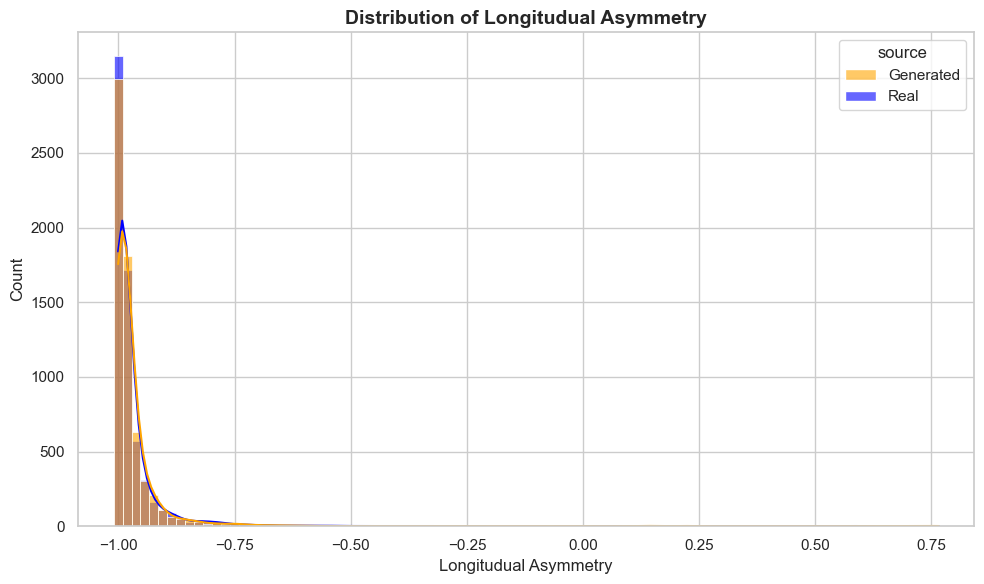

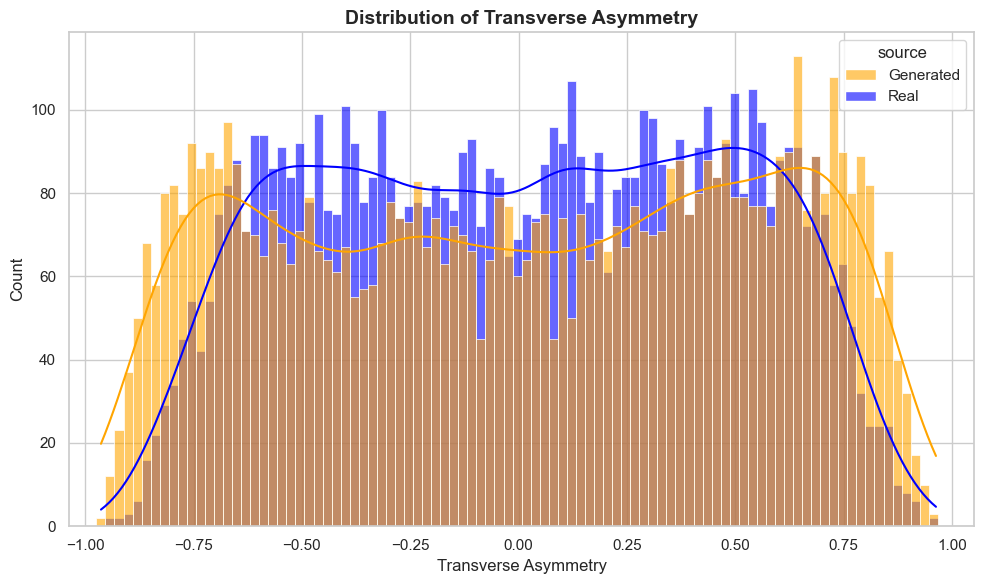

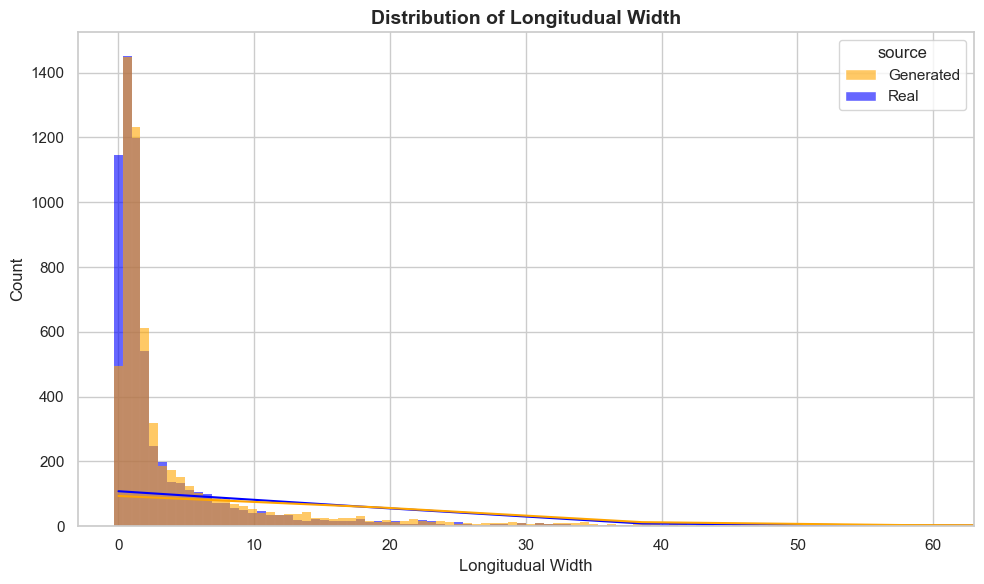

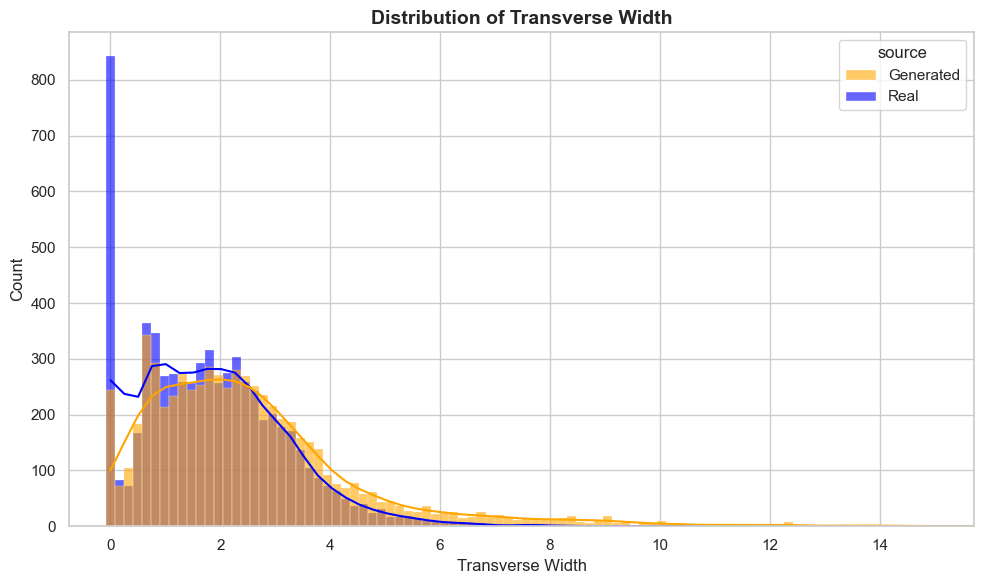

Energy PRD Curve


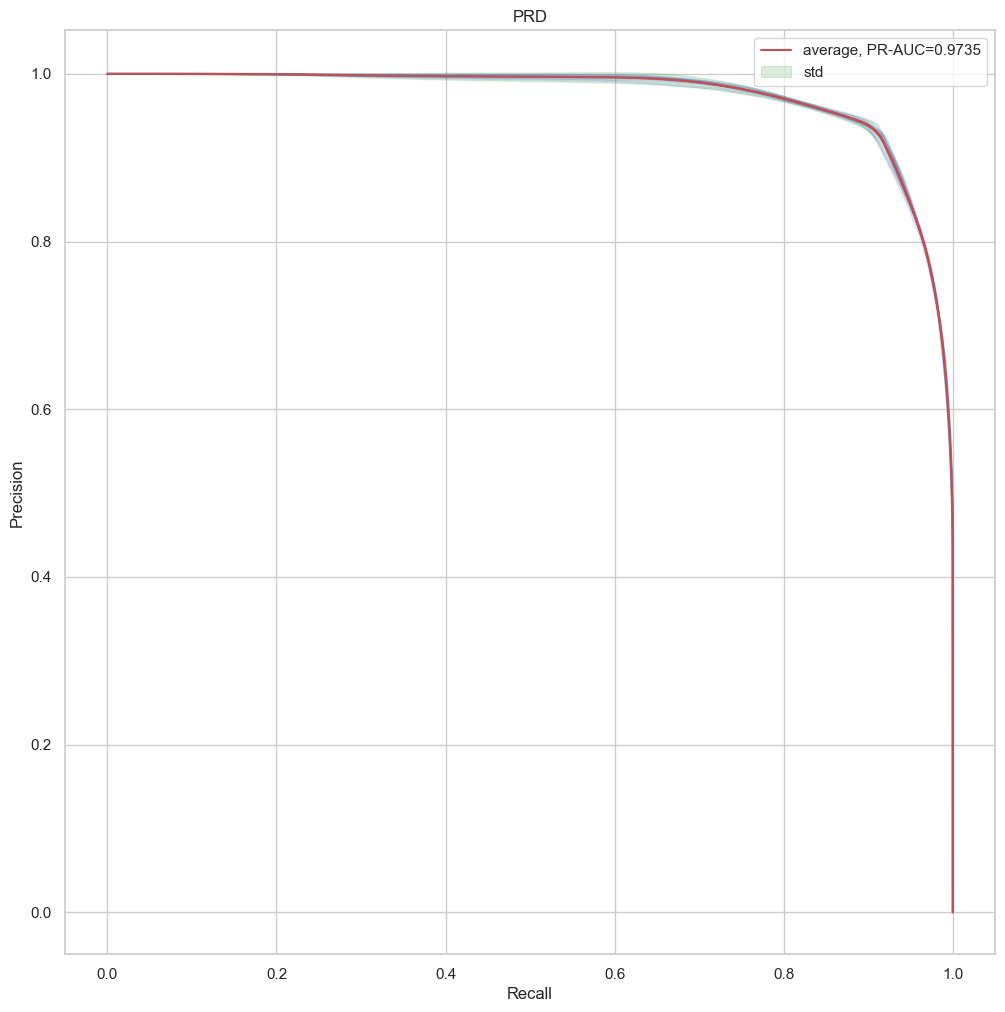

Physics PRD Curve


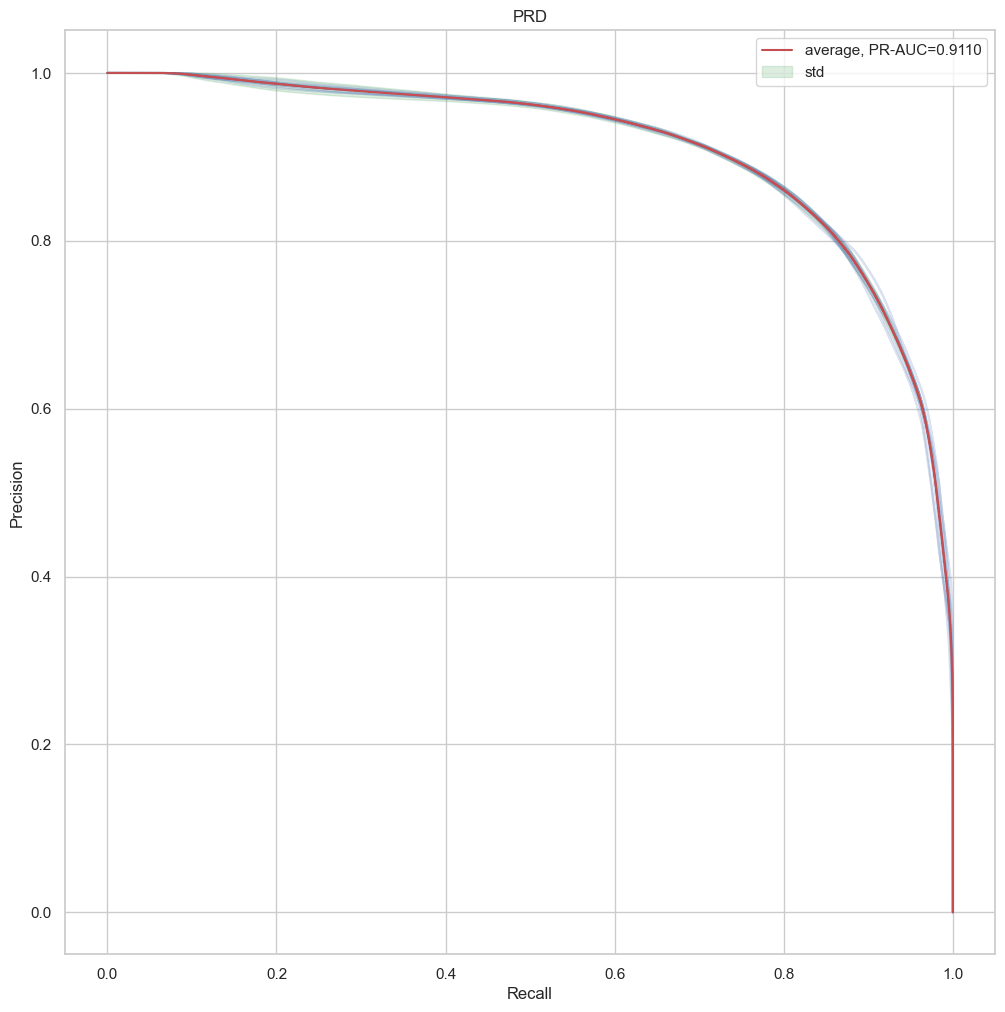

  -> Testing 25 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(93), np.int64(87), np.int64(81), np.int64(76), np.int64(70), np.int64(65), np.int64(60), np.int64(55), np.int64(50), np.int64(46), np.int64(41), np.int64(37), np.int64(32), np.int64(28), np.int64(25), np.int64(21), np.int64(17), np.int64(14), np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(2), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:46<00:00,  2.14it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_2_power_1.5_steps_25.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9799
PRD Physics AUC: -0.9154
------------------------------------


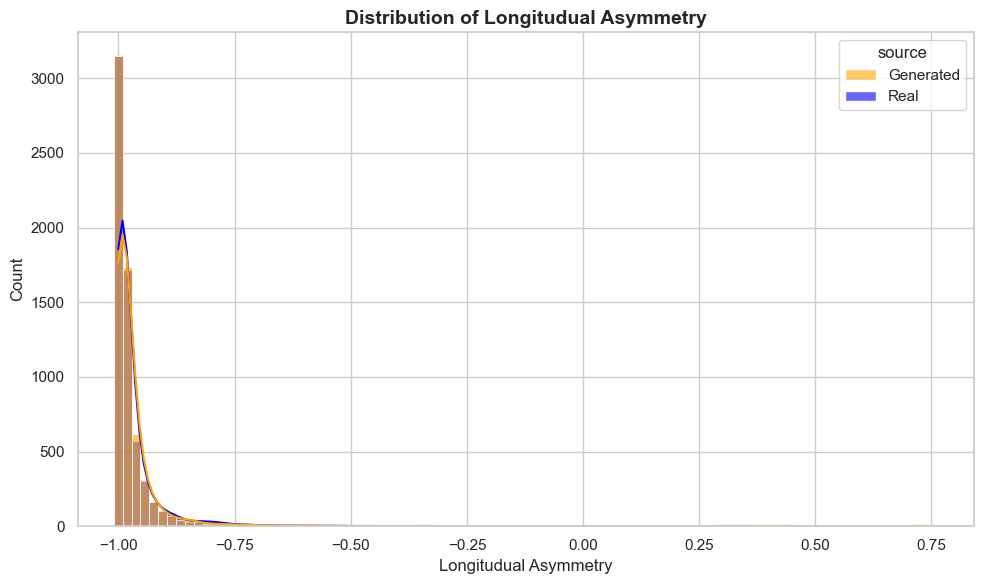

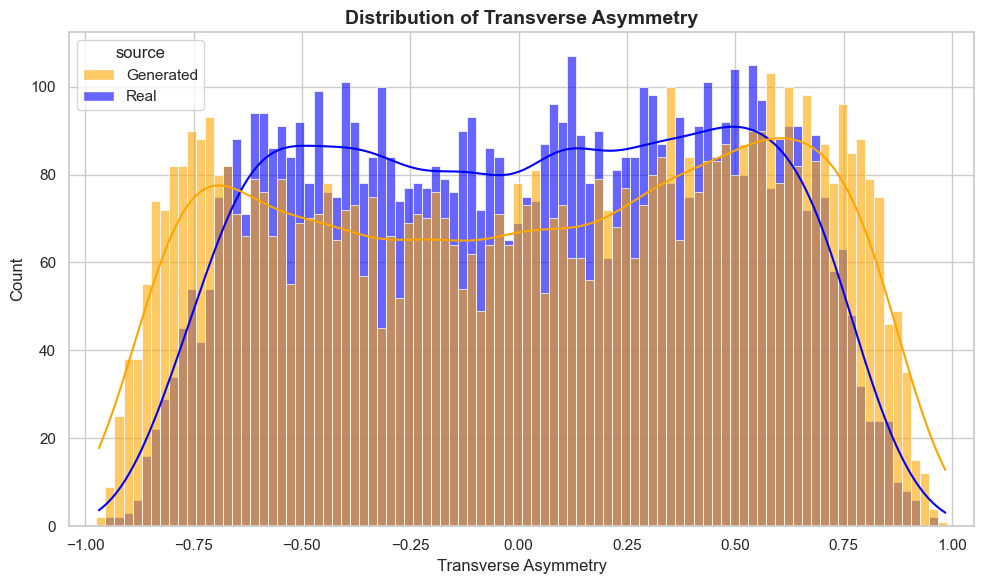

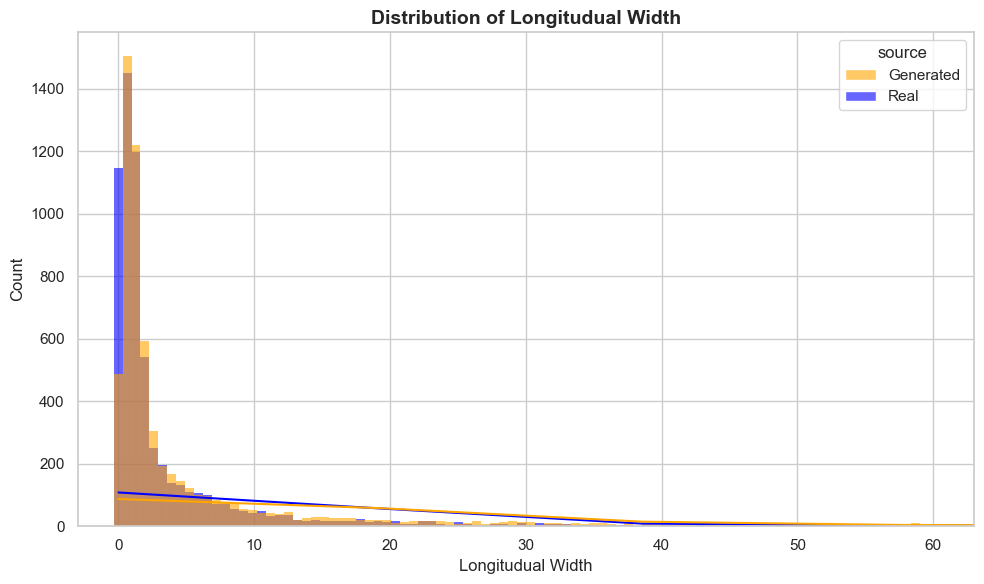

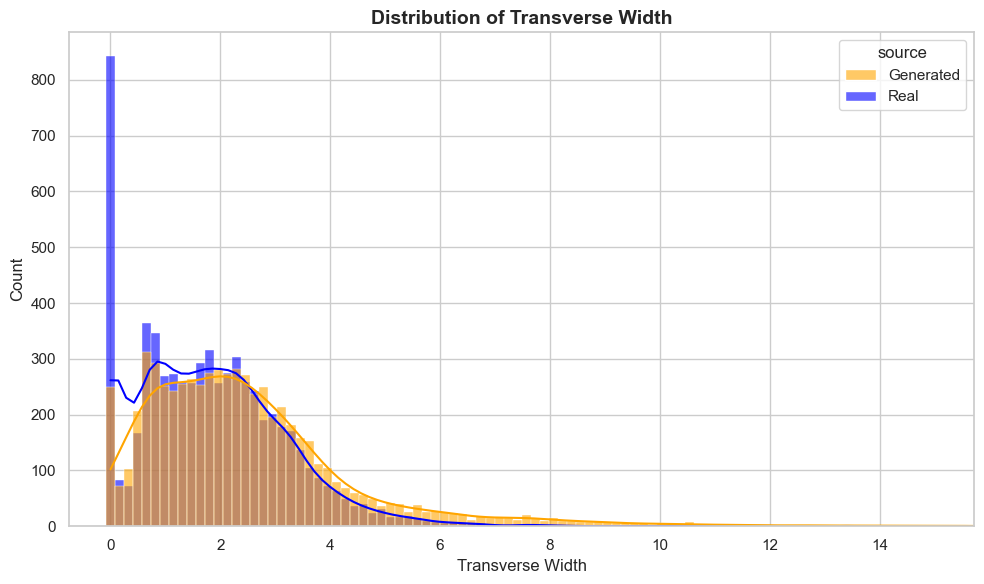

Energy PRD Curve


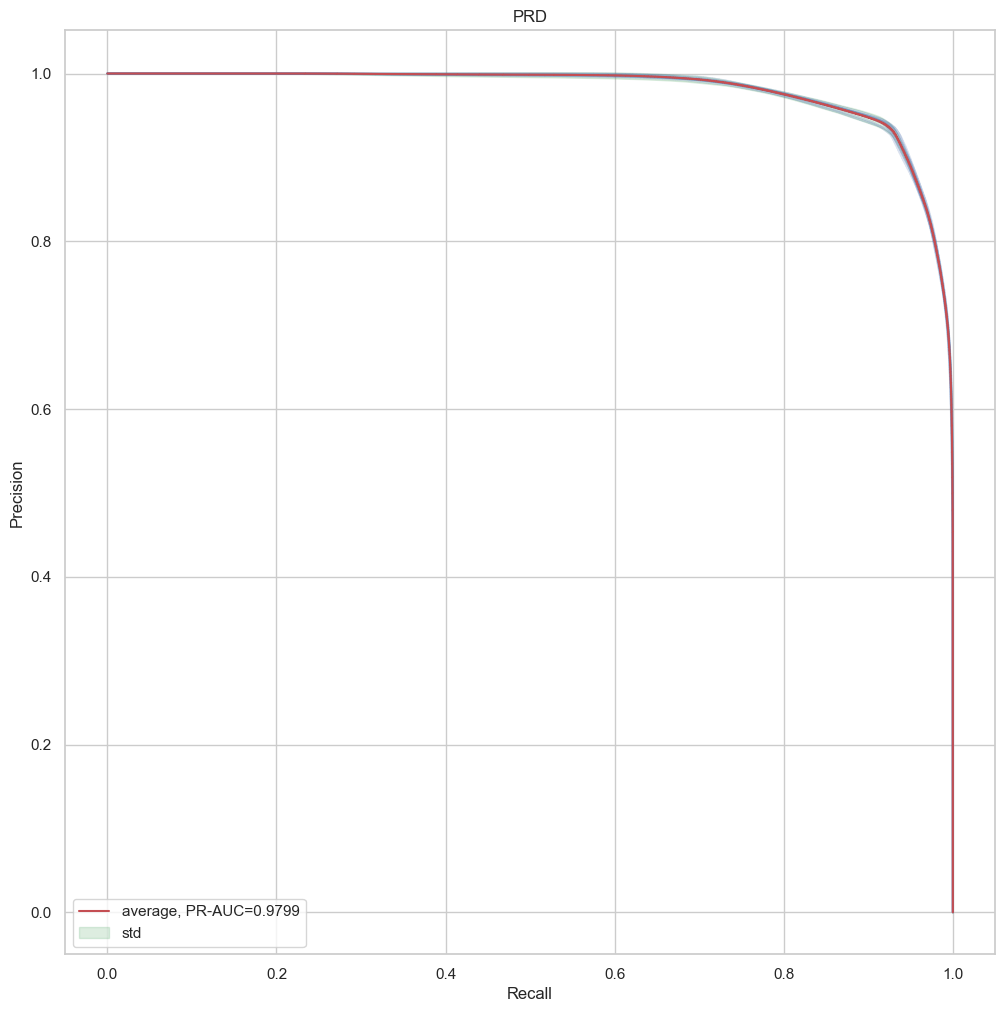

Physics PRD Curve


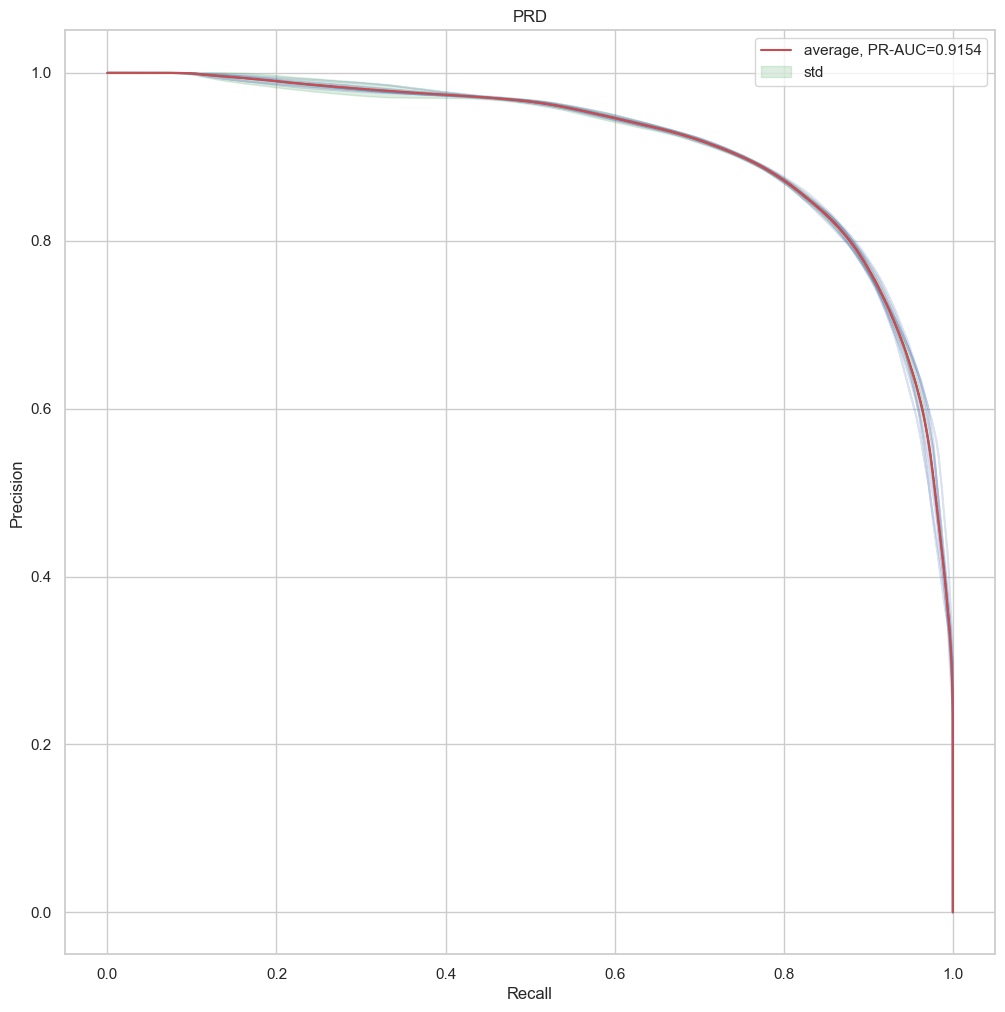

  -> Testing 15 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(89), np.int64(79), np.int64(70), np.int64(62), np.int64(53), np.int64(46), np.int64(38), np.int64(31), np.int64(25), np.int64(19), np.int64(13), np.int64(8), np.int64(4), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_2_power_1.5_steps_15.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9817
PRD Physics AUC: -0.9167
------------------------------------


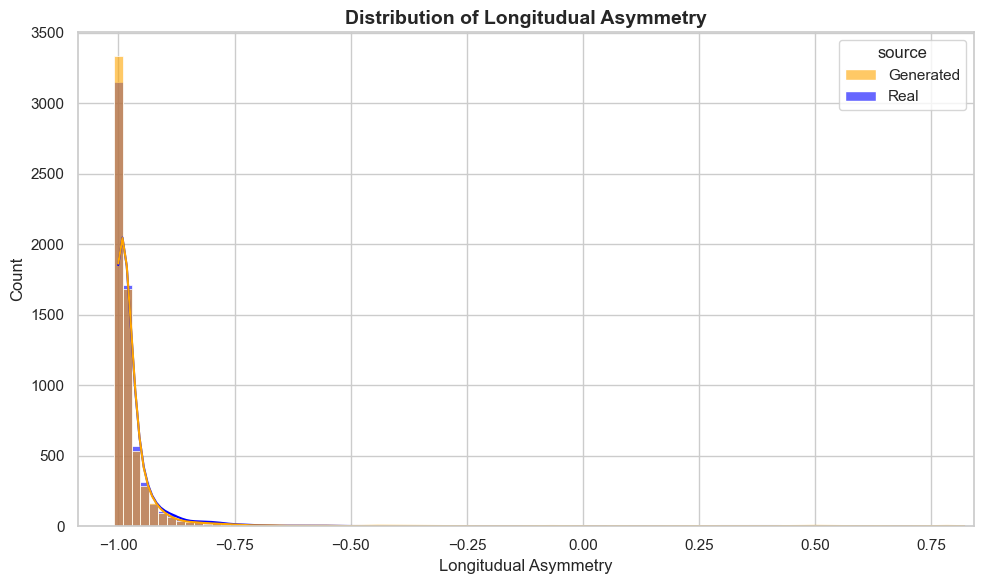

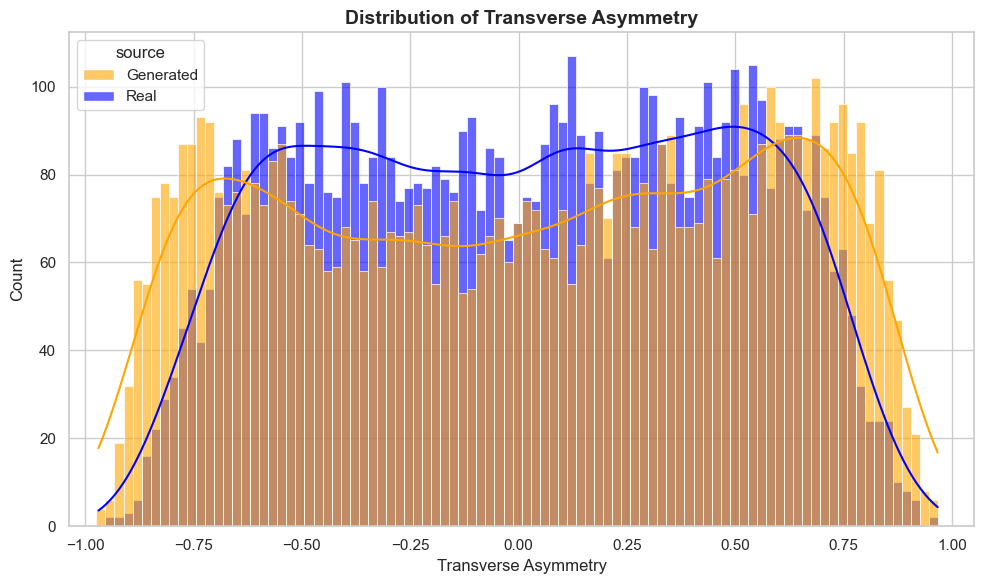

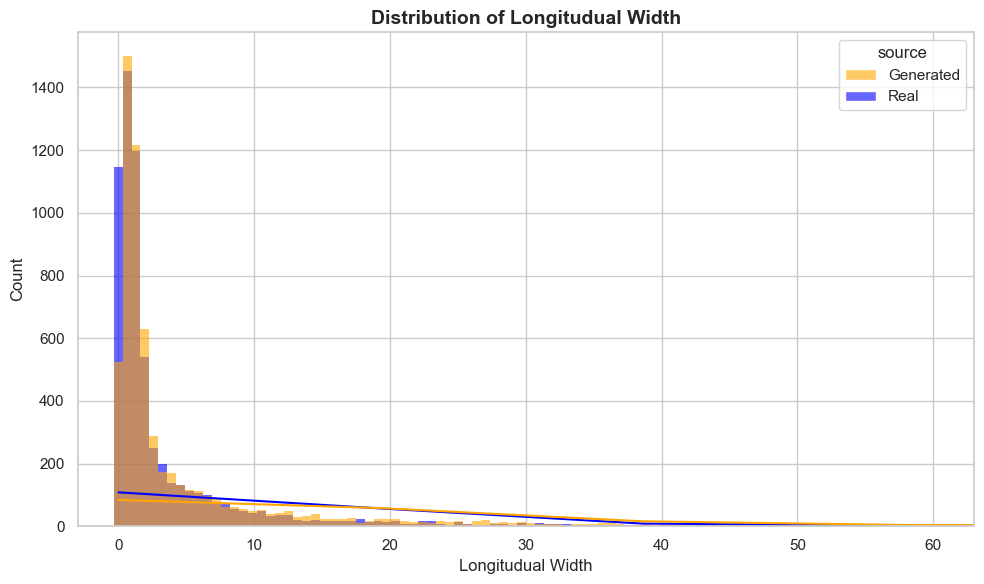

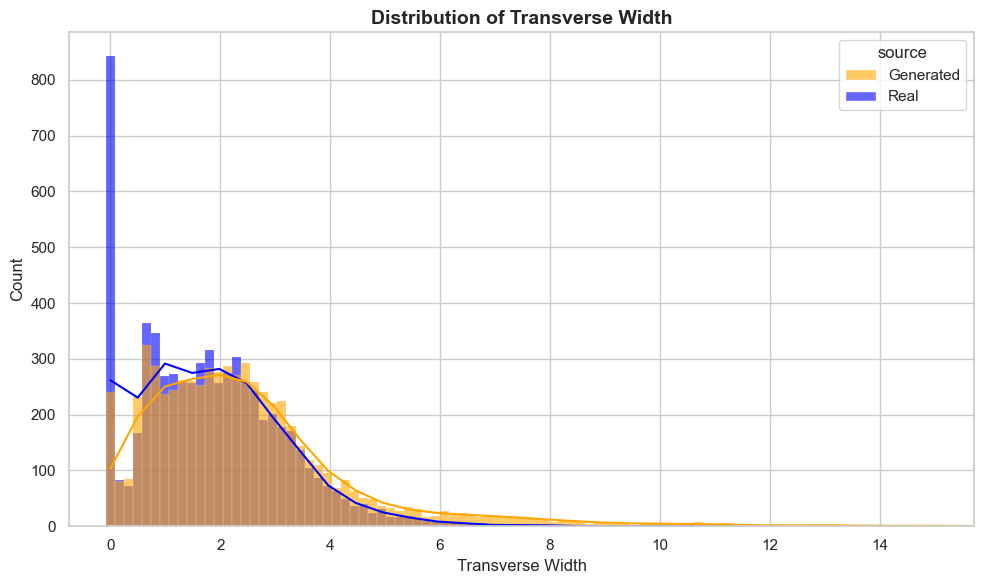

Energy PRD Curve


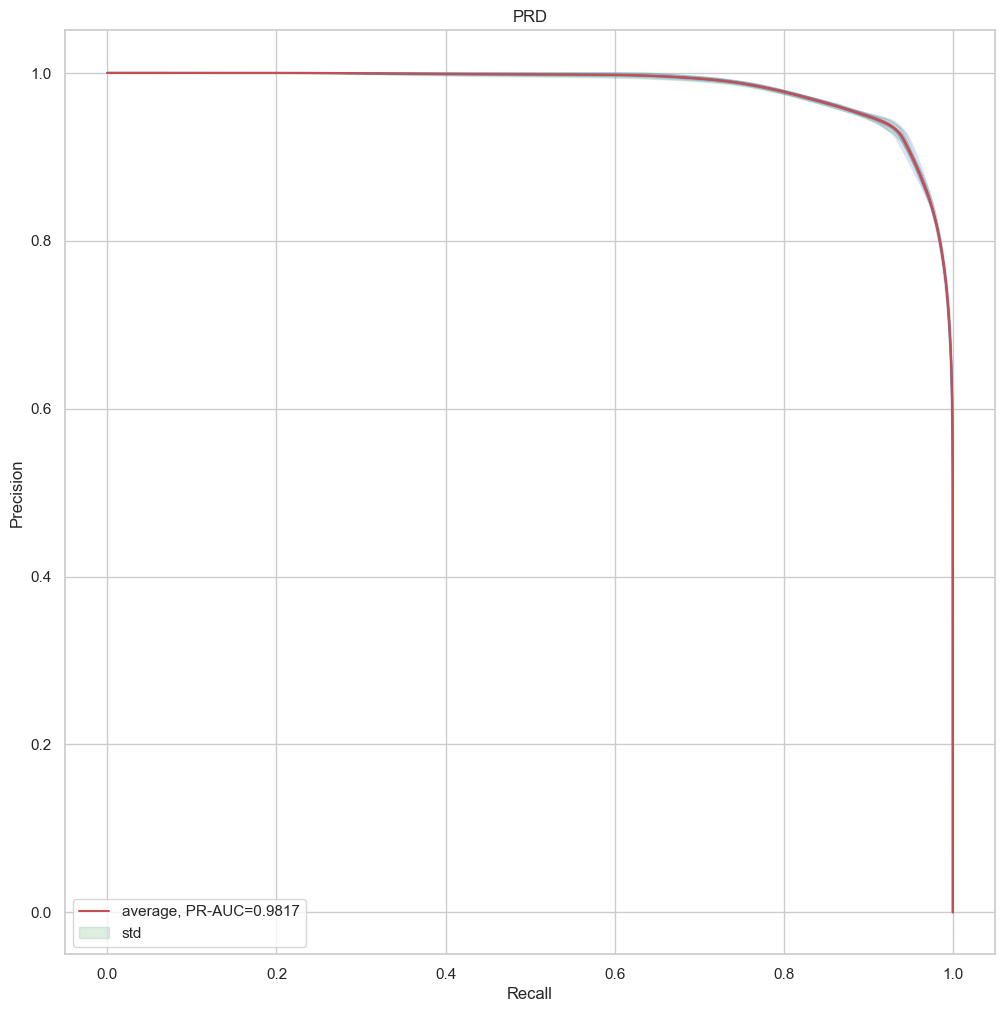

Physics PRD Curve


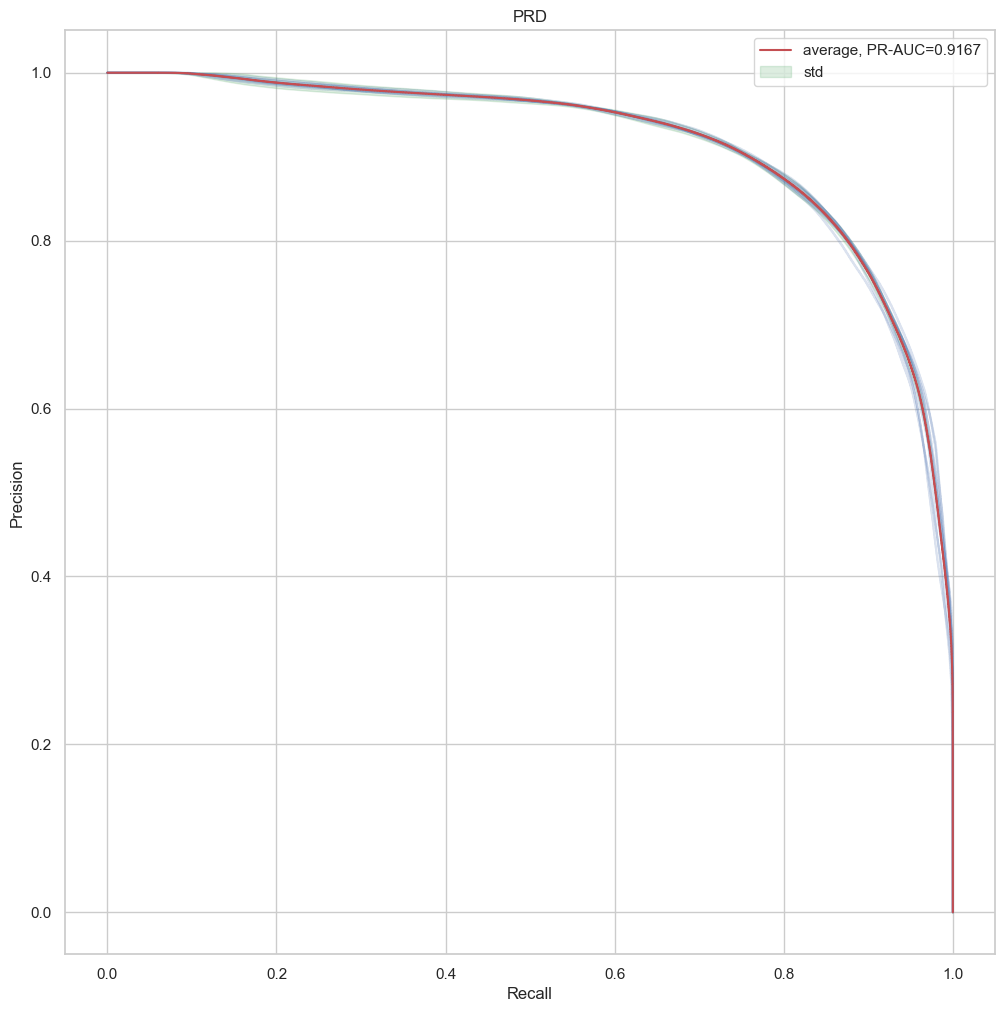

  -> Testing 10 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(84), np.int64(70), np.int64(57), np.int64(46), np.int64(35), np.int64(25), np.int64(16), np.int64(8), np.int64(3), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:19<00:00,  5.15it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_2_power_1.5_steps_10.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9848
PRD Physics AUC: -0.9166
------------------------------------


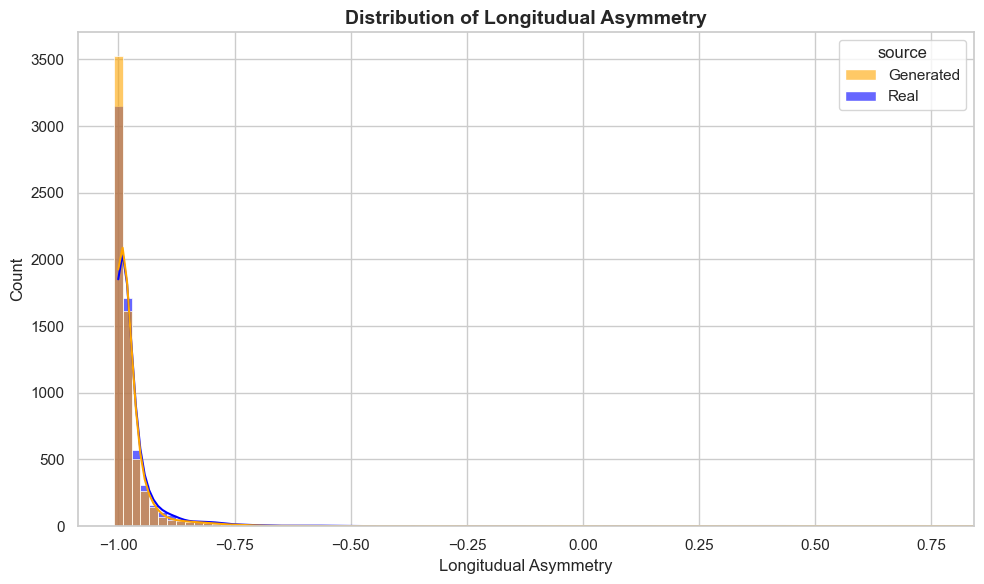

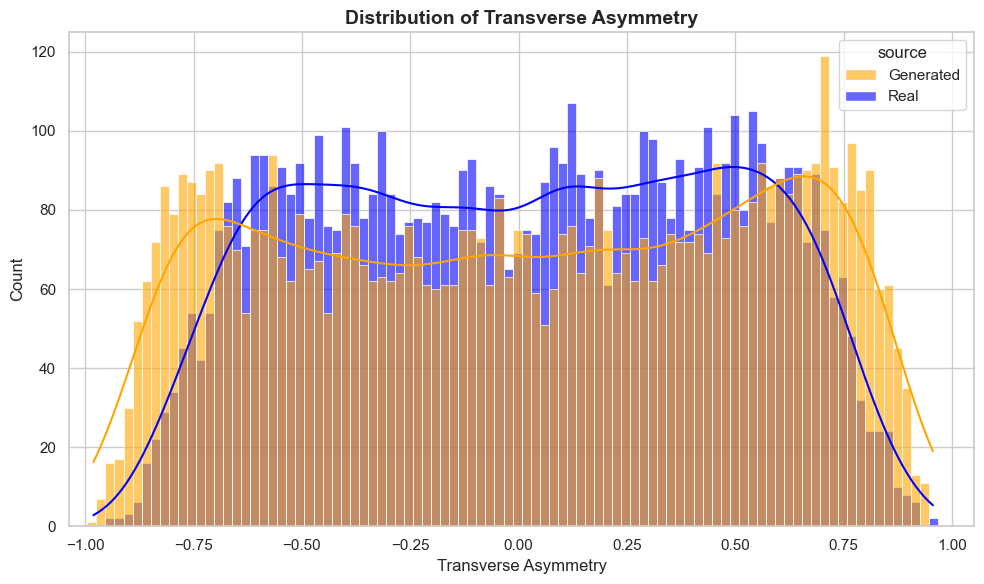

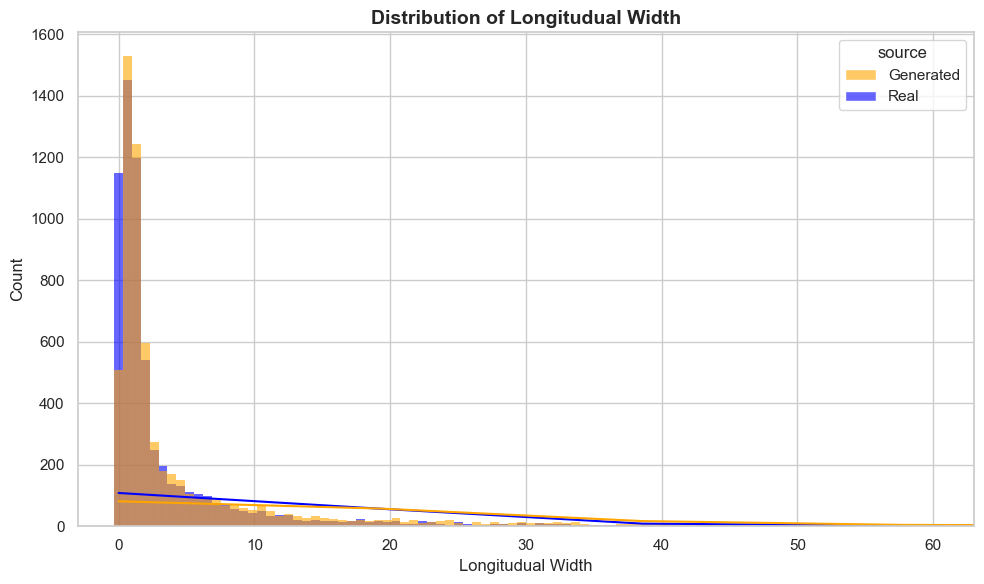

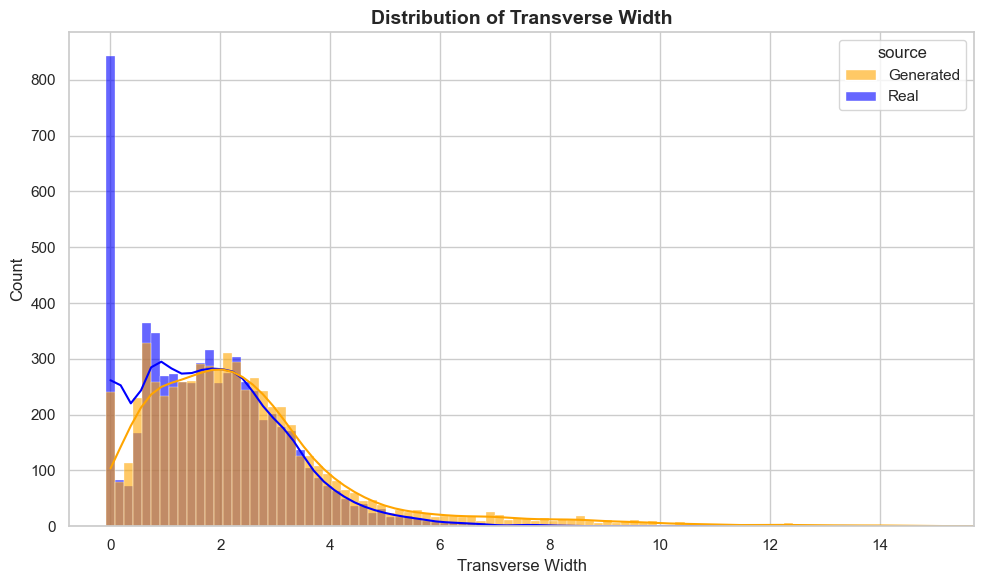

Energy PRD Curve


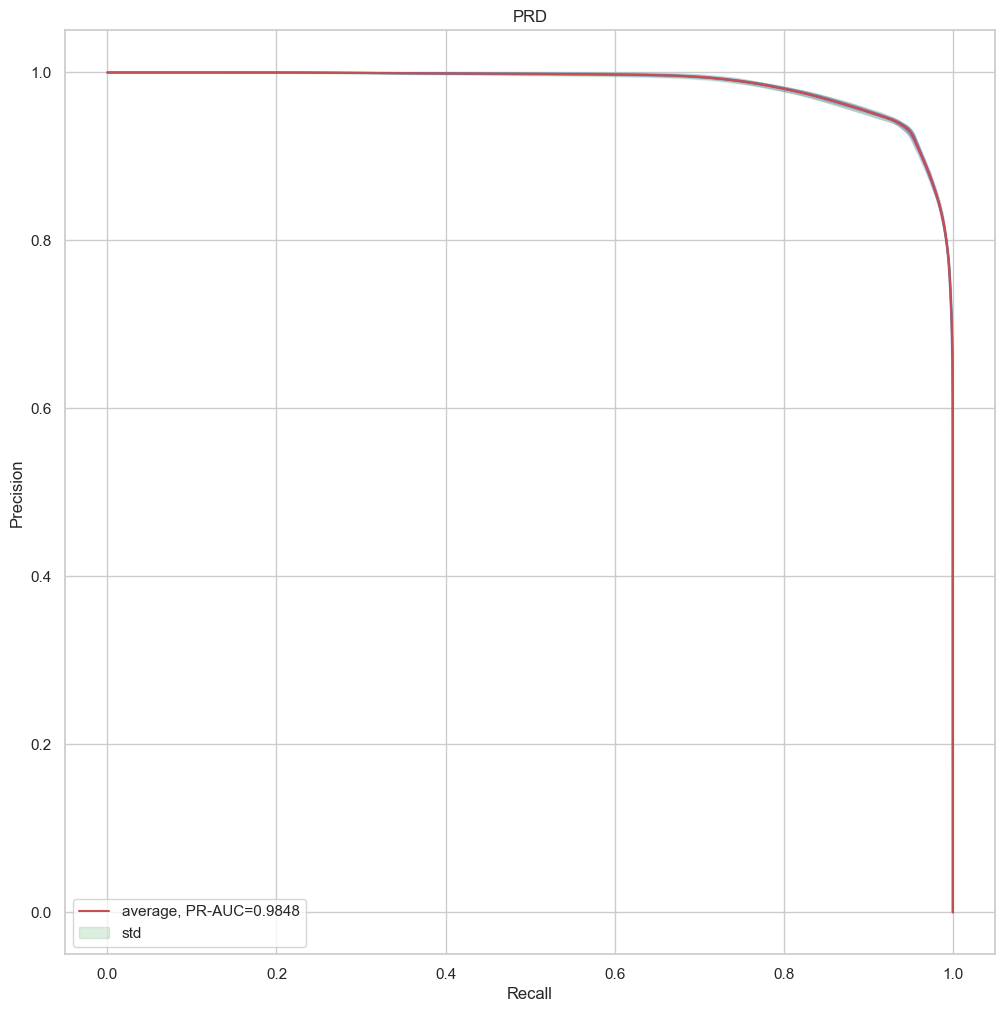

Physics PRD Curve


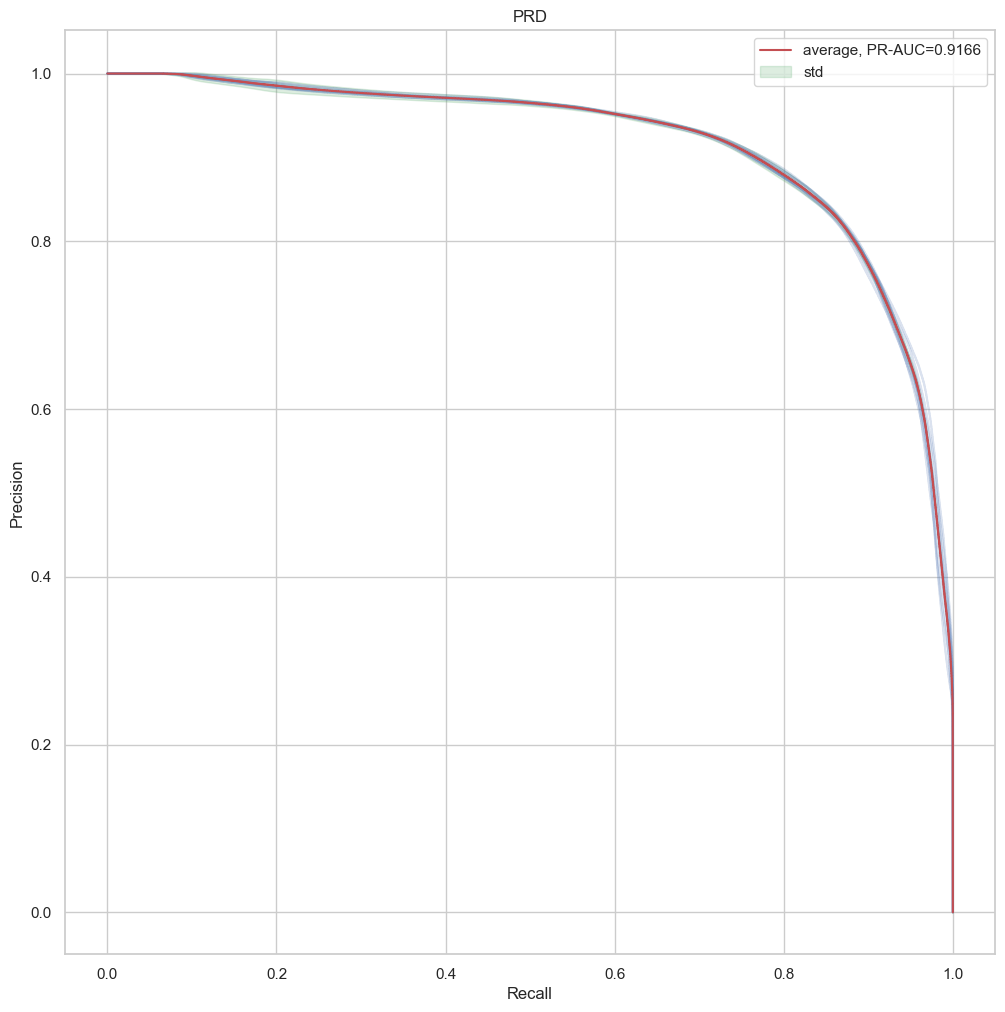


Evaluating model_3...
  -> Testing 50 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(96), np.int64(93), np.int64(90), np.int64(87), np.int64(84), np.int64(81), np.int64(78), np.int64(76), np.int64(73), np.int64(70), np.int64(68), np.int64(65), np.int64(63), np.int64(60), np.int64(57), np.int64(55), np.int64(53), np.int64(50), np.int64(48), np.int64(46), np.int64(43), np.int64(41), np.int64(39), np.int64(37), np.int64(35), np.int64(32), np.int64(30), np.int64(28), np.int64(26), np.int64(25), np.int64(23), np.int64(21), np.int64(19), np.int64(17), np.int64(16), np.int64(14), np.int64(13), np.int64(11), np.int64(10), np.int64(8), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [01:13<00:00,  1.37it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_3_power_1.5_steps_50.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9623
PRD Physics AUC: -0.8986
------------------------------------


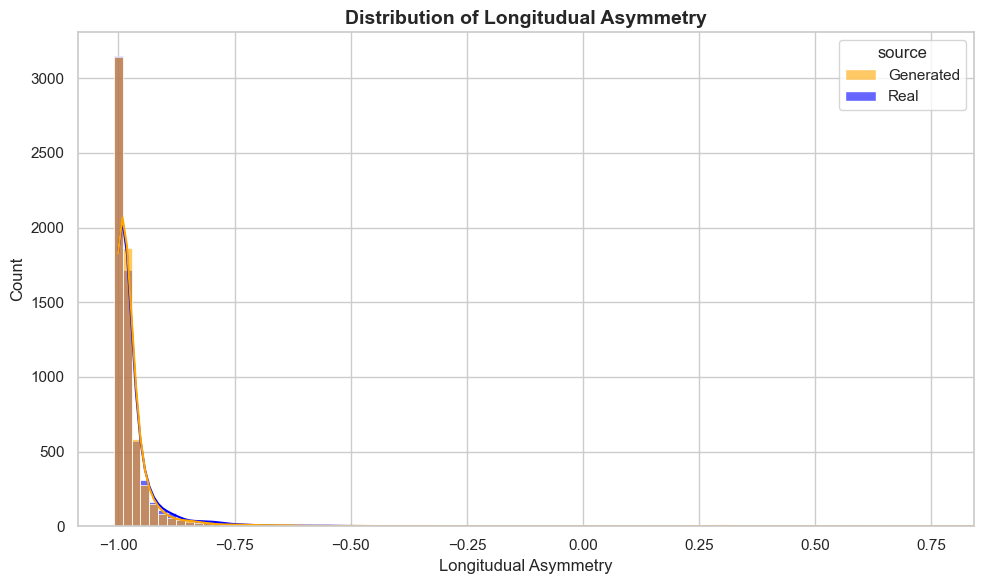

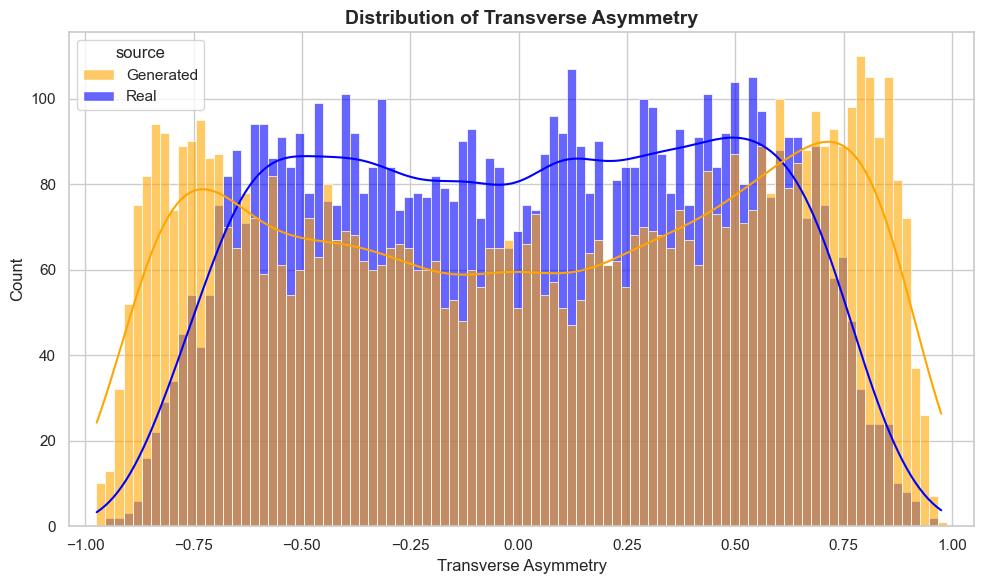

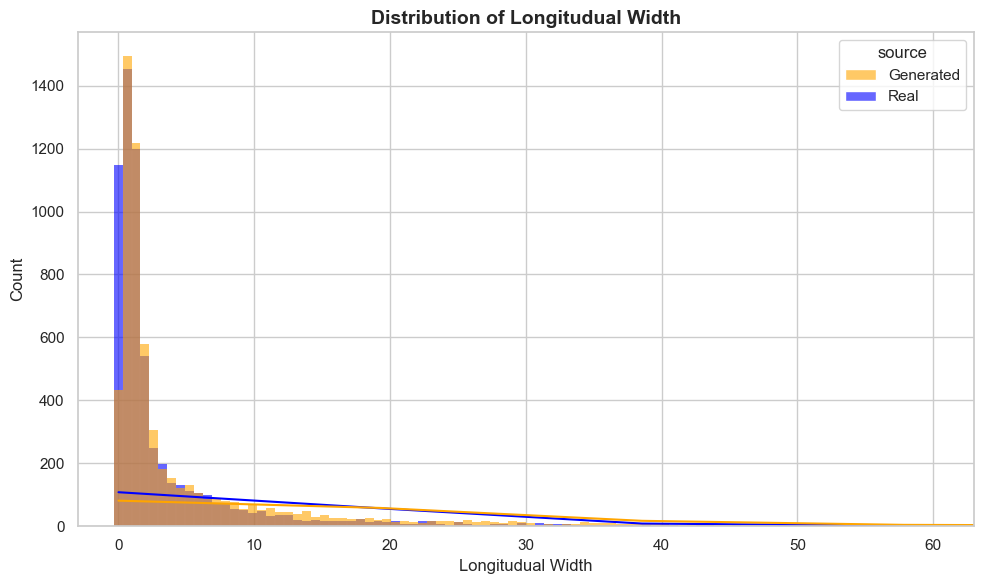

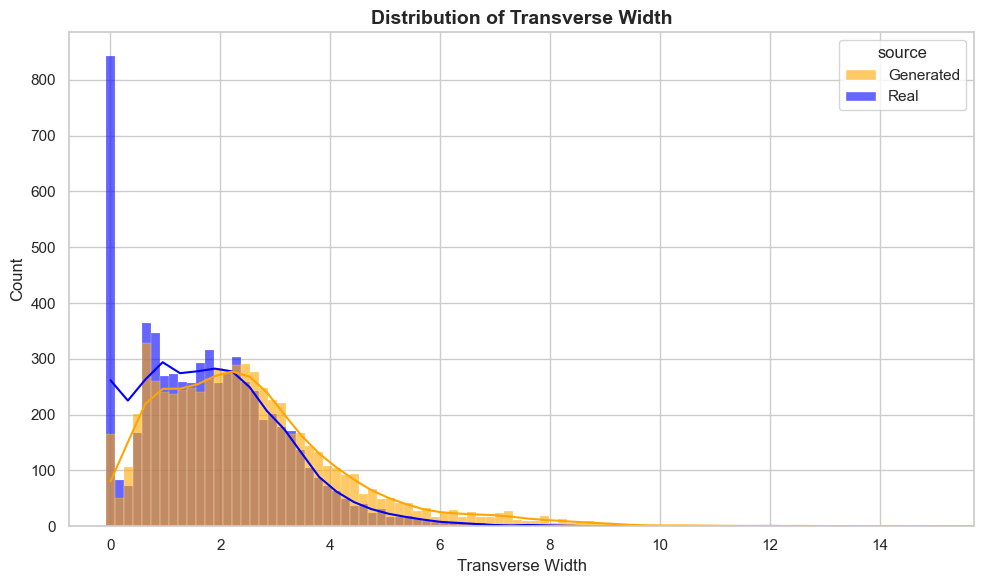

Energy PRD Curve


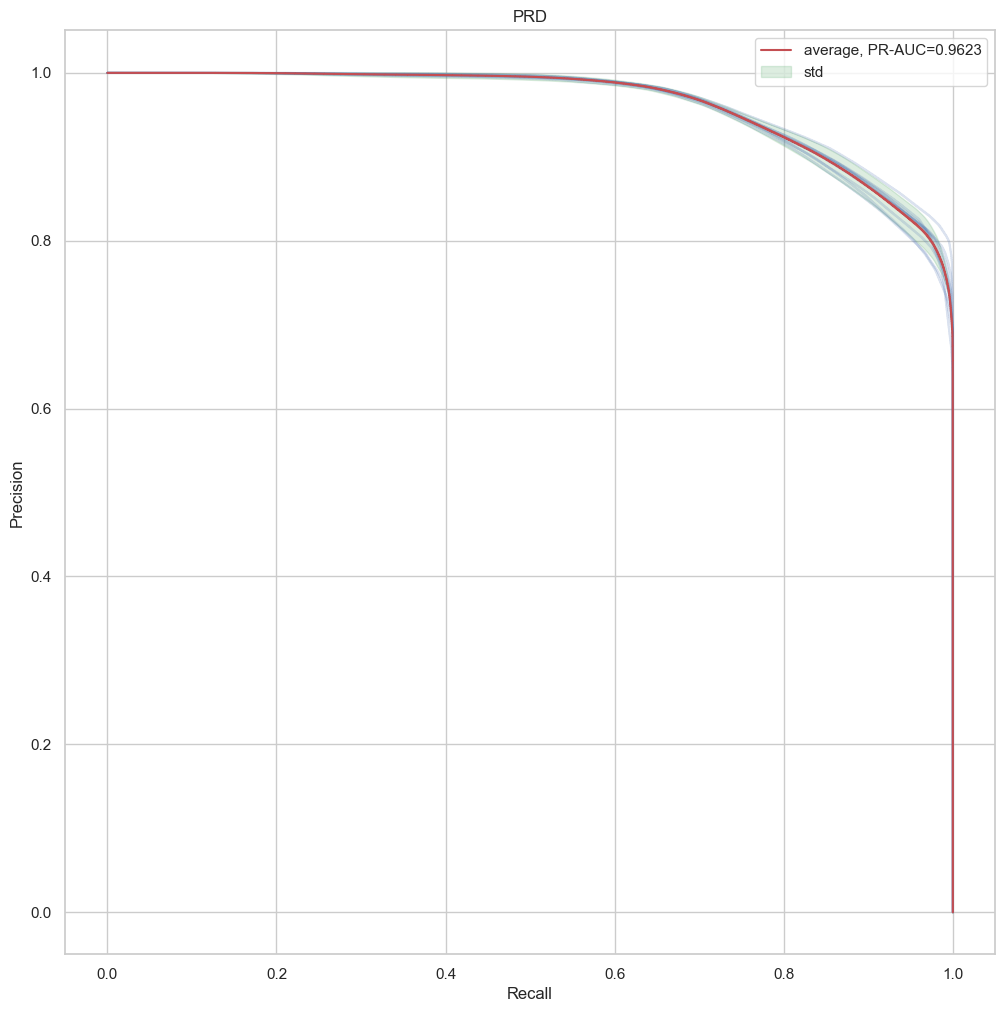

Physics PRD Curve


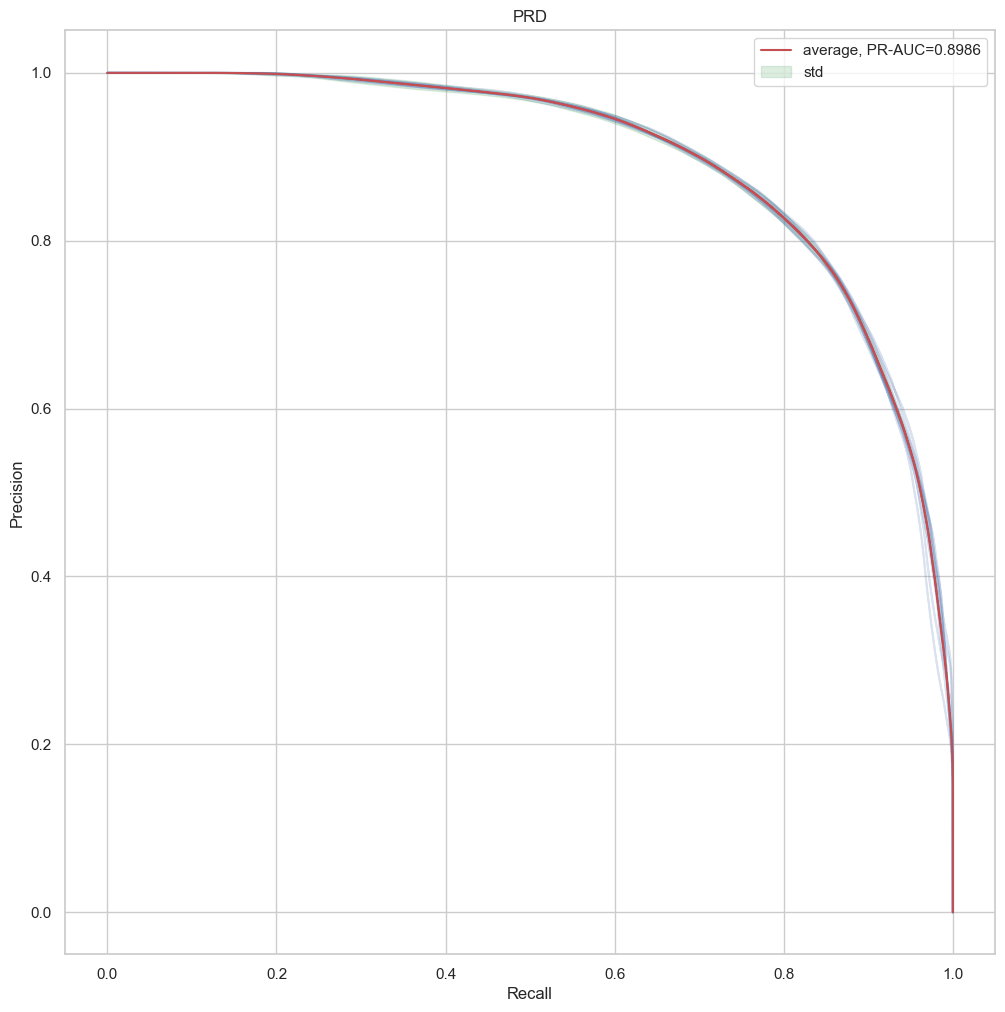

  -> Testing 25 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(93), np.int64(87), np.int64(81), np.int64(76), np.int64(70), np.int64(65), np.int64(60), np.int64(55), np.int64(50), np.int64(46), np.int64(41), np.int64(37), np.int64(32), np.int64(28), np.int64(25), np.int64(21), np.int64(17), np.int64(14), np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(2), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:39<00:00,  2.51it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_3_power_1.5_steps_25.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9592
PRD Physics AUC: -0.9024
------------------------------------


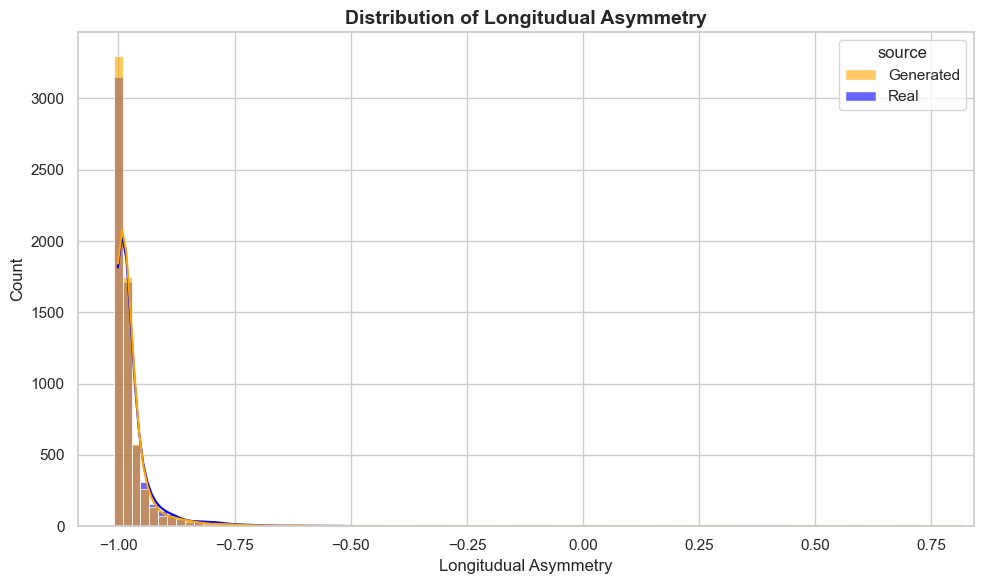

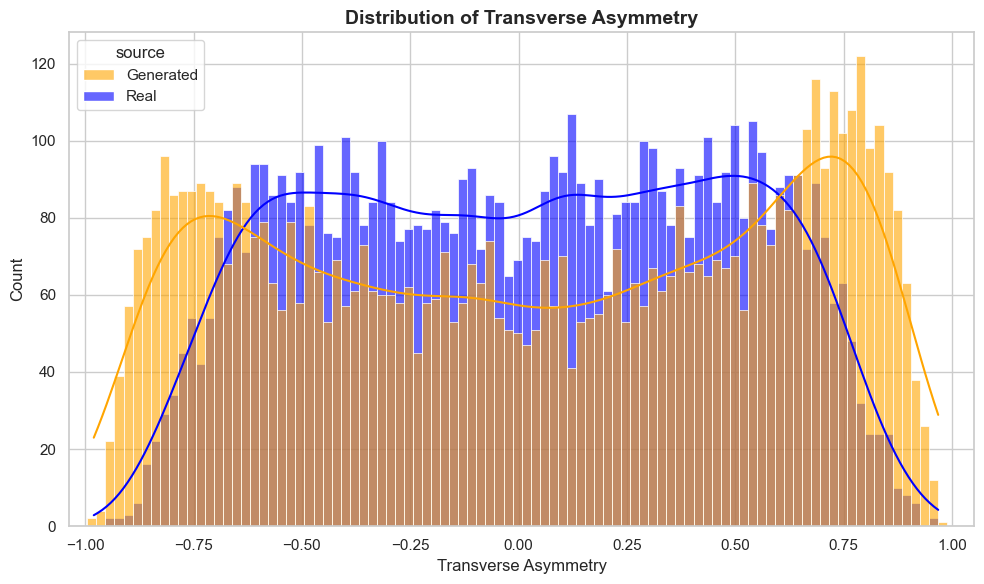

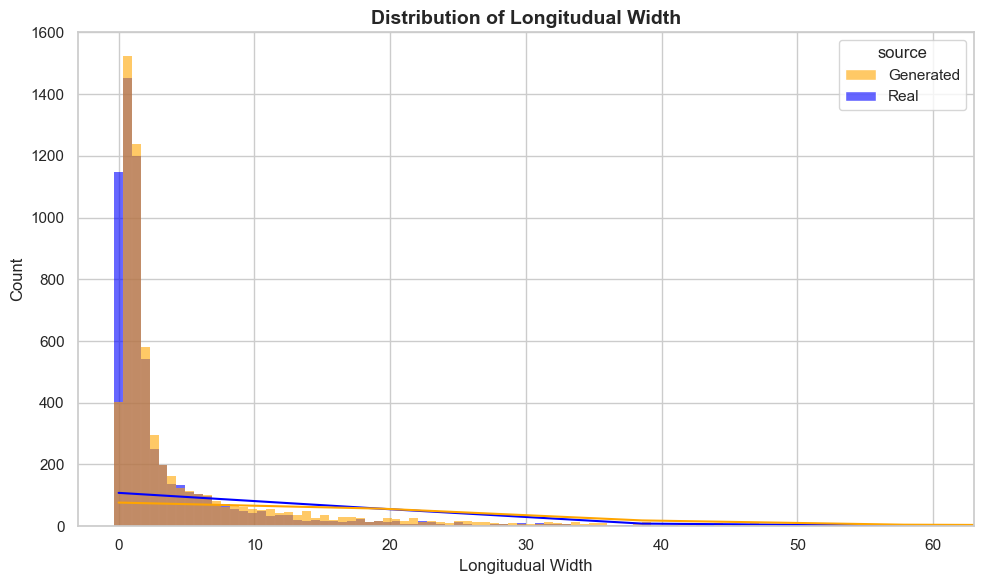

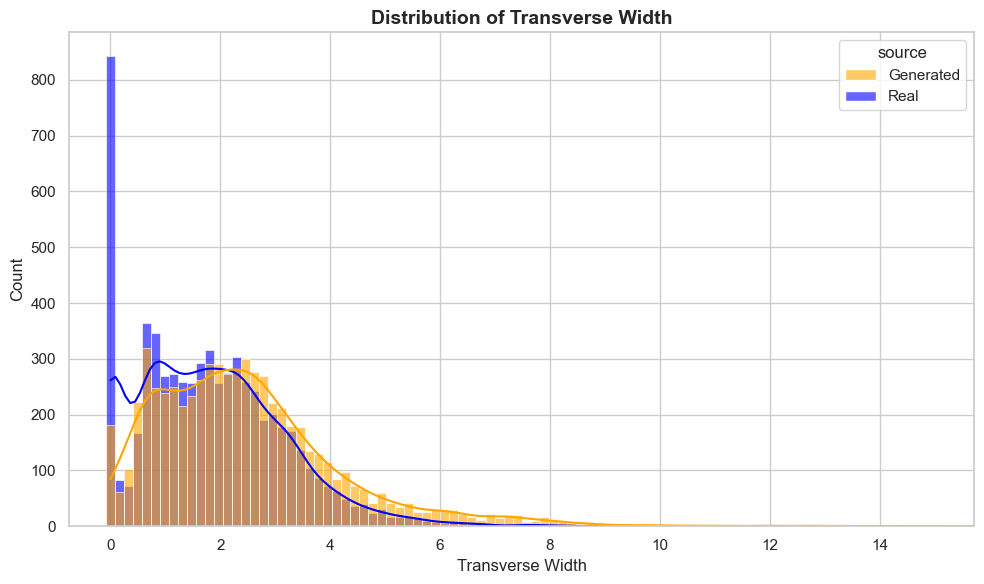

Energy PRD Curve


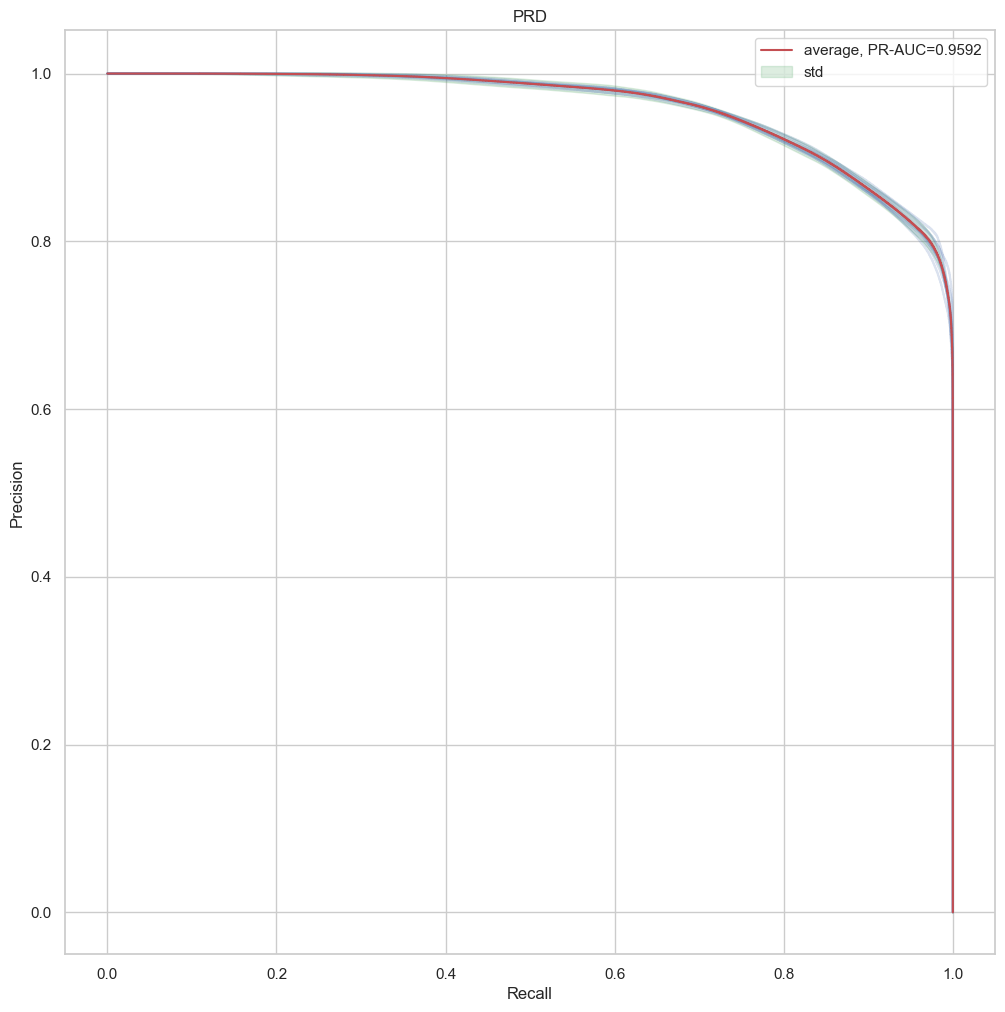

Physics PRD Curve


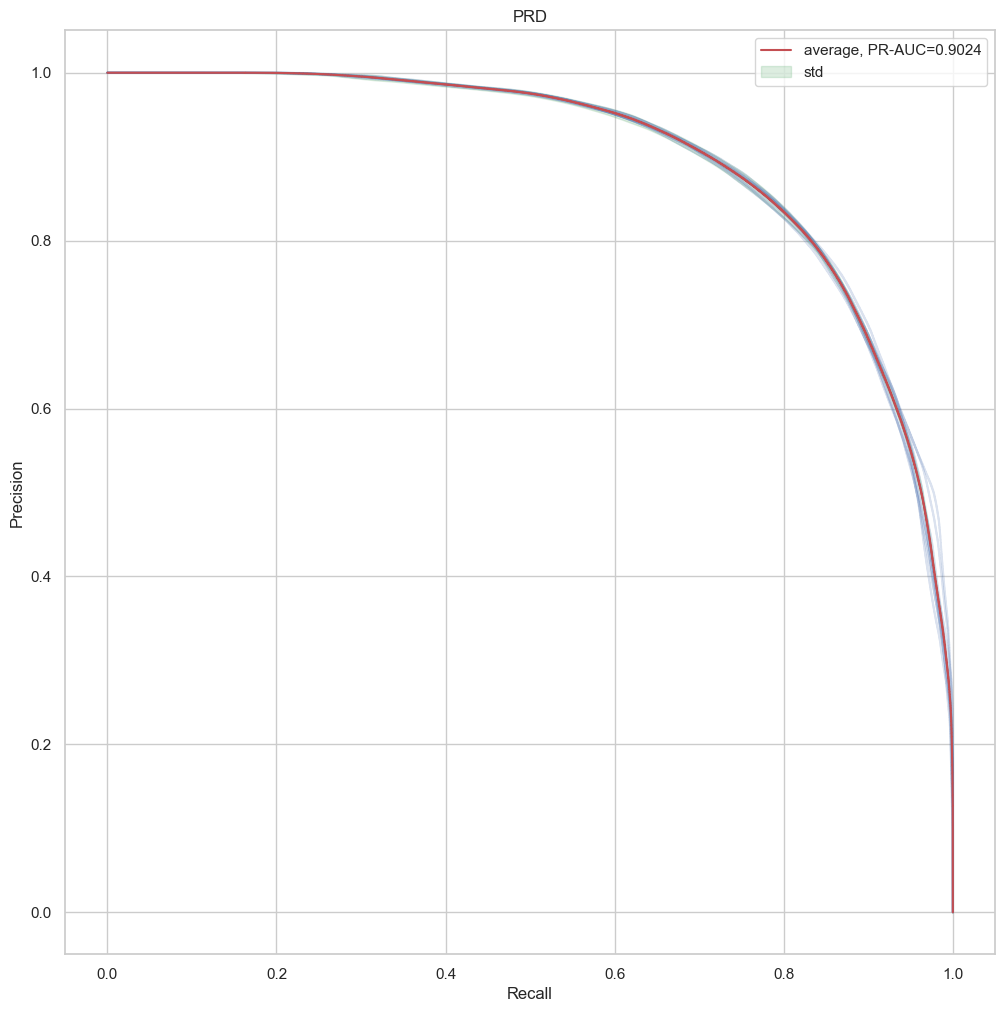

  -> Testing 15 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(89), np.int64(79), np.int64(70), np.int64(62), np.int64(53), np.int64(46), np.int64(38), np.int64(31), np.int64(25), np.int64(19), np.int64(13), np.int64(8), np.int64(4), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:24<00:00,  4.05it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_3_power_1.5_steps_15.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9583
PRD Physics AUC: -0.9084
------------------------------------


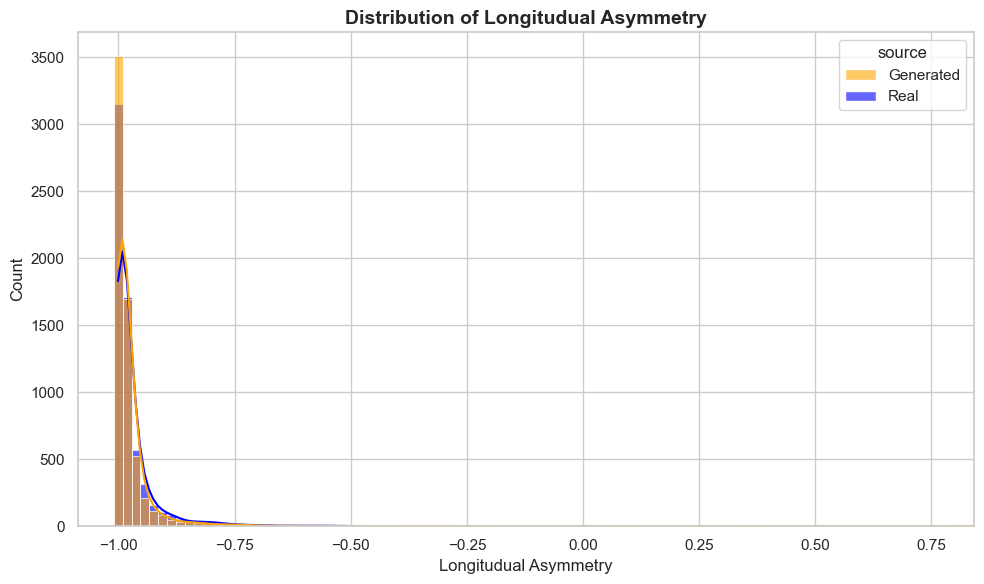

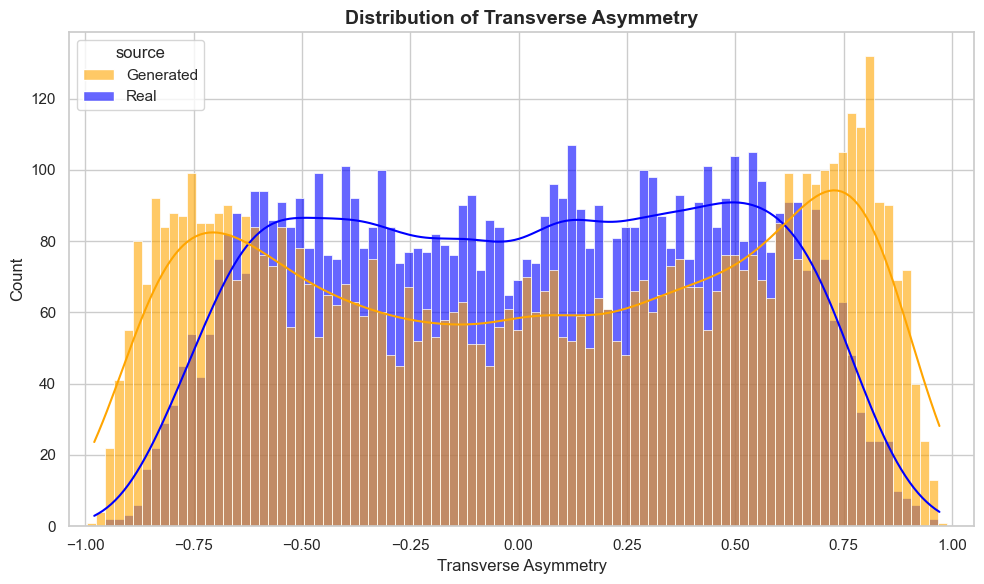

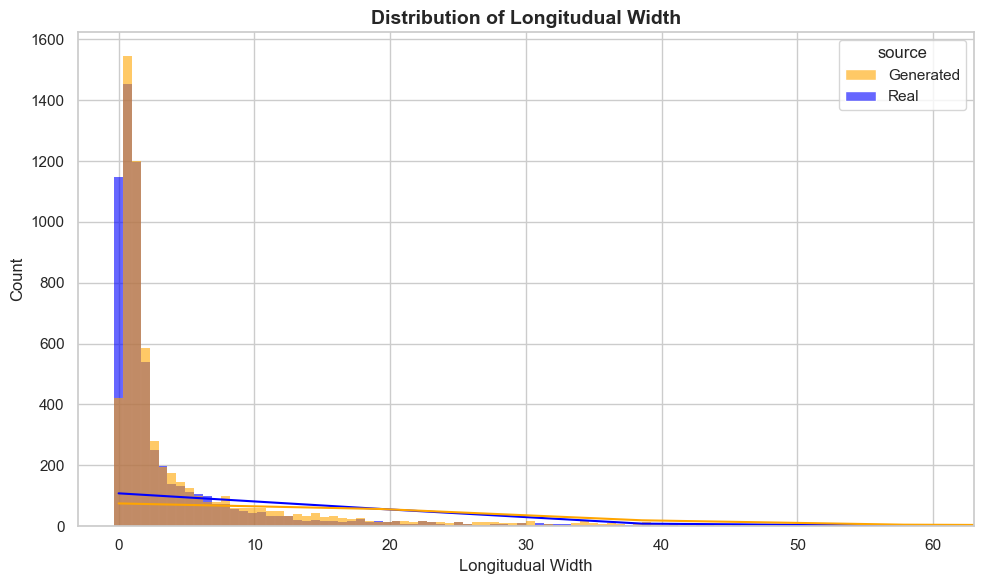

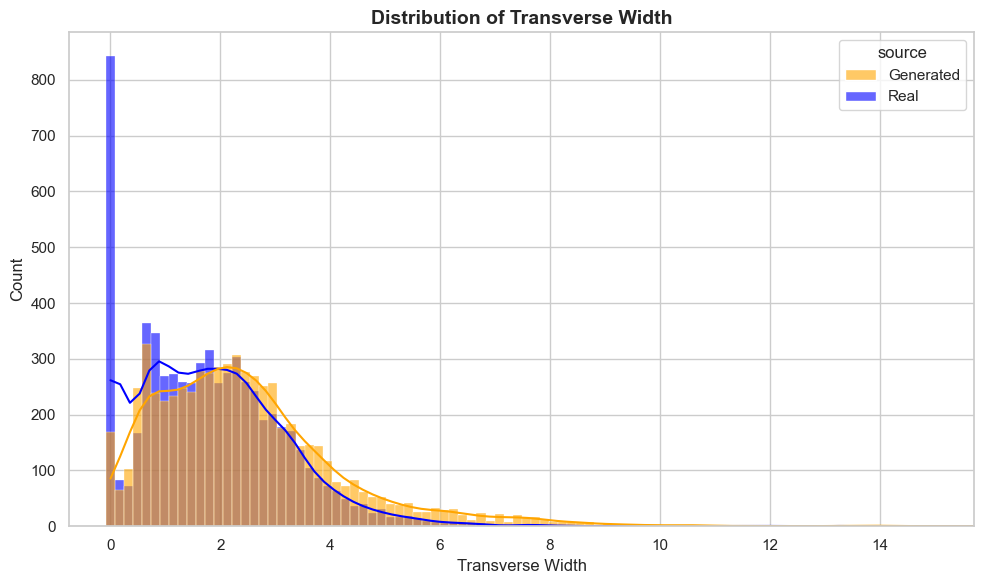

Energy PRD Curve


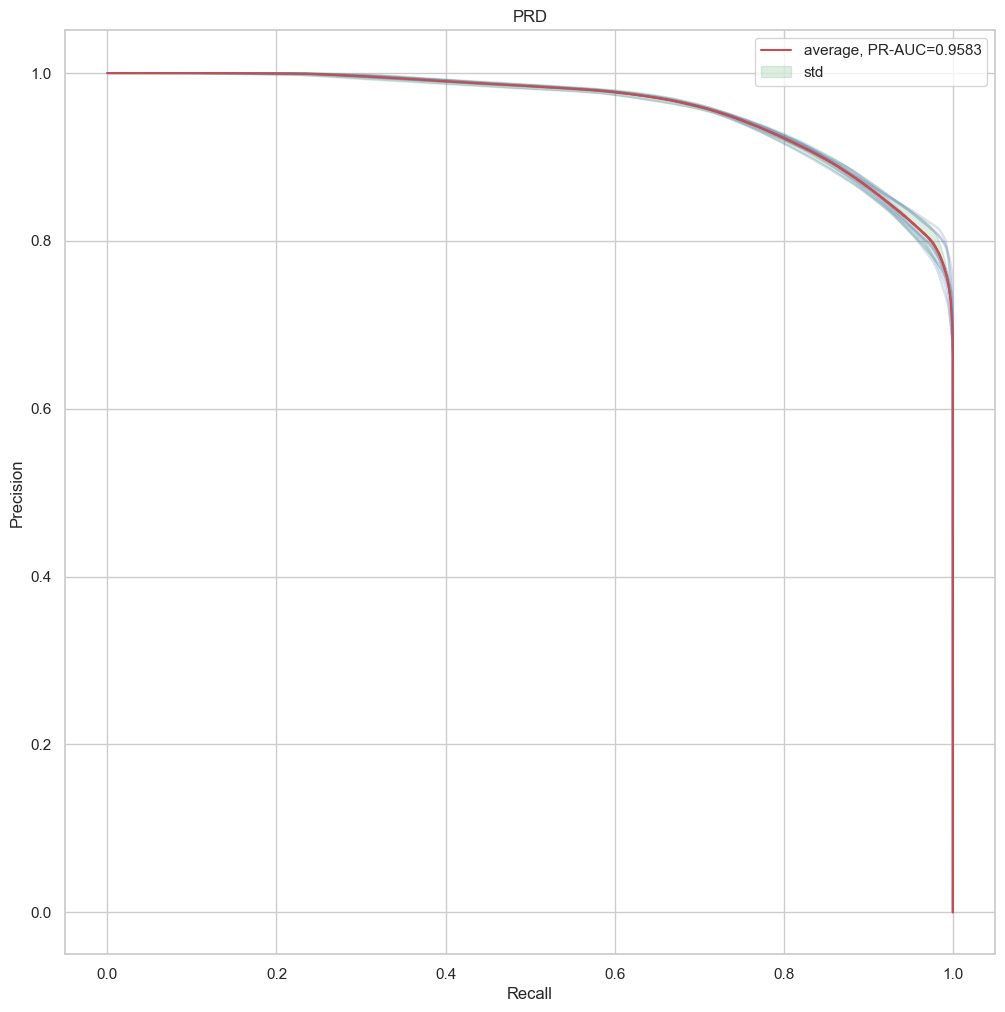

Physics PRD Curve


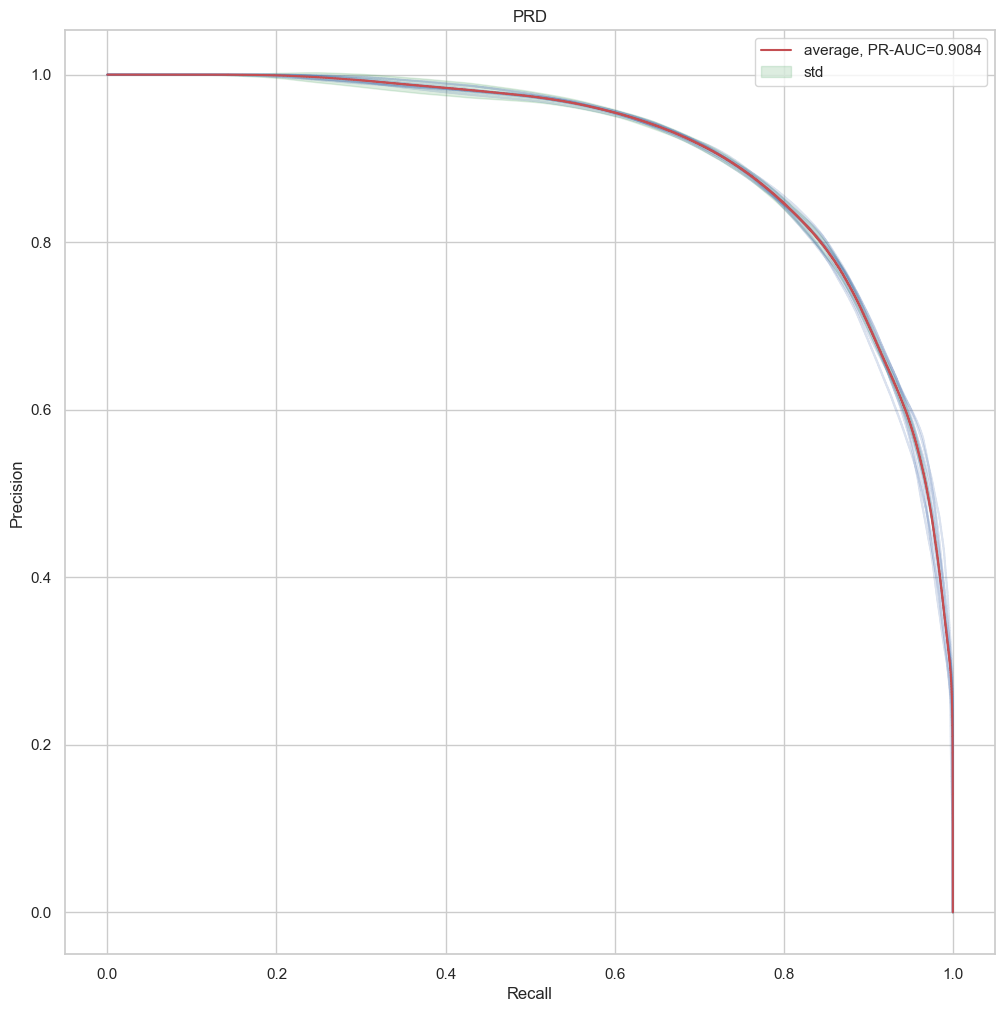

  -> Testing 10 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(84), np.int64(70), np.int64(57), np.int64(46), np.int64(35), np.int64(25), np.int64(16), np.int64(8), np.int64(3), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:17<00:00,  5.62it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_3_power_1.5_steps_10.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9555
PRD Physics AUC: -0.9128
------------------------------------


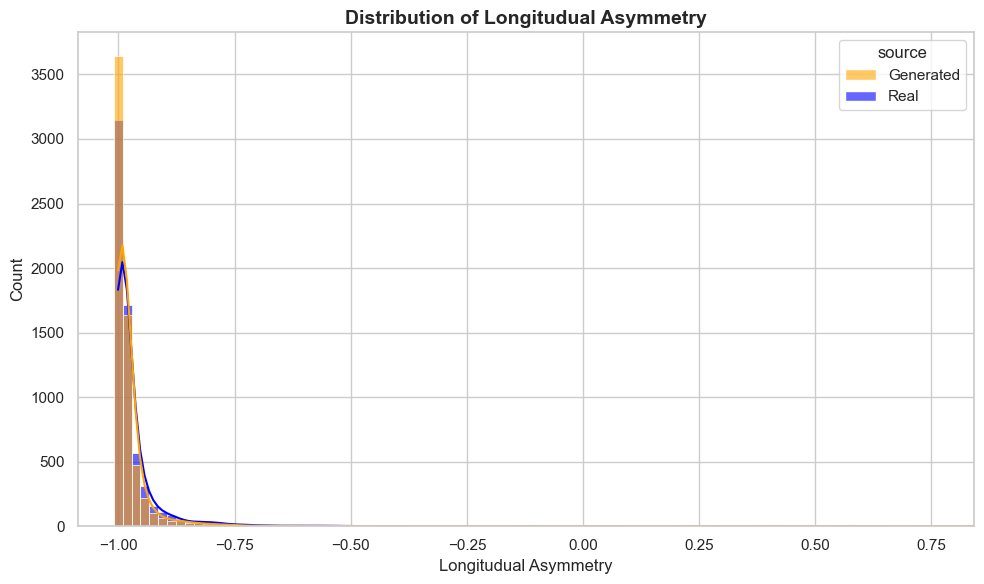

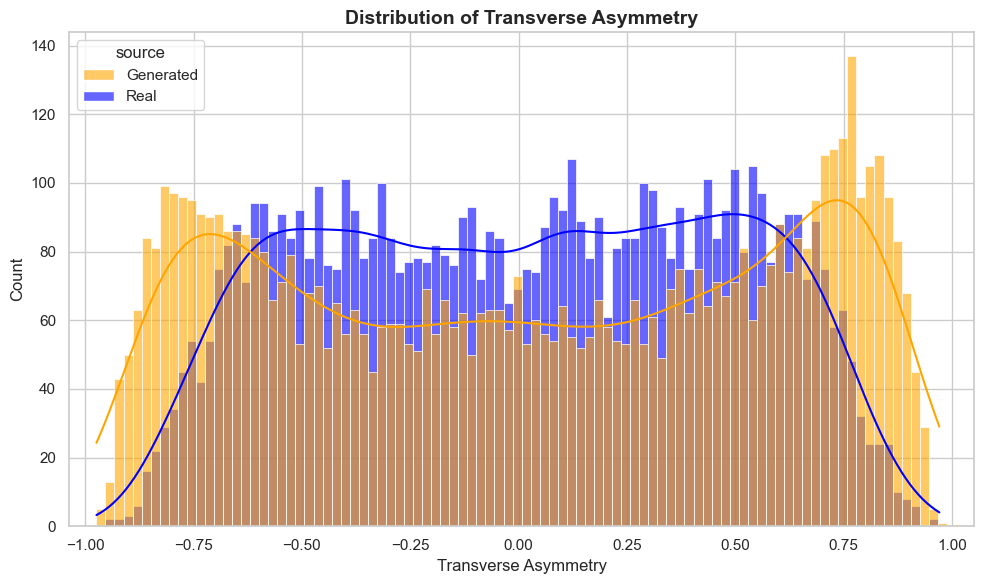

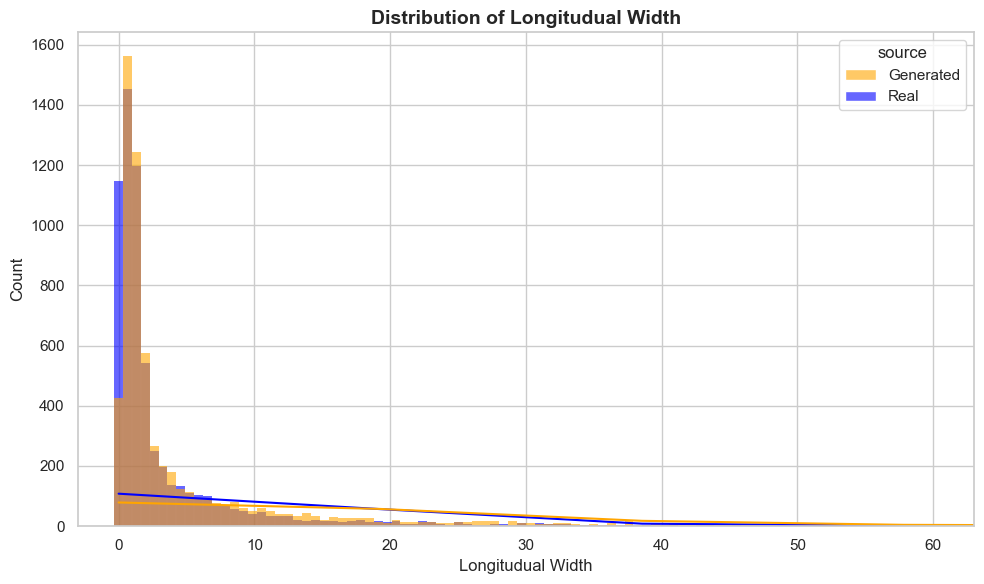

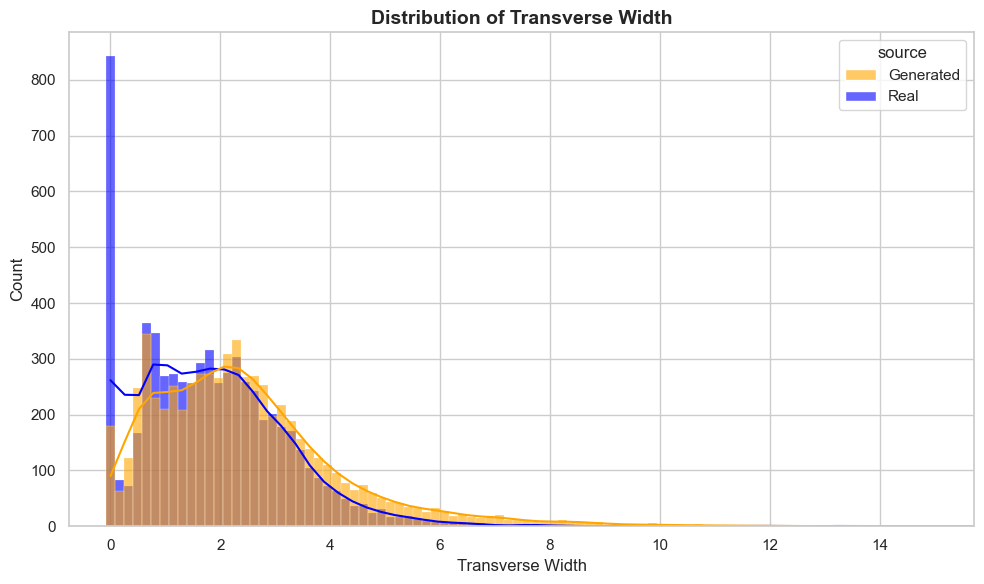

Energy PRD Curve


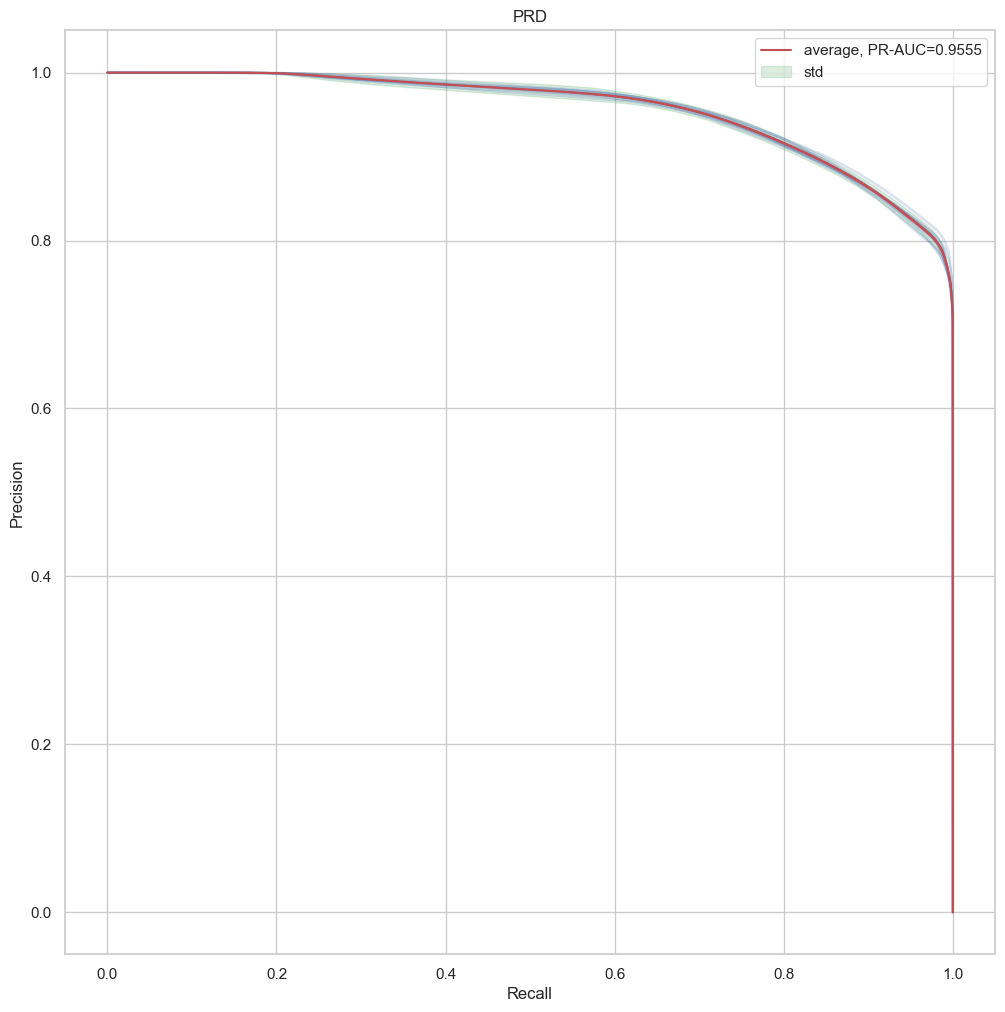

Physics PRD Curve


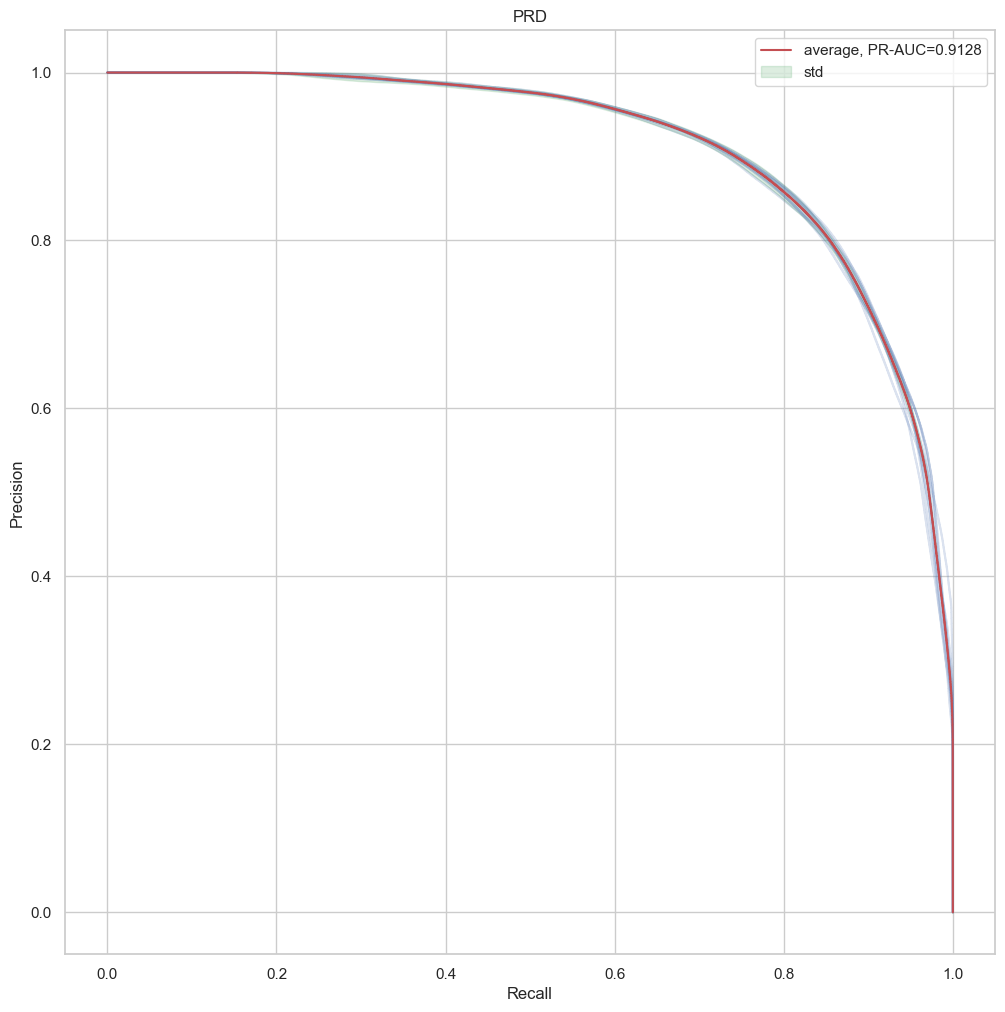


Evaluating model_5...
  -> Testing 50 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(96), np.int64(93), np.int64(90), np.int64(87), np.int64(84), np.int64(81), np.int64(78), np.int64(76), np.int64(73), np.int64(70), np.int64(68), np.int64(65), np.int64(63), np.int64(60), np.int64(57), np.int64(55), np.int64(53), np.int64(50), np.int64(48), np.int64(46), np.int64(43), np.int64(41), np.int64(39), np.int64(37), np.int64(35), np.int64(32), np.int64(30), np.int64(28), np.int64(26), np.int64(25), np.int64(23), np.int64(21), np.int64(19), np.int64(17), np.int64(16), np.int64(14), np.int64(13), np.int64(11), np.int64(10), np.int64(8), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_5_power_1.5_steps_50.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9276
PRD Physics AUC: -0.9682
------------------------------------


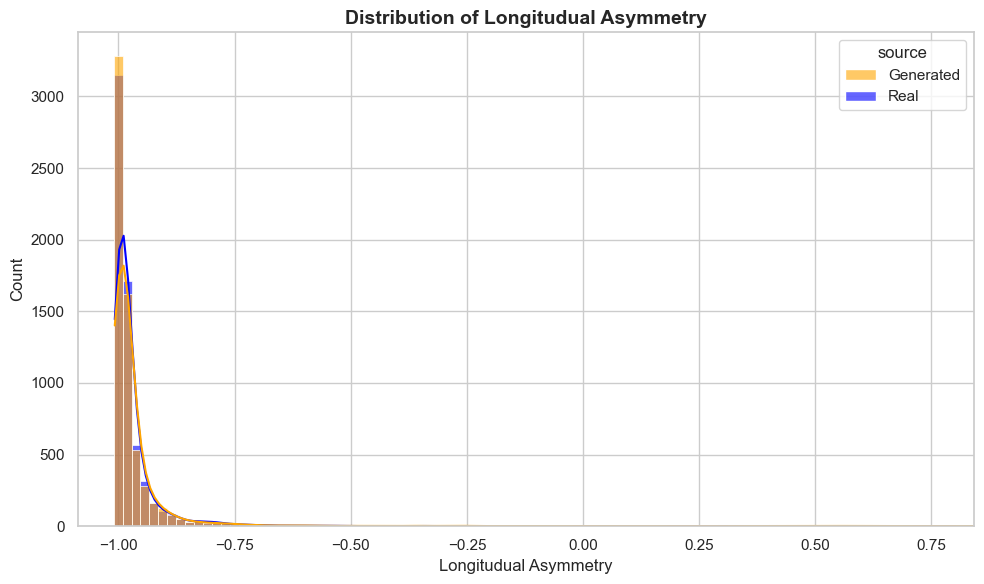

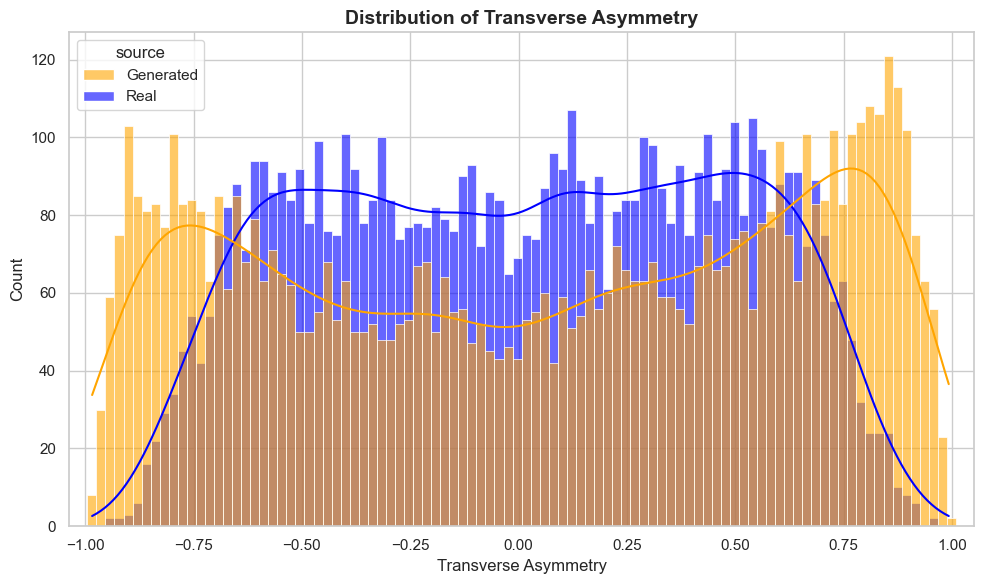

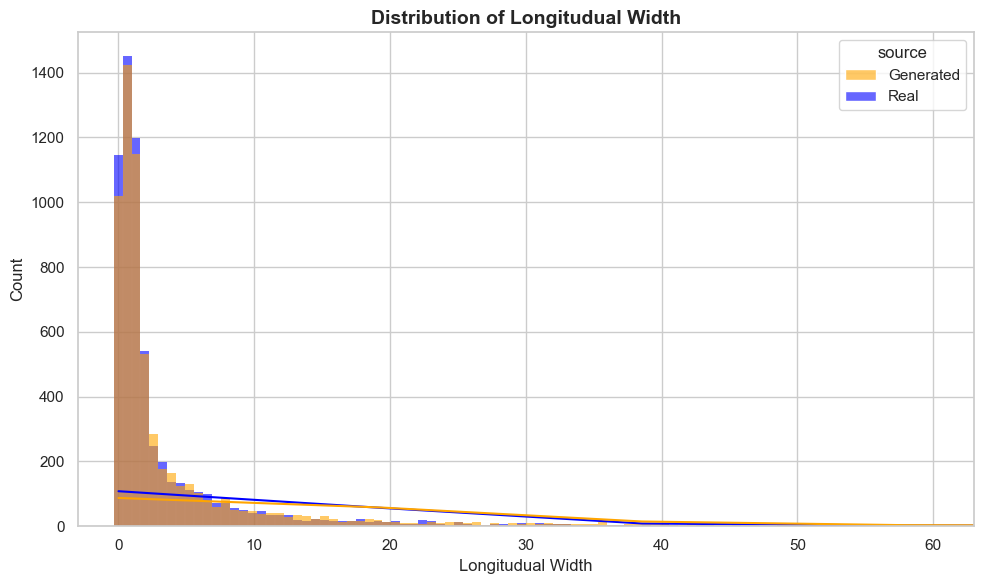

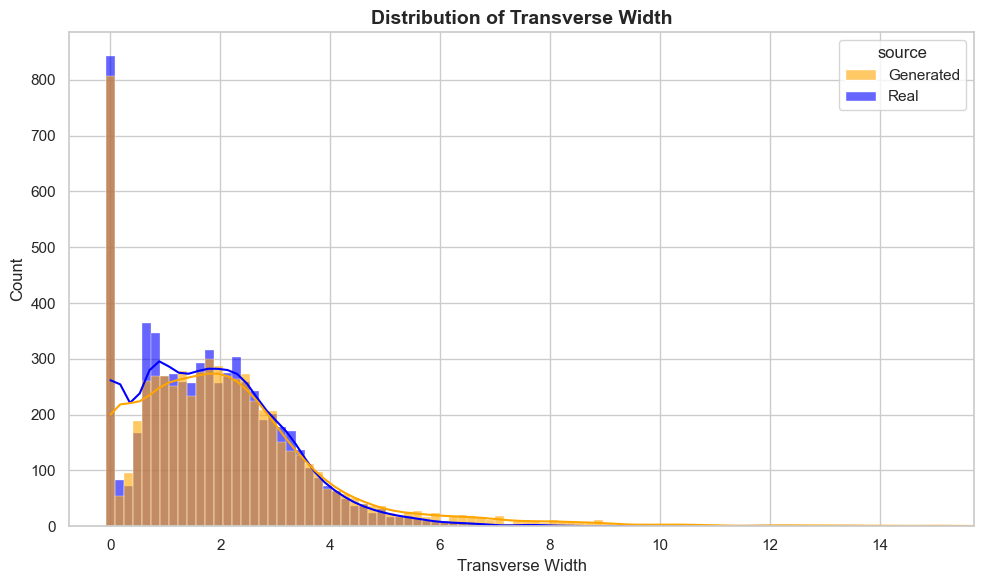

Energy PRD Curve


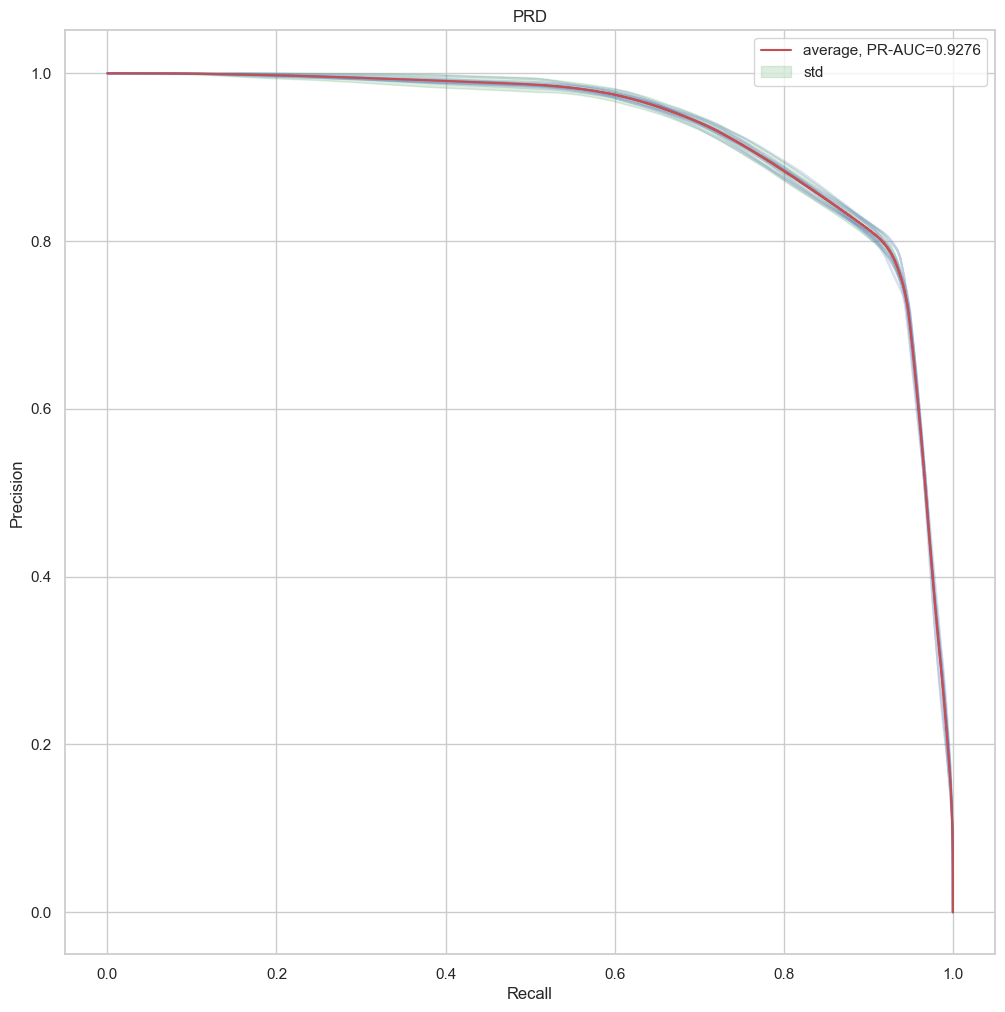

Physics PRD Curve


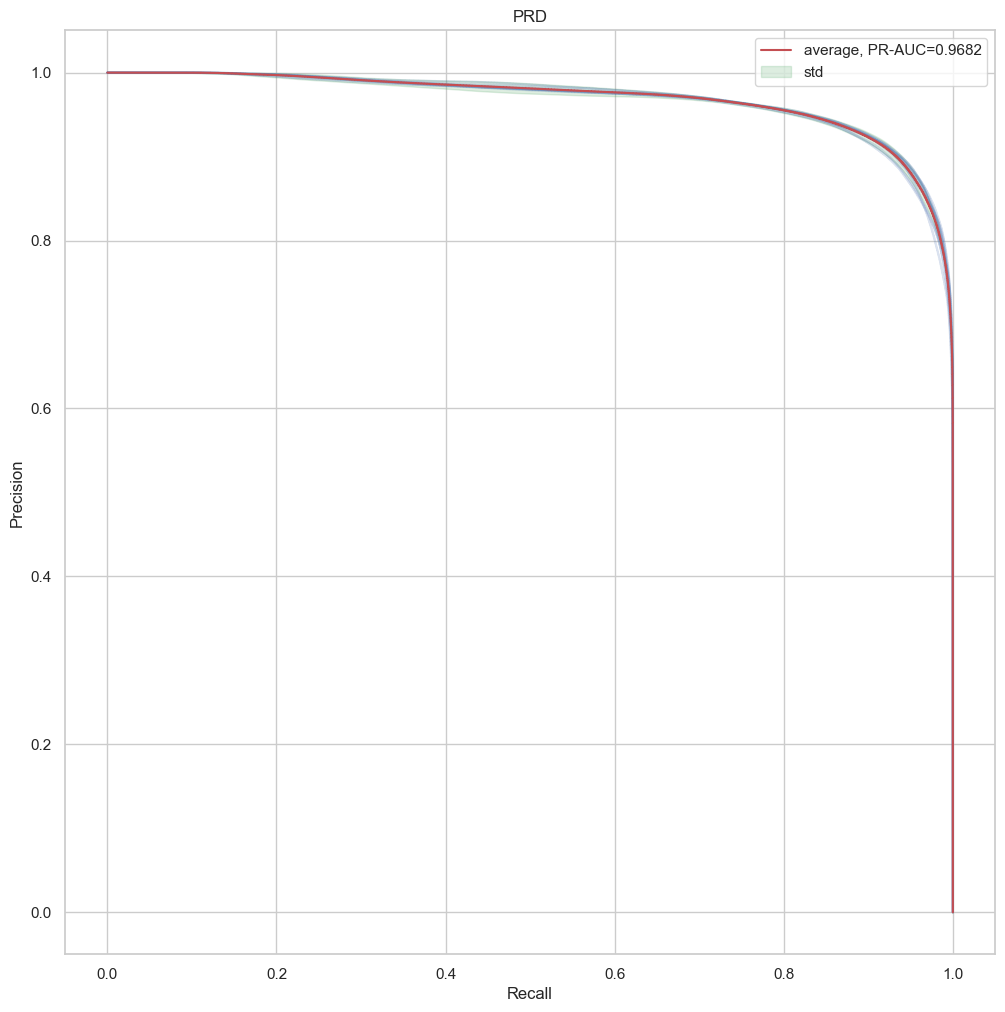

  -> Testing 25 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(93), np.int64(87), np.int64(81), np.int64(76), np.int64(70), np.int64(65), np.int64(60), np.int64(55), np.int64(50), np.int64(46), np.int64(41), np.int64(37), np.int64(32), np.int64(28), np.int64(25), np.int64(21), np.int64(17), np.int64(14), np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(2), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_5_power_1.5_steps_25.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9353
PRD Physics AUC: -0.9670
------------------------------------


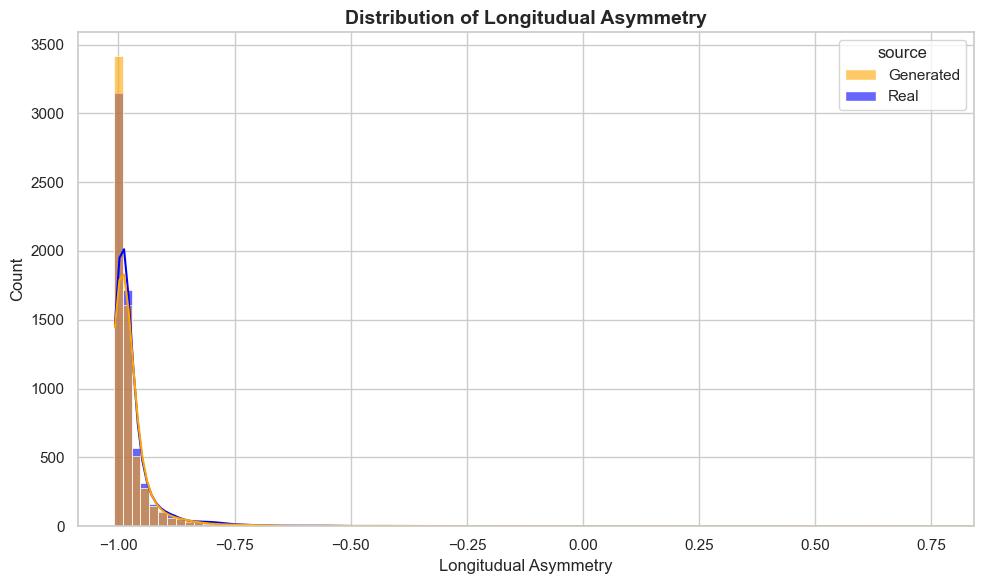

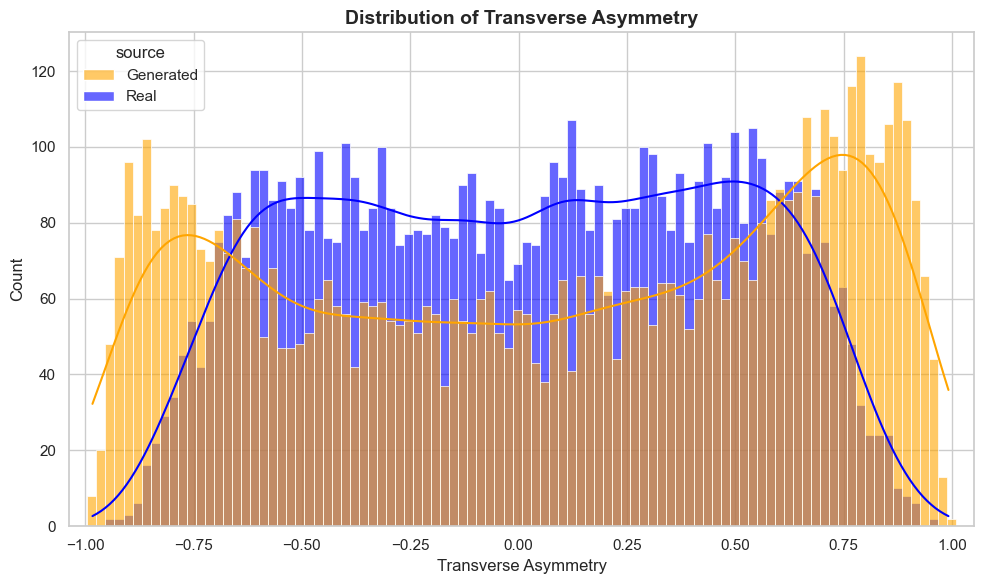

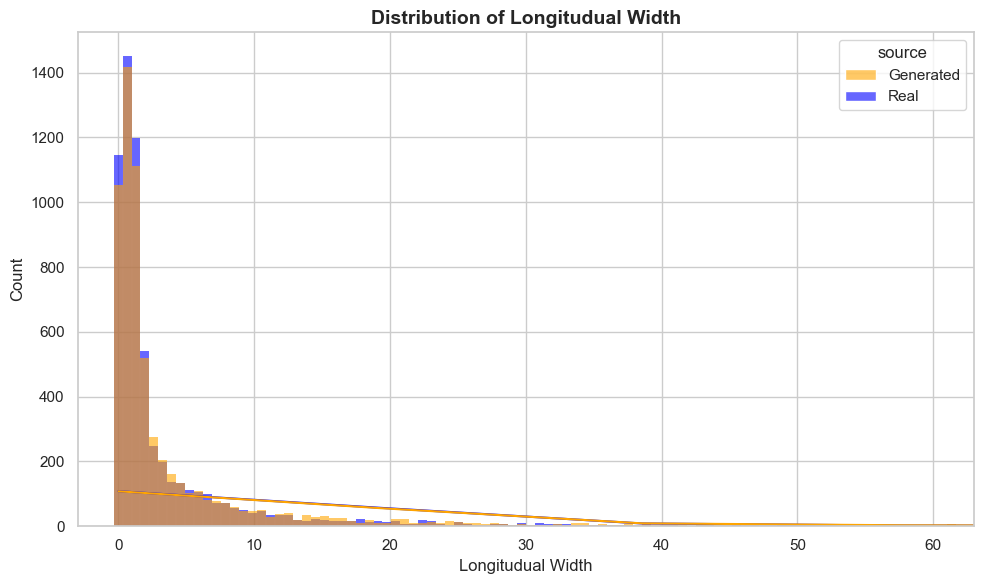

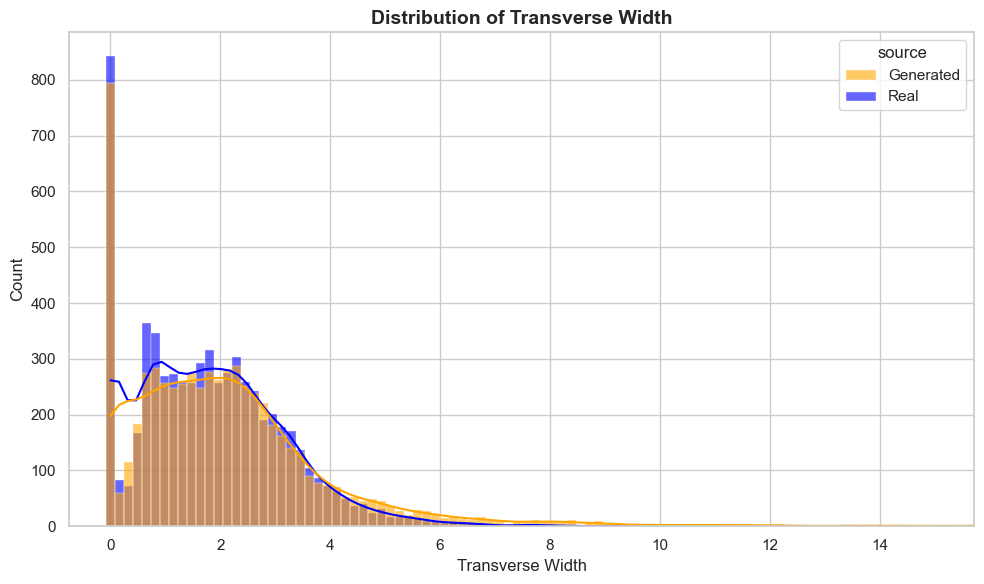

Energy PRD Curve


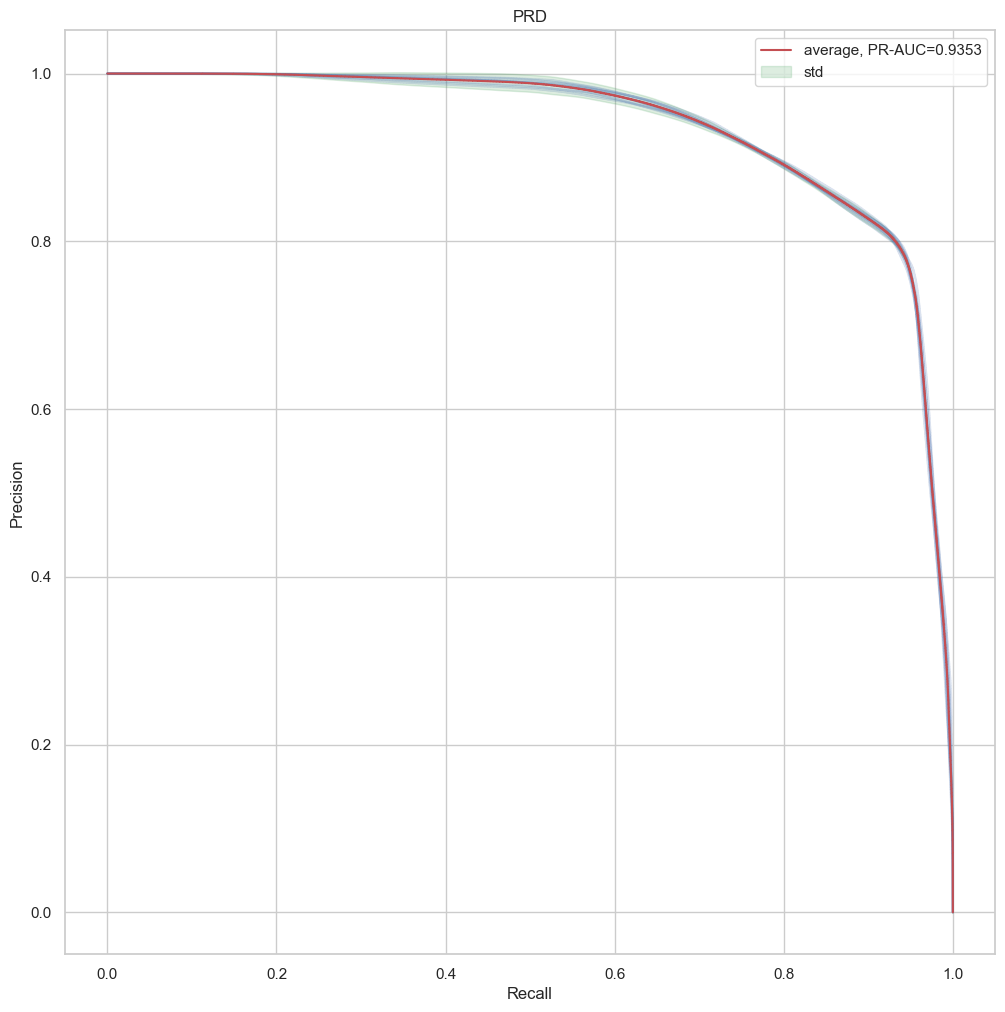

Physics PRD Curve


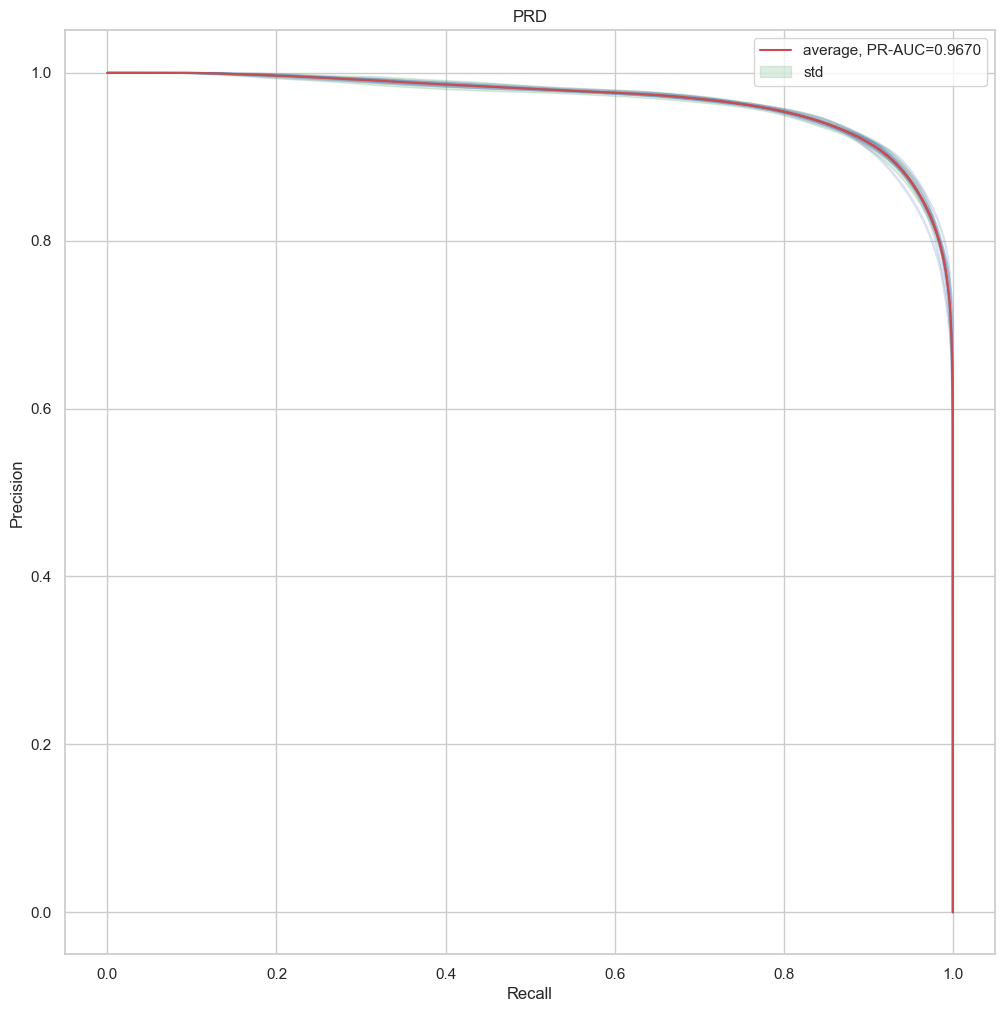

  -> Testing 15 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(89), np.int64(79), np.int64(70), np.int64(62), np.int64(53), np.int64(46), np.int64(38), np.int64(31), np.int64(25), np.int64(19), np.int64(13), np.int64(8), np.int64(4), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:24<00:00,  4.07it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_5_power_1.5_steps_15.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9414
PRD Physics AUC: -0.9710
------------------------------------


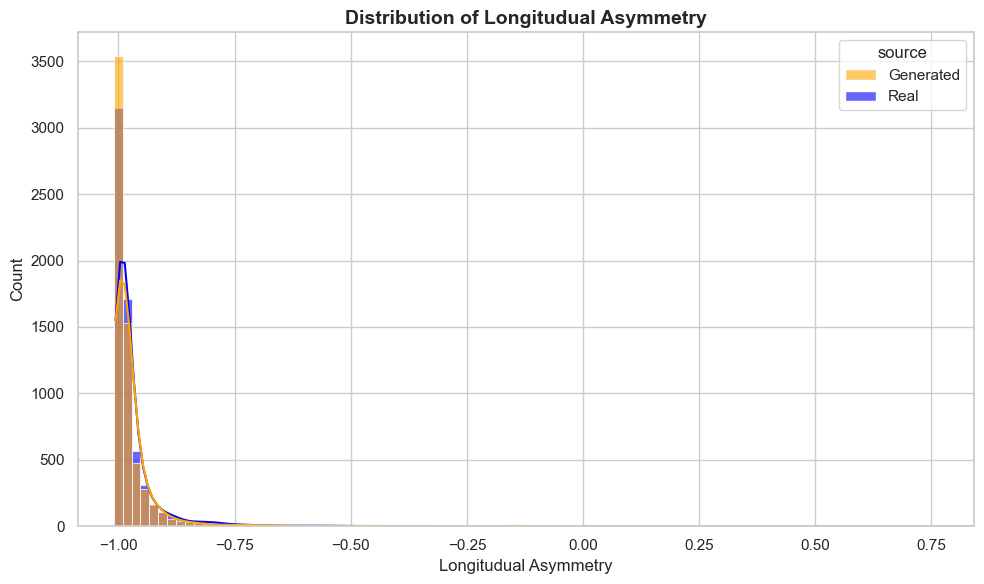

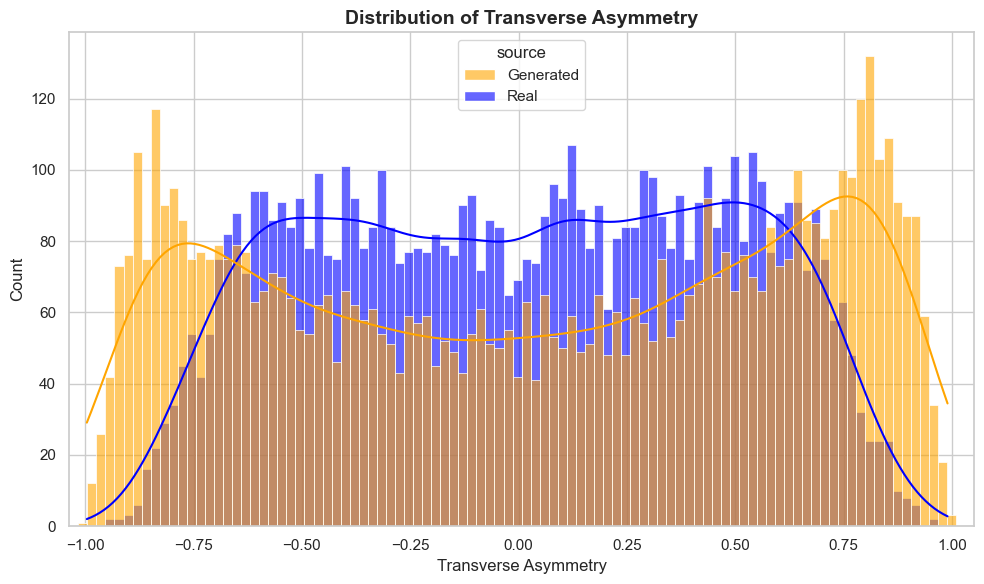

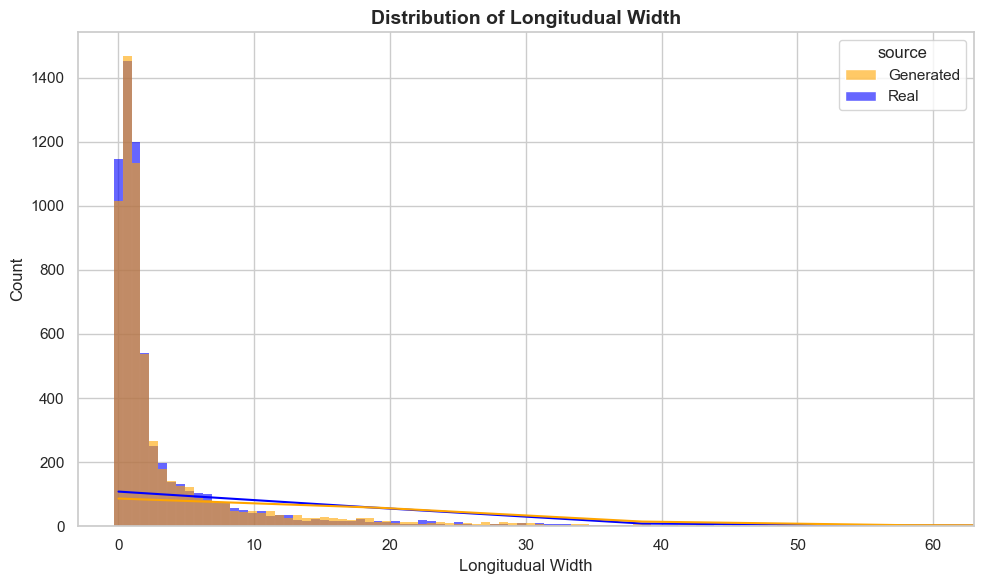

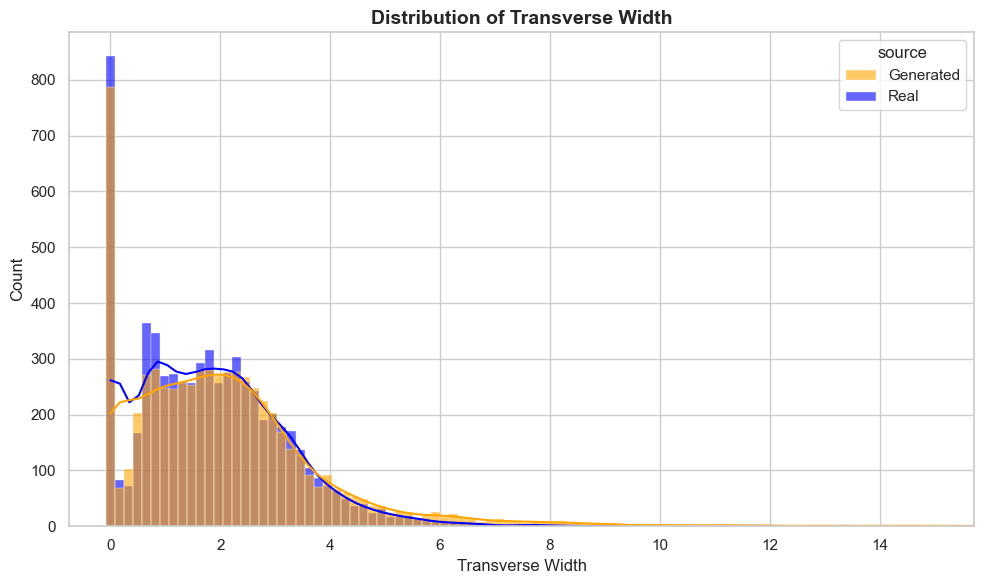

Energy PRD Curve


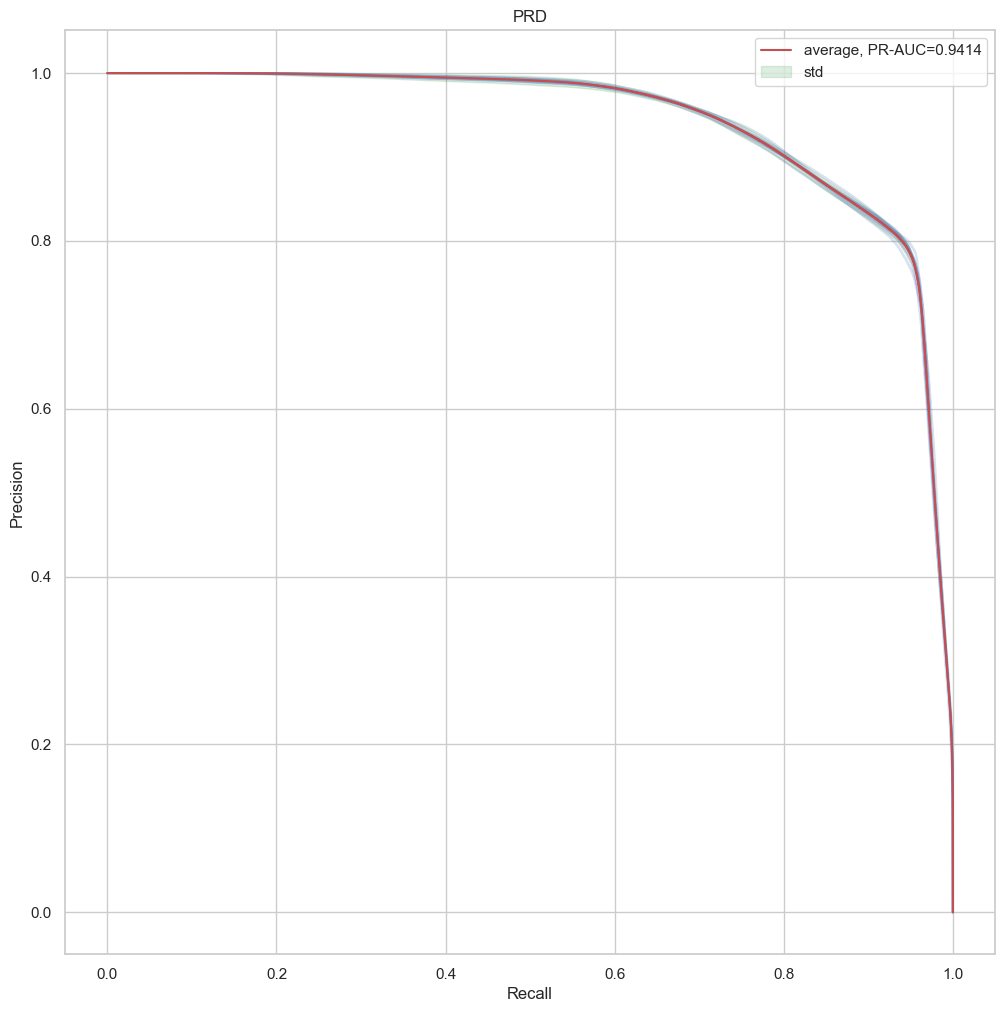

Physics PRD Curve


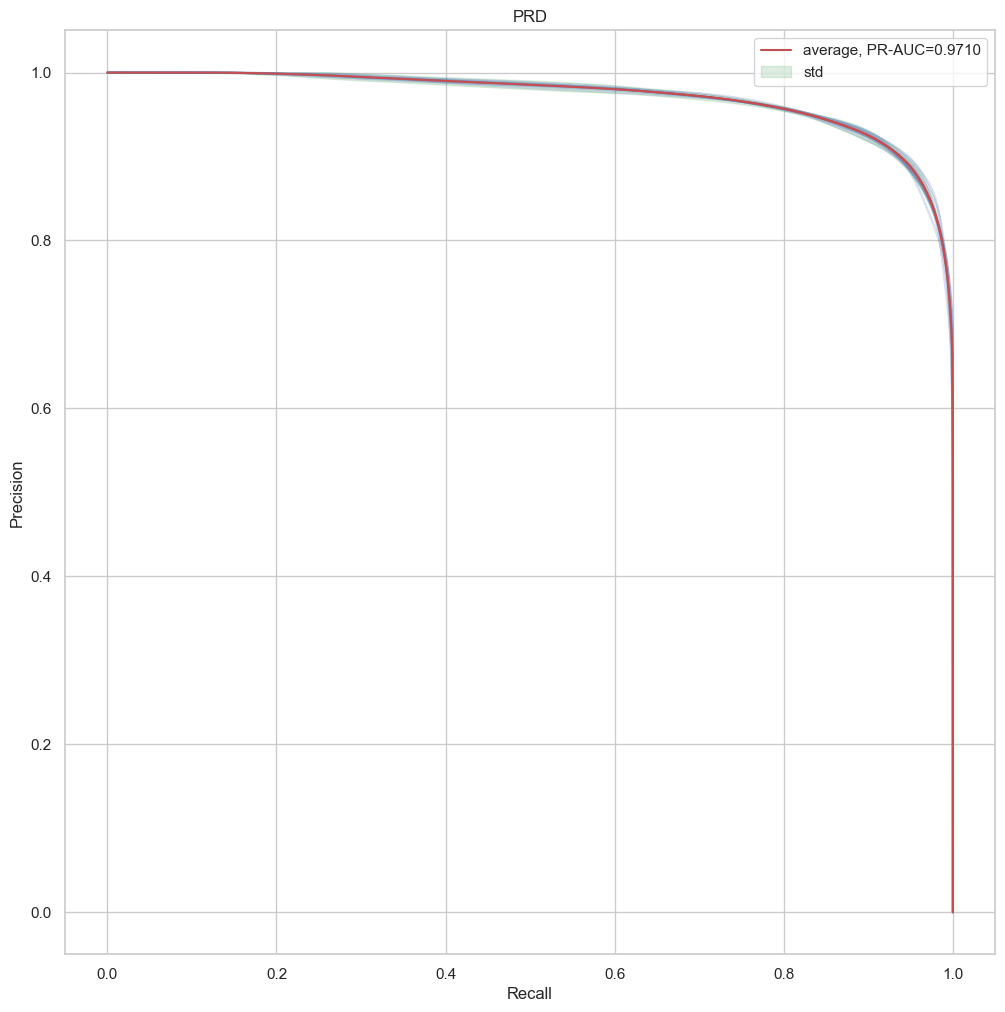

  -> Testing 10 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(84), np.int64(70), np.int64(57), np.int64(46), np.int64(35), np.int64(25), np.int64(16), np.int64(8), np.int64(3), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:17<00:00,  5.68it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_5_power_1.5_steps_10.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9481
PRD Physics AUC: -0.9755
------------------------------------


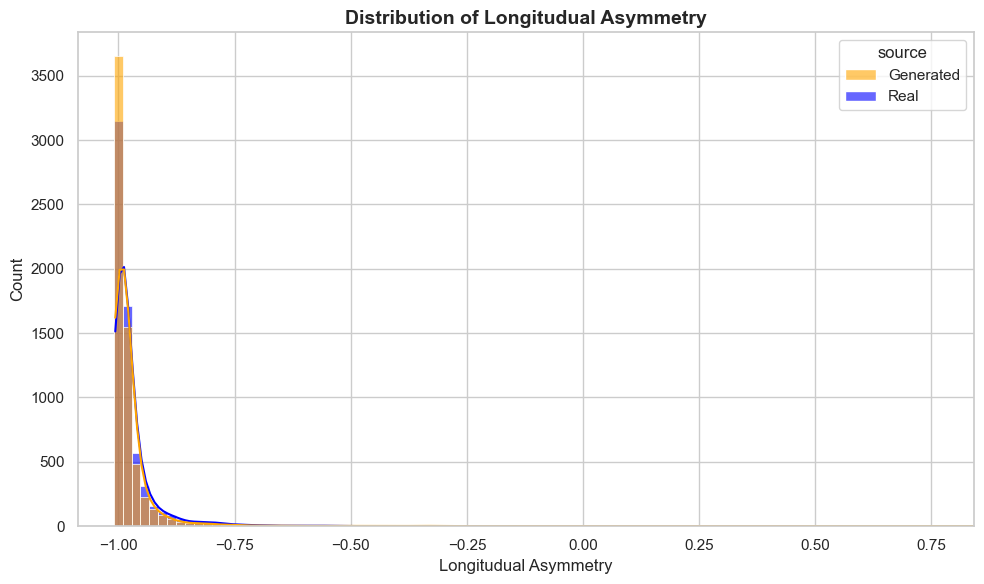

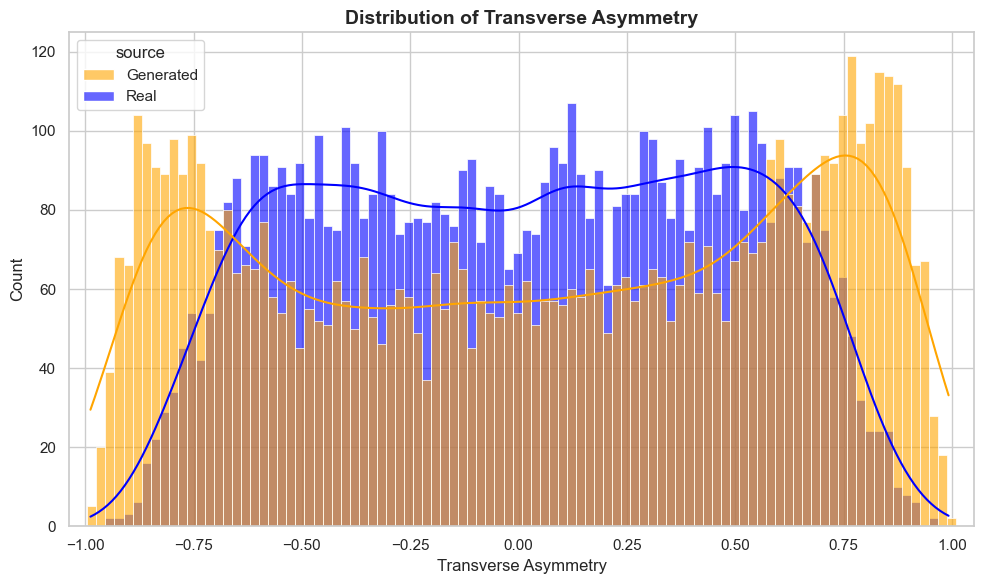

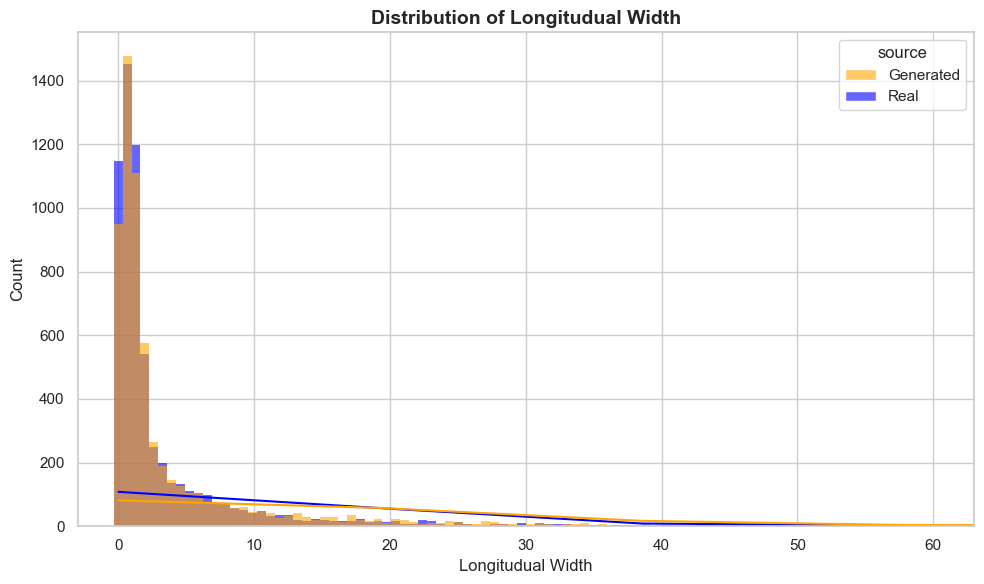

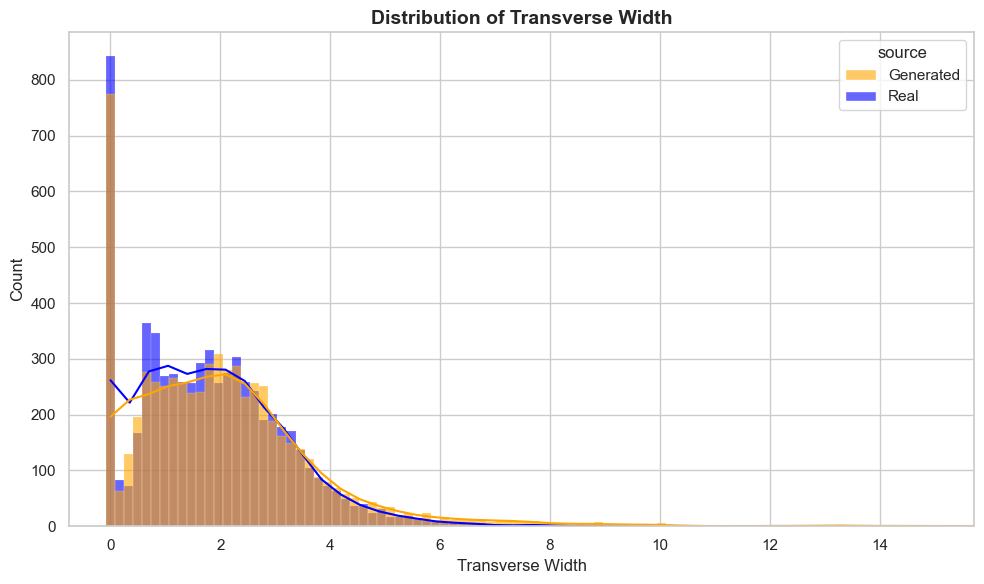

Energy PRD Curve


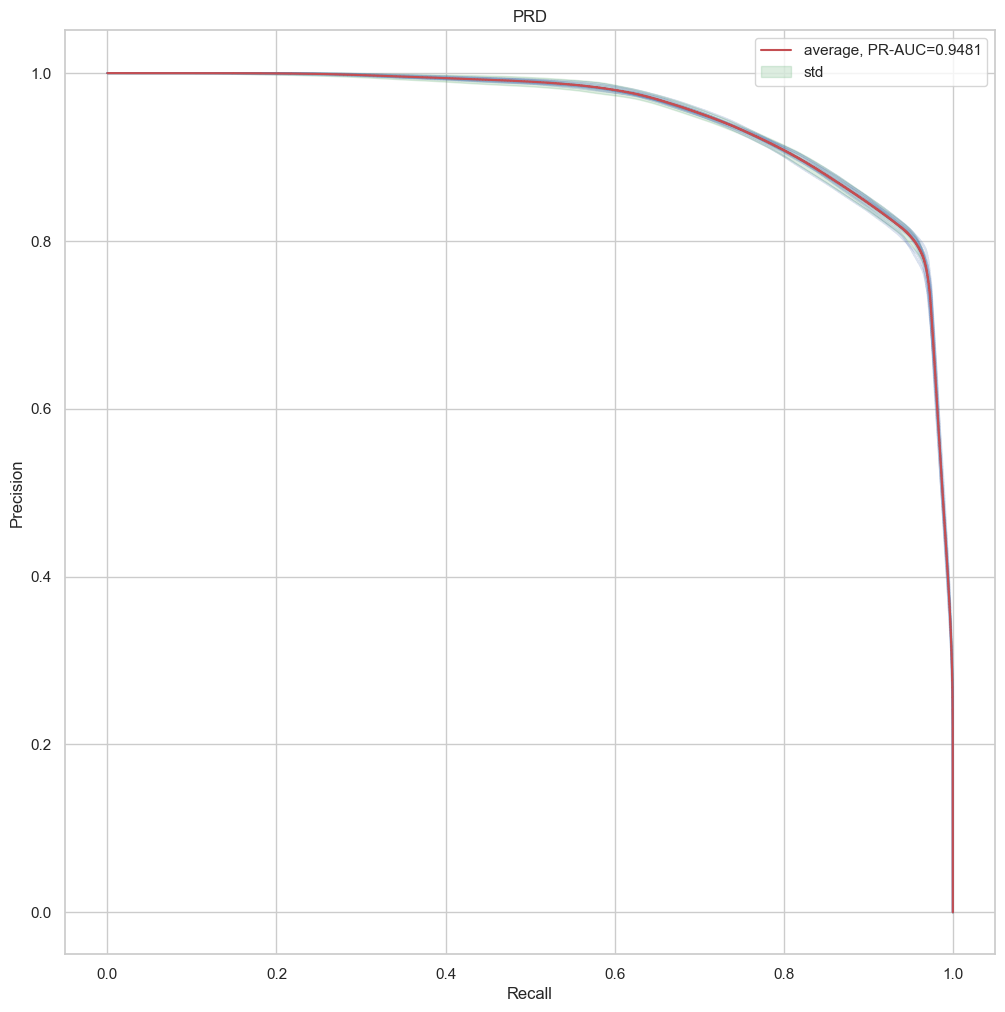

Physics PRD Curve


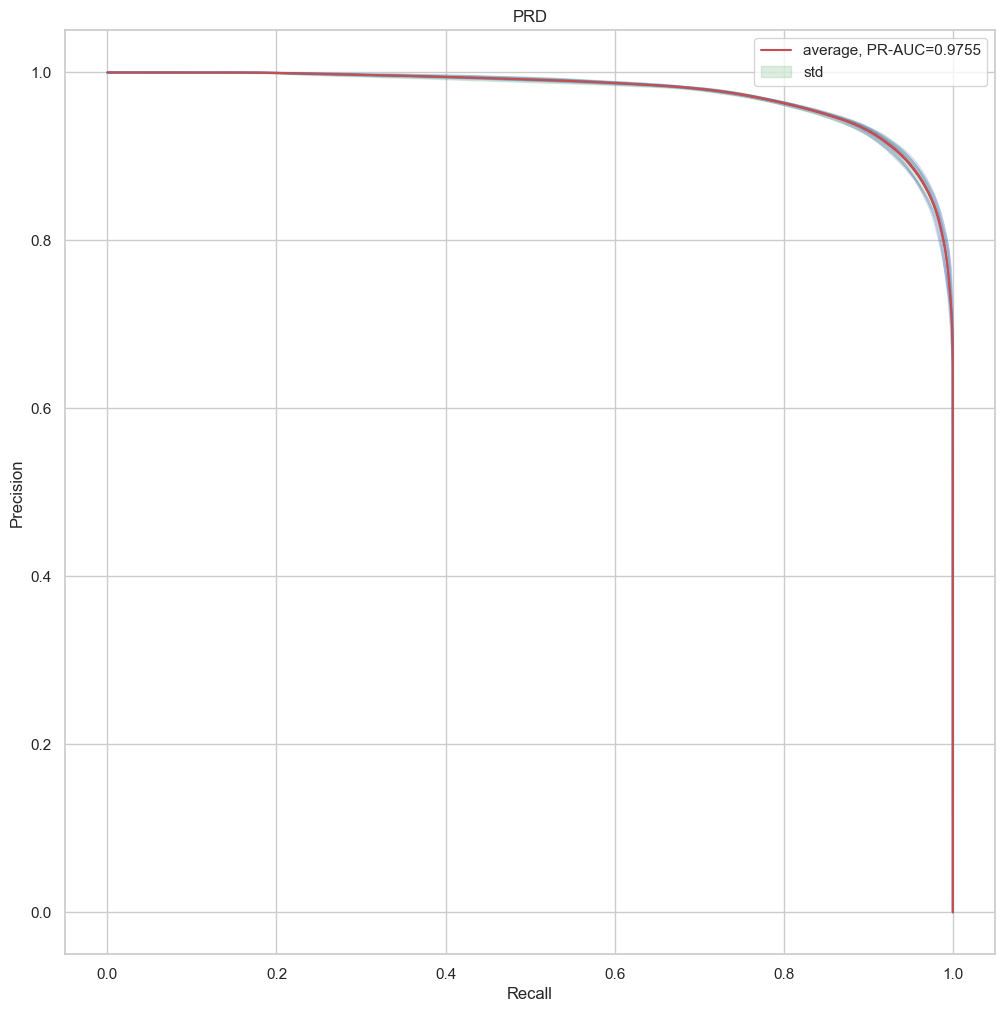


Evaluating model_4...
  -> Testing 50 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(96), np.int64(93), np.int64(90), np.int64(87), np.int64(84), np.int64(81), np.int64(78), np.int64(76), np.int64(73), np.int64(70), np.int64(68), np.int64(65), np.int64(63), np.int64(60), np.int64(57), np.int64(55), np.int64(53), np.int64(50), np.int64(48), np.int64(46), np.int64(43), np.int64(41), np.int64(39), np.int64(37), np.int64(35), np.int64(32), np.int64(30), np.int64(28), np.int64(26), np.int64(25), np.int64(23), np.int64(21), np.int64(19), np.int64(17), np.int64(16), np.int64(14), np.int64(13), np.int64(11), np.int64(10), np.int64(8), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_4_power_1.5_steps_50.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9452
PRD Physics AUC: -0.9866
------------------------------------


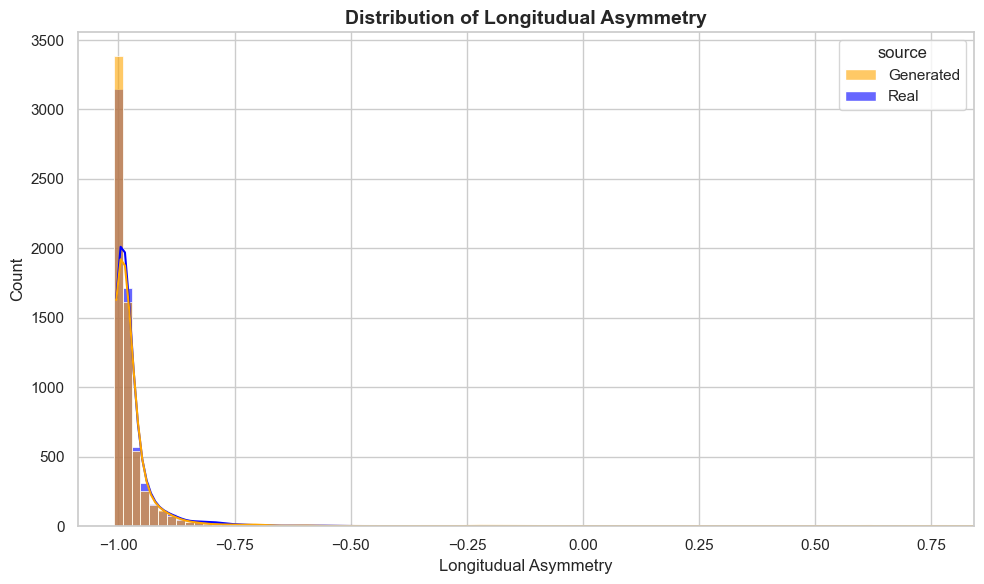

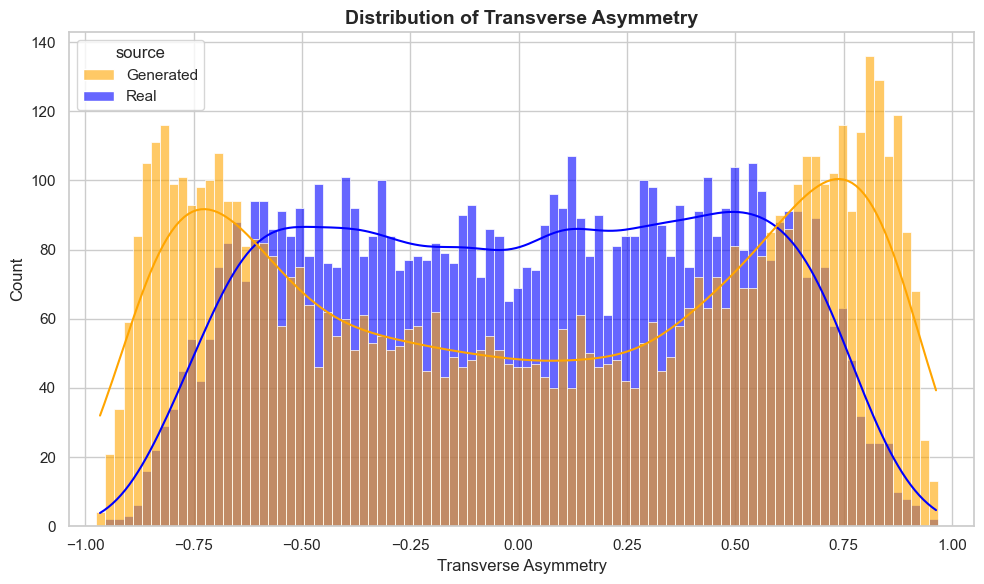

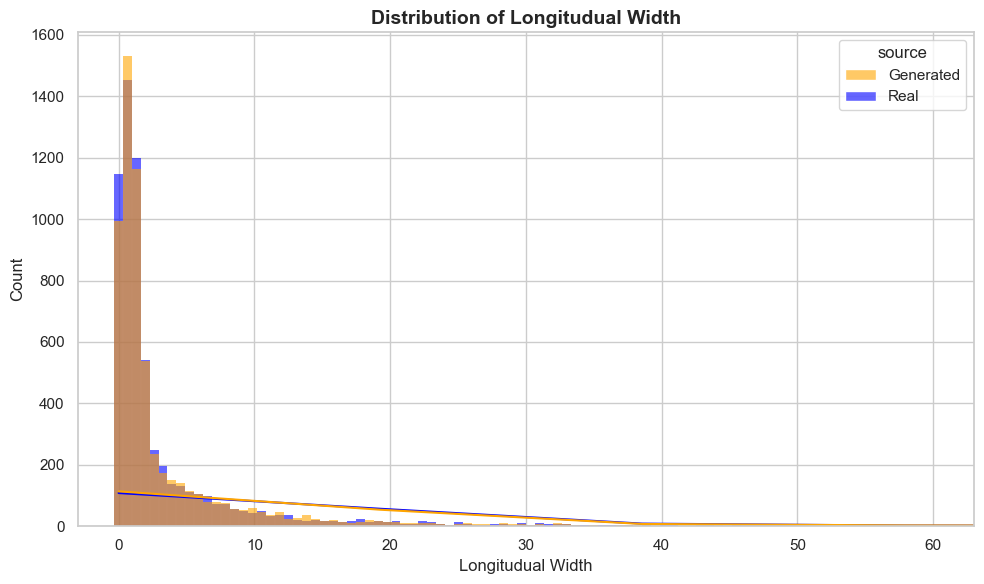

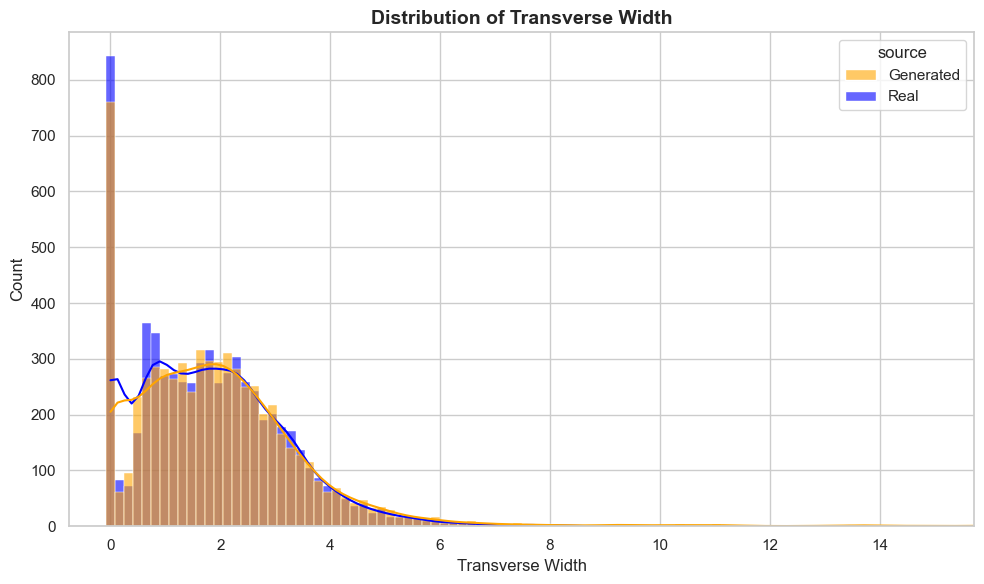

Energy PRD Curve


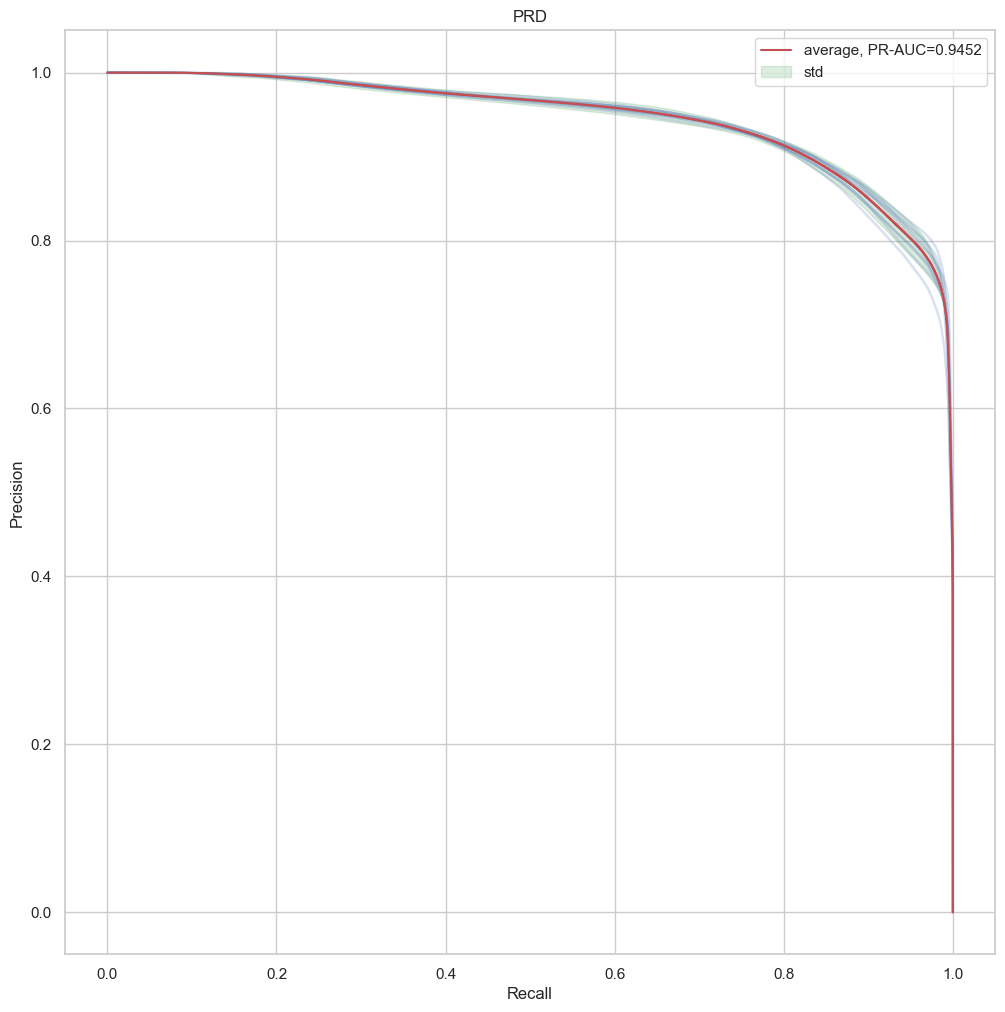

Physics PRD Curve


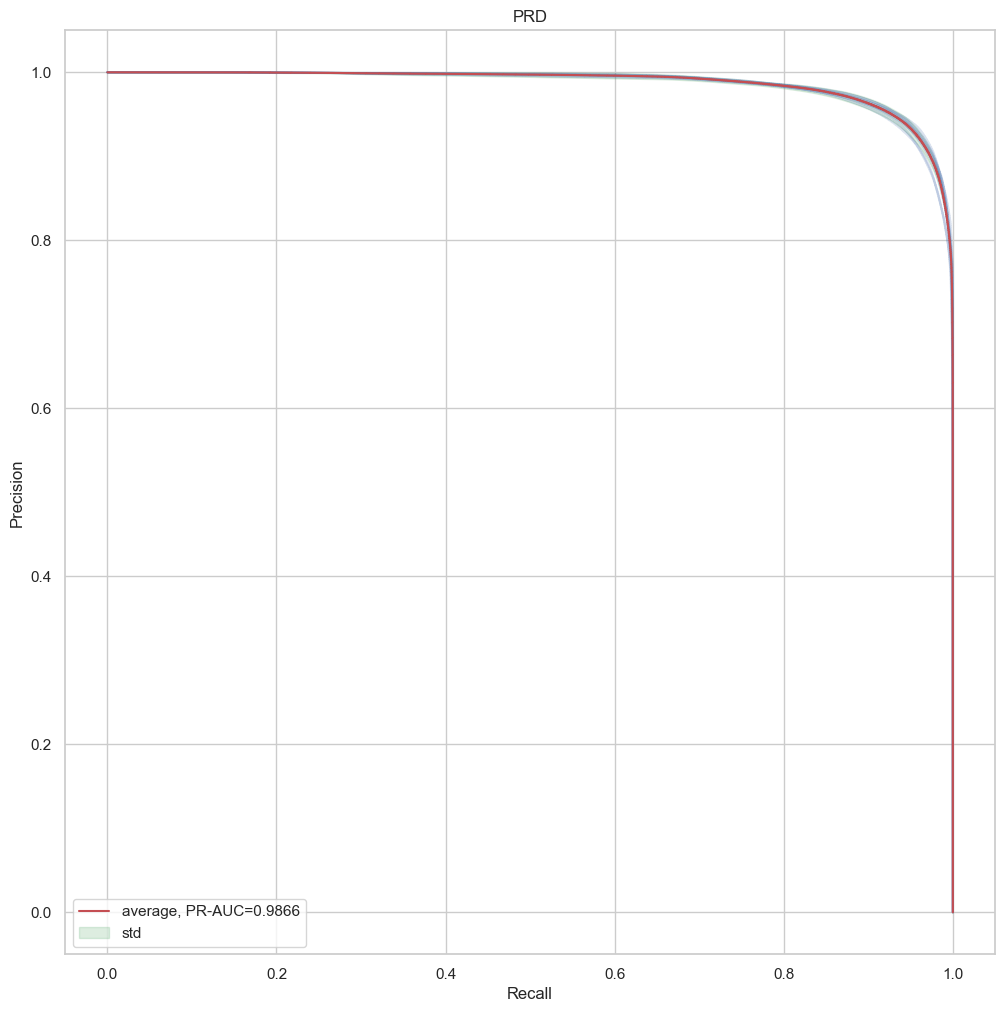

  -> Testing 25 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(93), np.int64(87), np.int64(81), np.int64(76), np.int64(70), np.int64(65), np.int64(60), np.int64(55), np.int64(50), np.int64(46), np.int64(41), np.int64(37), np.int64(32), np.int64(28), np.int64(25), np.int64(21), np.int64(17), np.int64(14), np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(2), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:37<00:00,  2.66it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_4_power_1.5_steps_25.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9460
PRD Physics AUC: -0.9891
------------------------------------


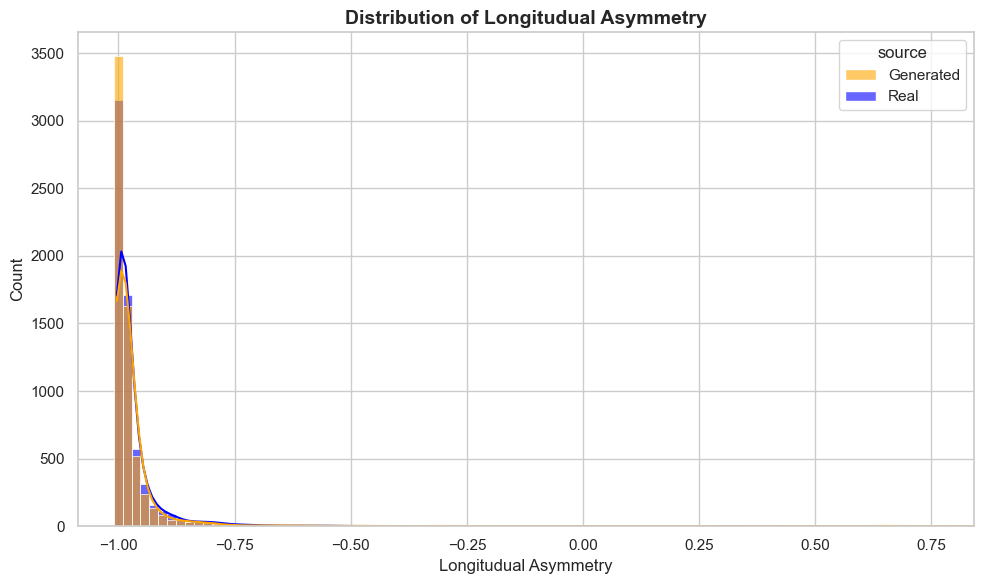

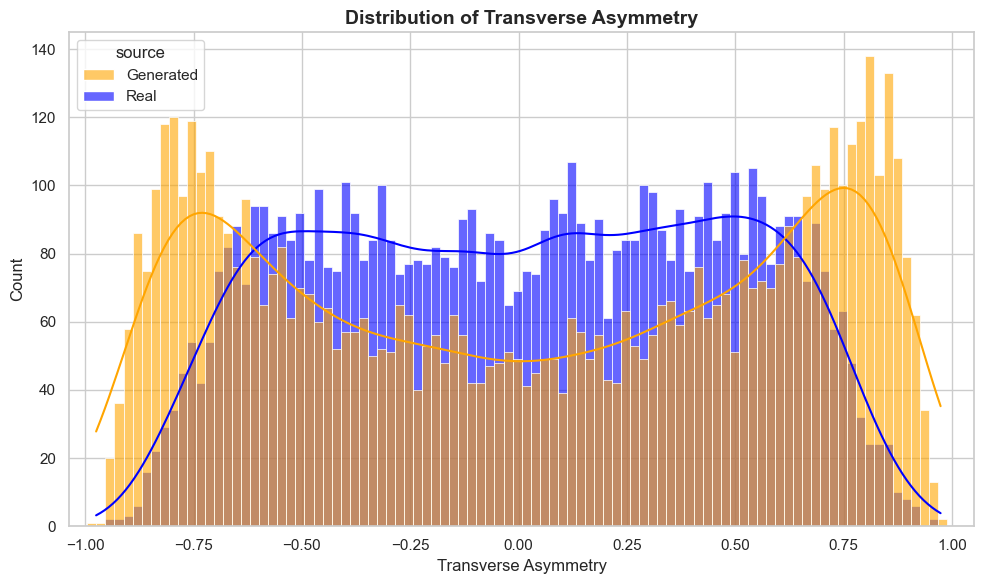

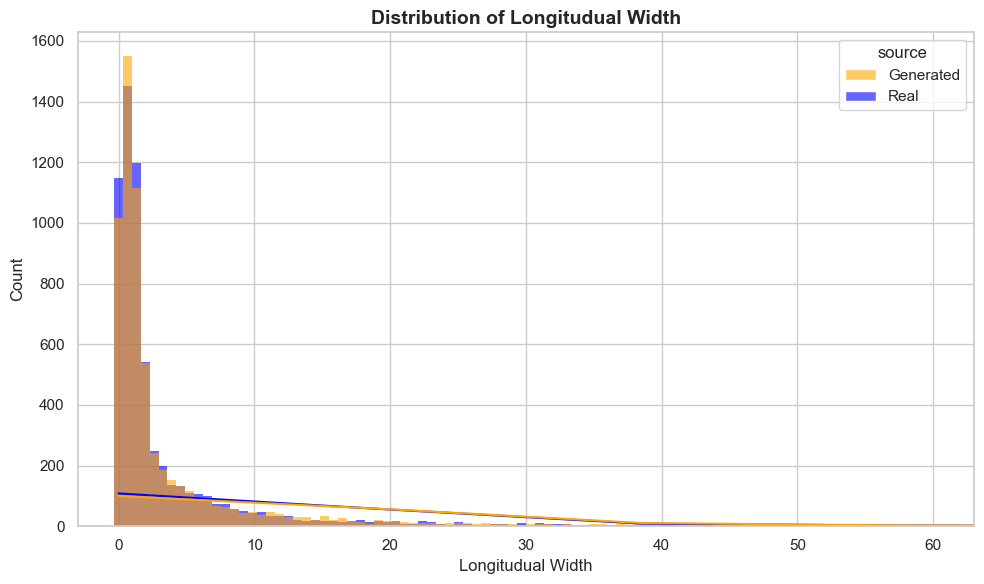

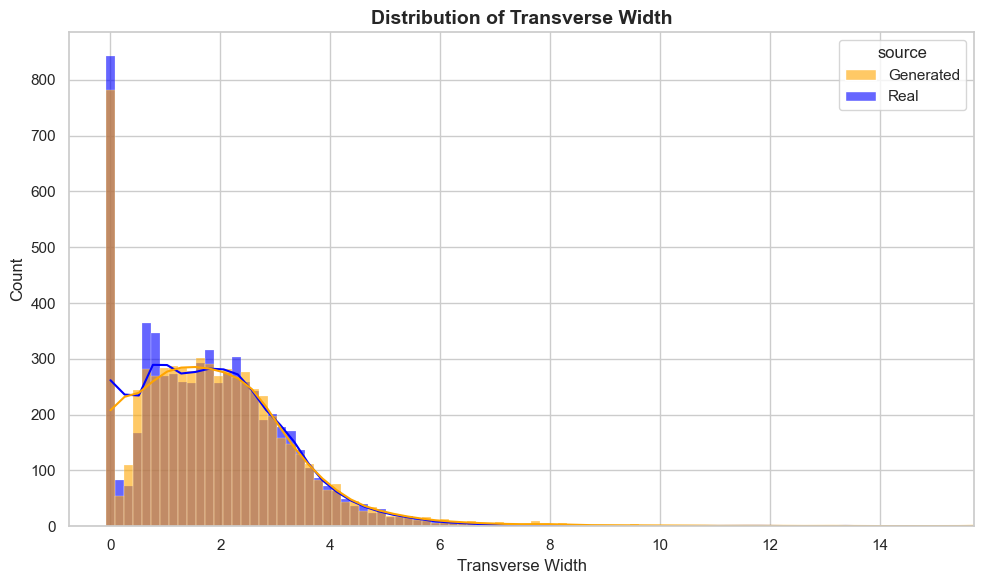

Energy PRD Curve


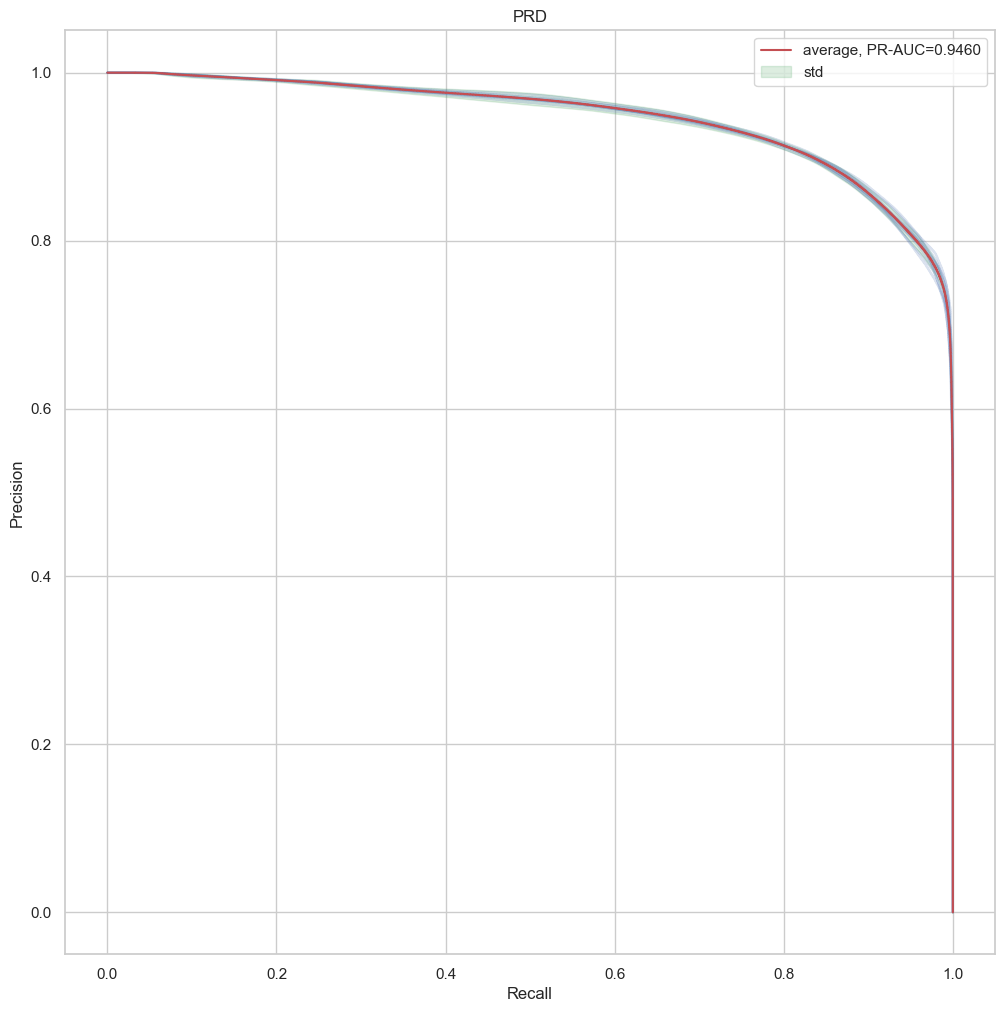

Physics PRD Curve


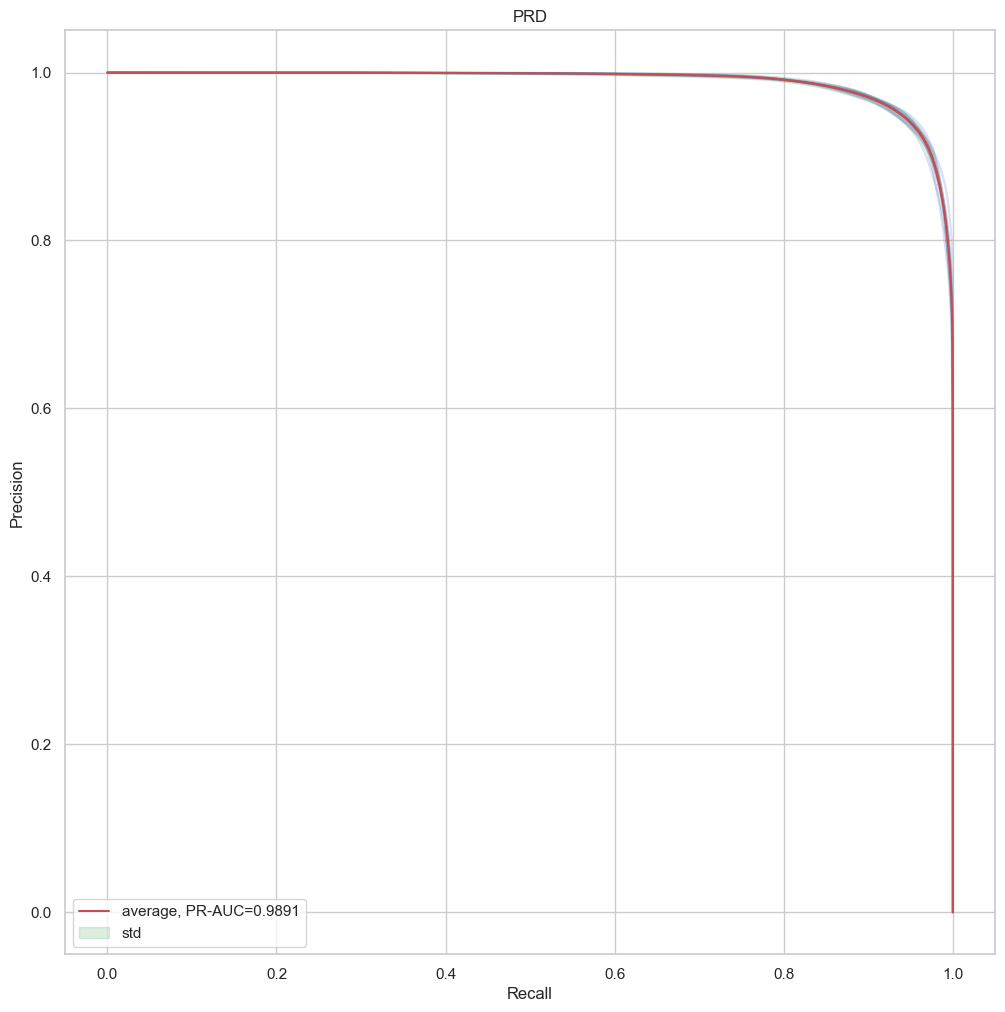

  -> Testing 15 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(89), np.int64(79), np.int64(70), np.int64(62), np.int64(53), np.int64(46), np.int64(38), np.int64(31), np.int64(25), np.int64(19), np.int64(13), np.int64(8), np.int64(4), np.int64(1), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_4_power_1.5_steps_15.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9462
PRD Physics AUC: -0.9877
------------------------------------


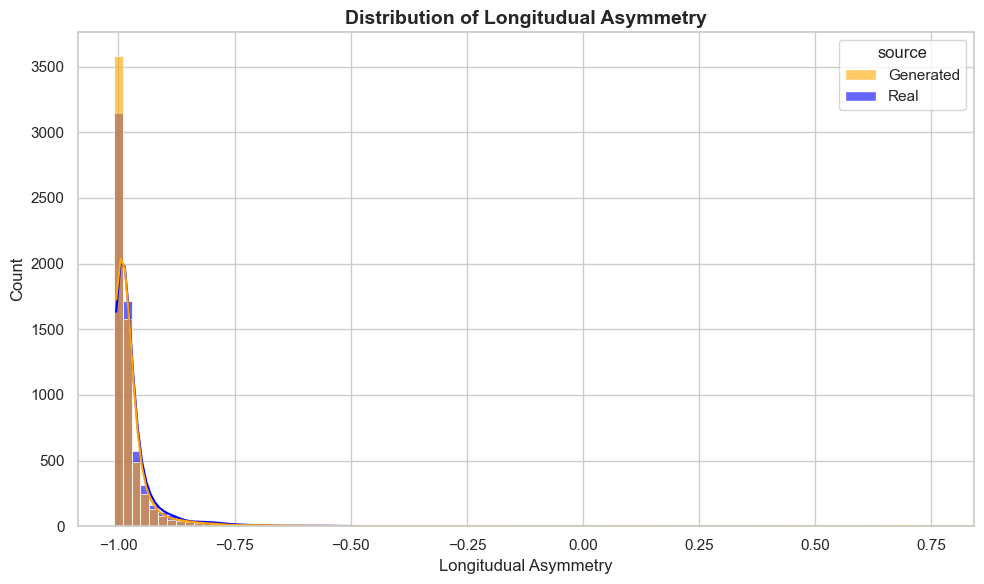

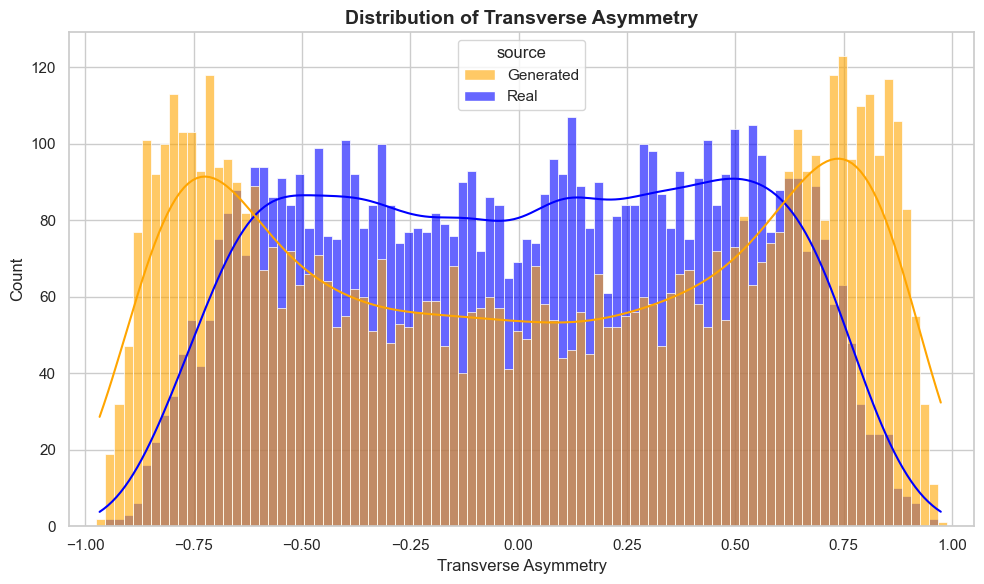

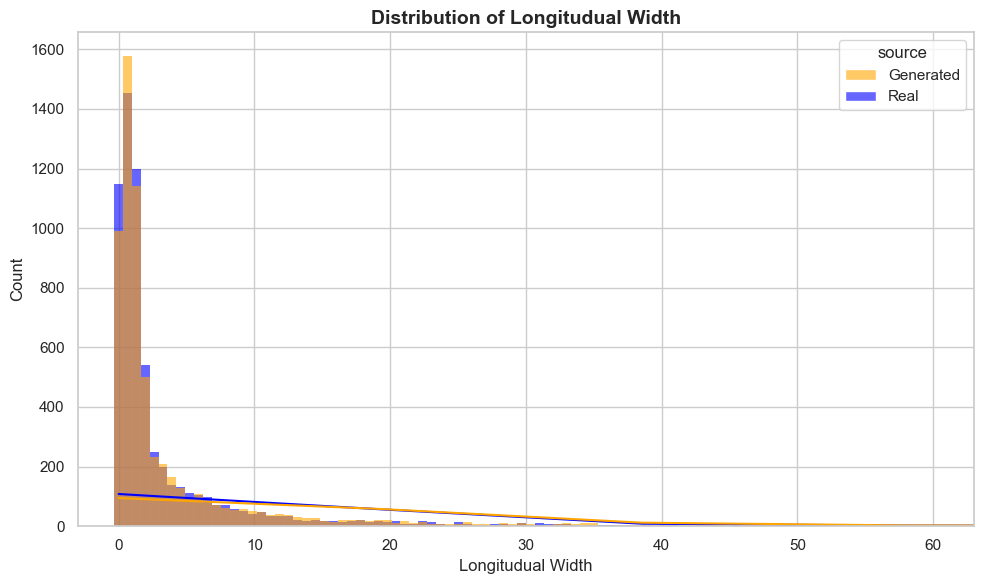

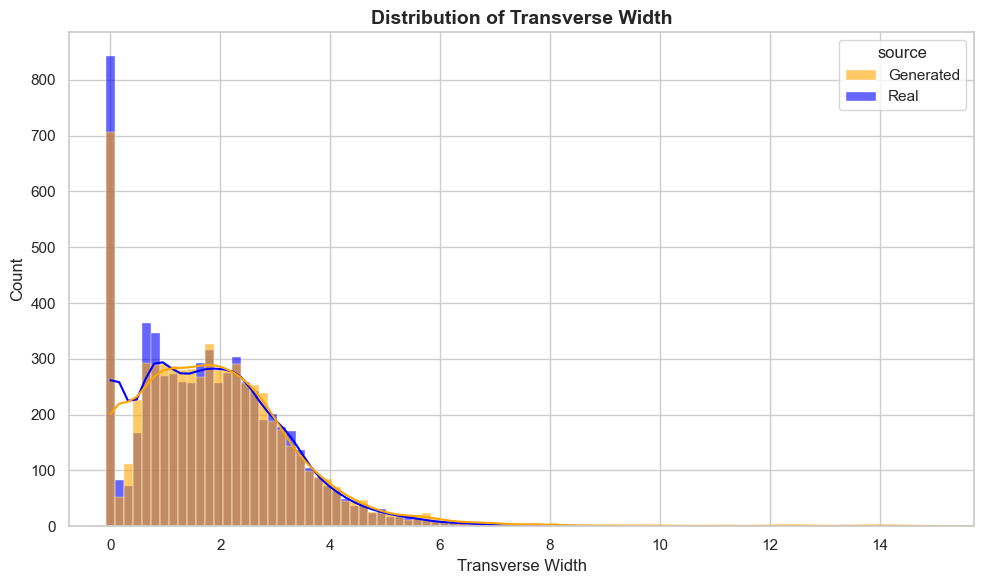

Energy PRD Curve


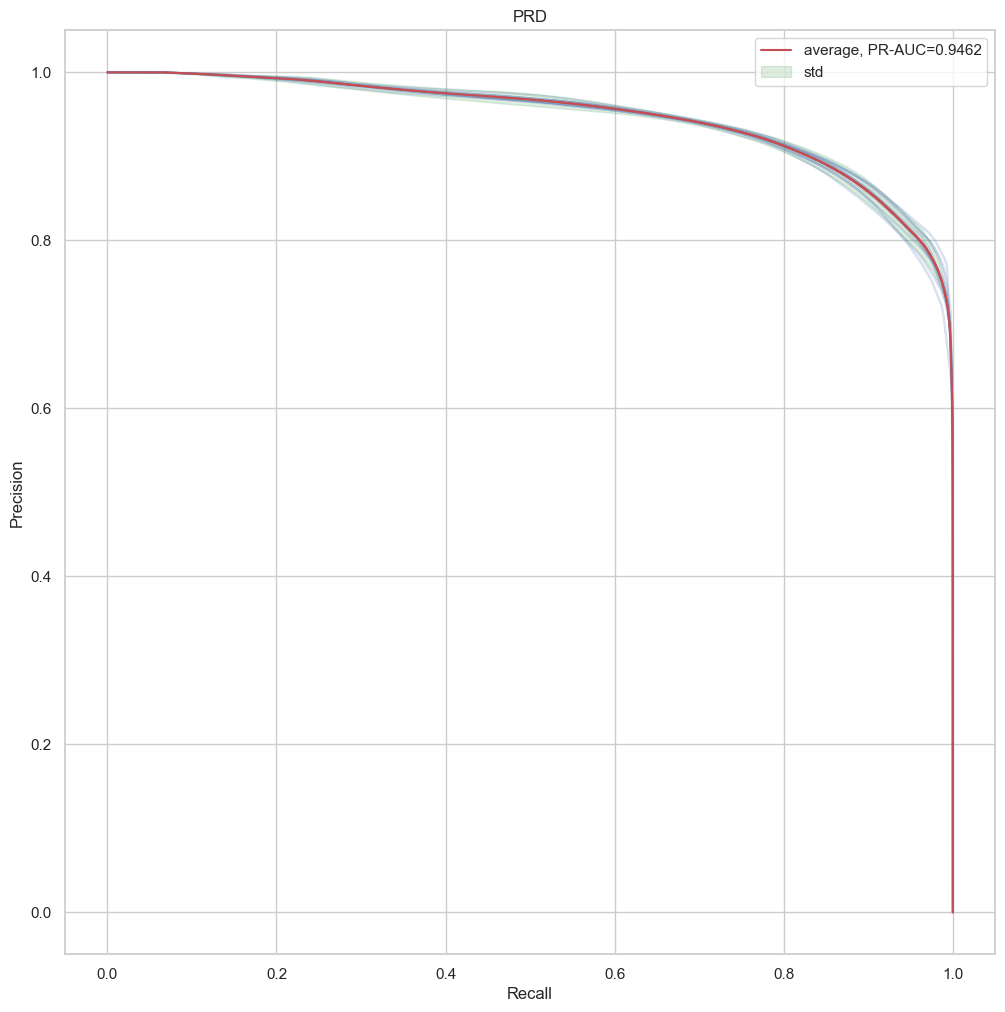

Physics PRD Curve


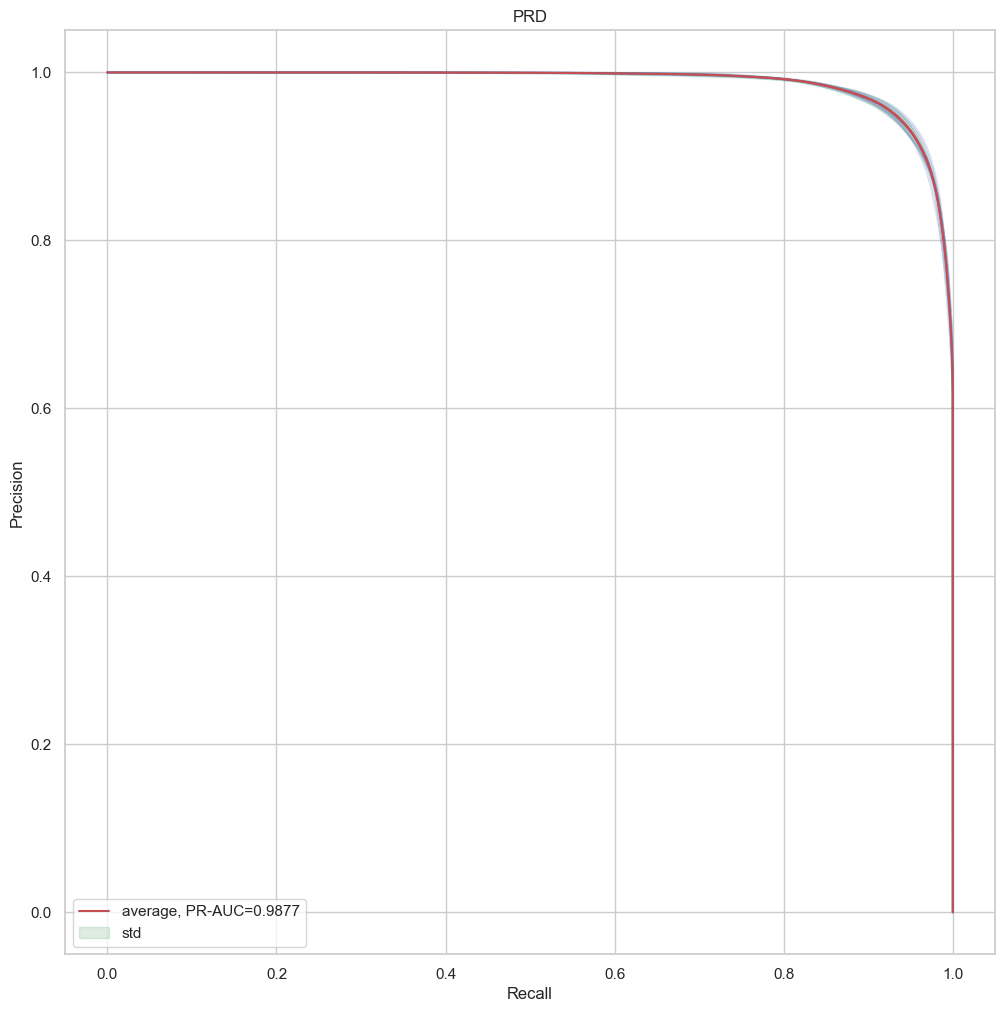

  -> Testing 10 steps...
Start Inference: Steps=100, Specific Steps=[np.int64(99), np.int64(84), np.int64(70), np.int64(57), np.int64(46), np.int64(35), np.int64(25), np.int64(16), np.int64(8), np.int64(3), np.int64(0)], Save All=False


Inference and Saving: 100%|██████████| 100/100 [00:16<00:00,  5.98it/s]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_4_power_1.5_steps_10.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9432
PRD Physics AUC: -0.9880
------------------------------------


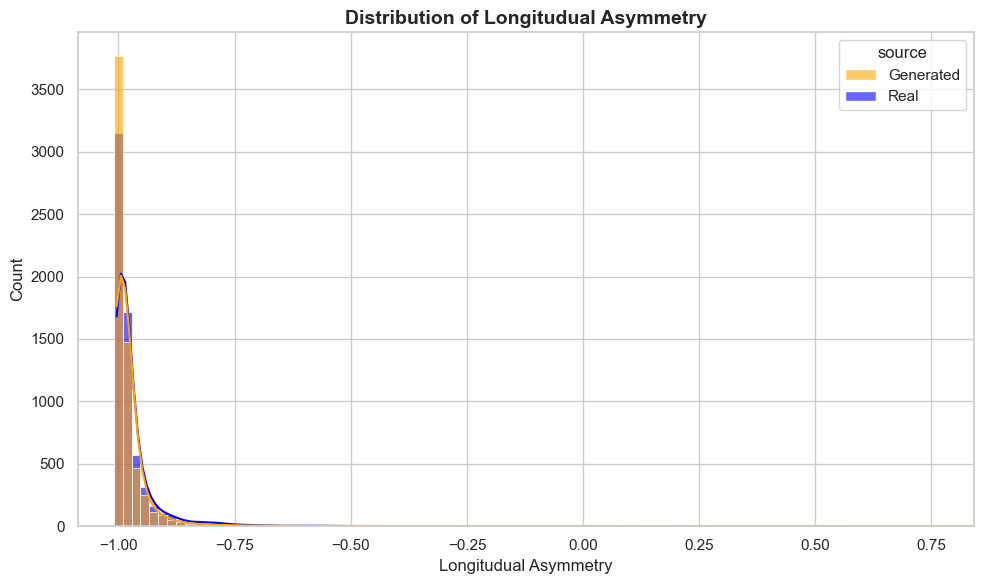

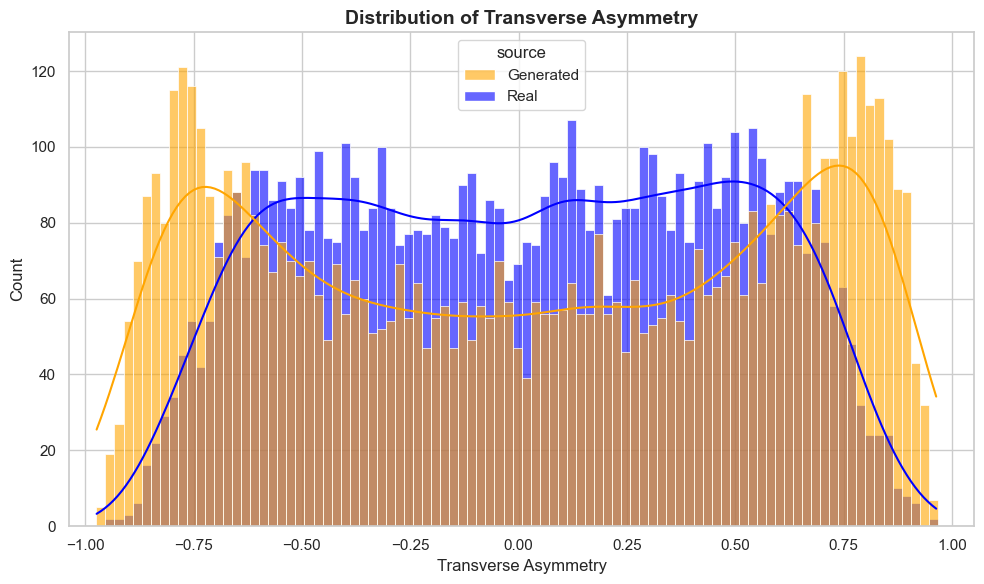

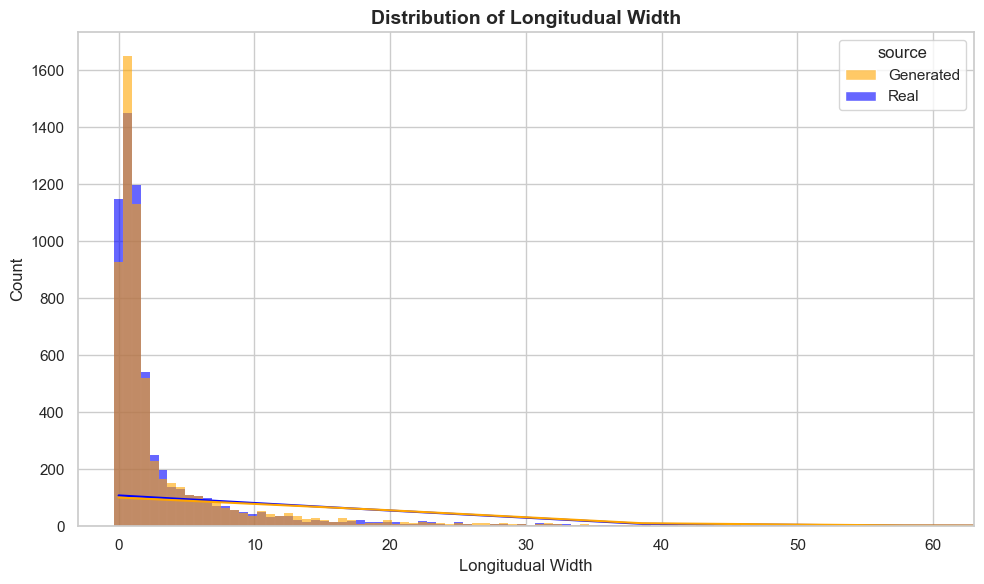

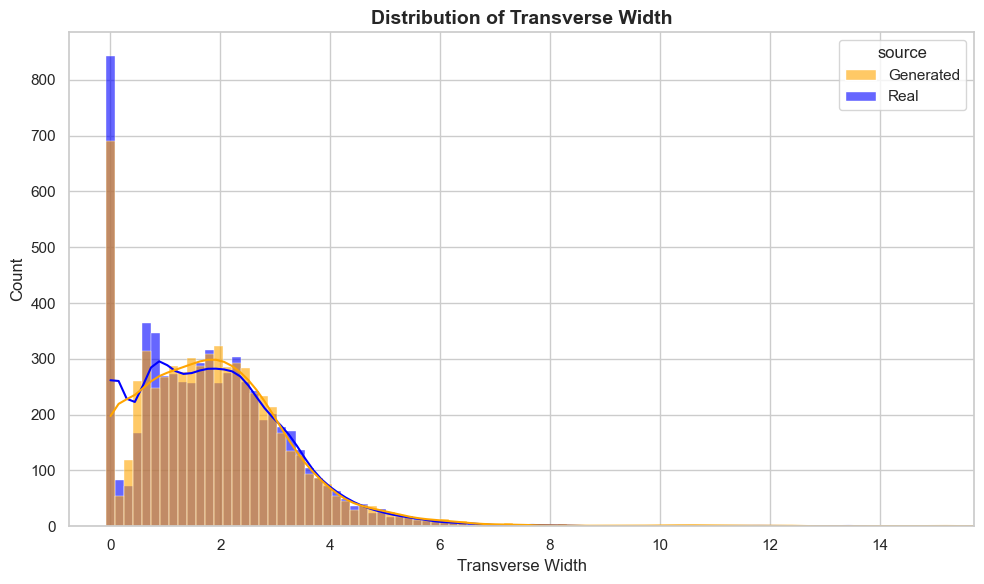

Energy PRD Curve


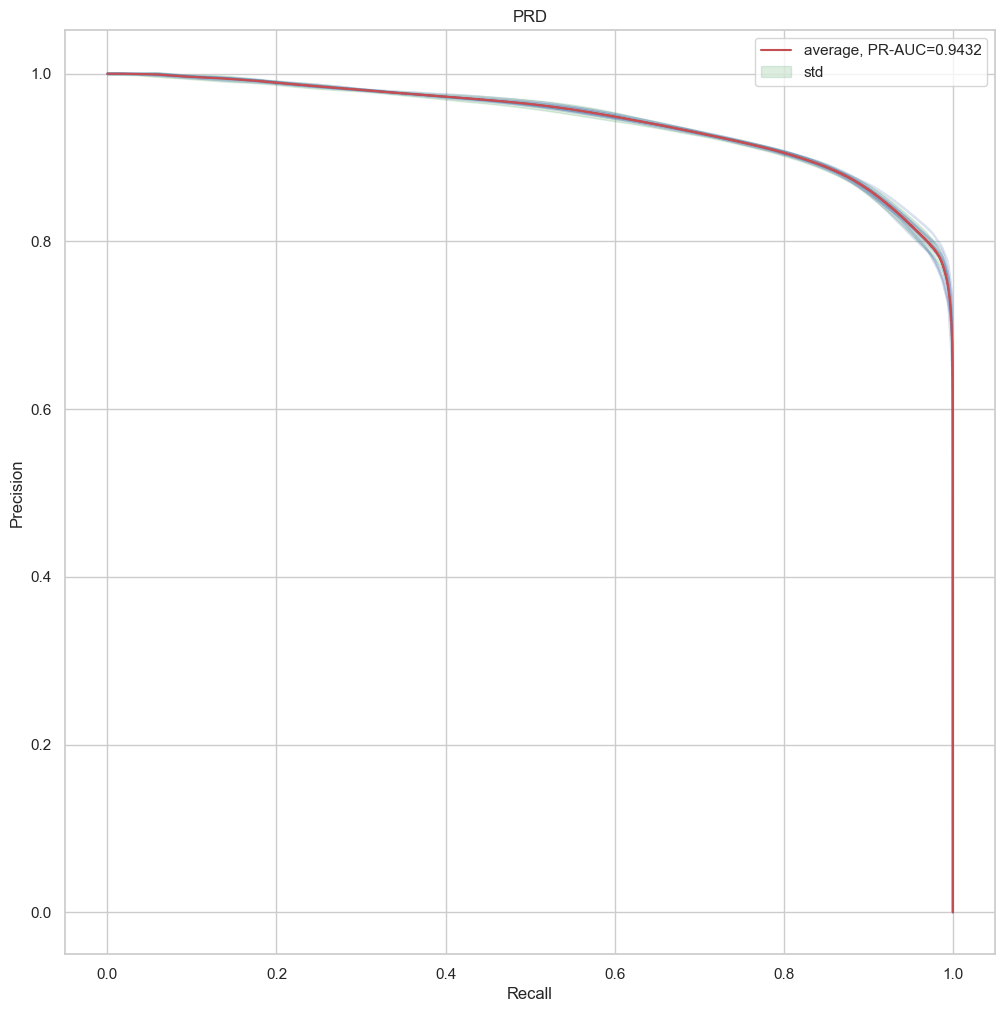

Physics PRD Curve


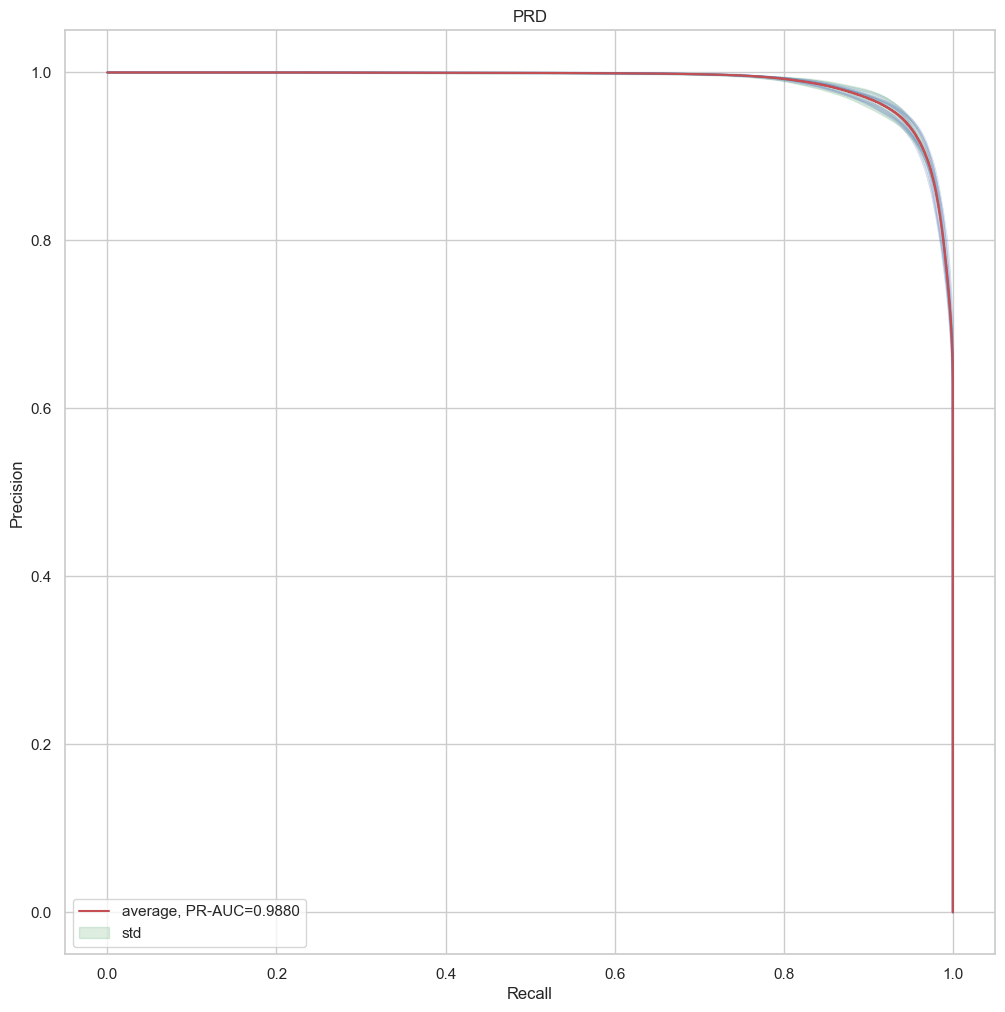


Оценка завершена. Переход к визуализации.


In [ ]:
print(f"Запуск серии экспериментов. Фиксированная степень: {p_value}")

# 1. Запуск инференса и сбор метрик
for name, config in MODEL_CONFIGS.items():
    print(f"\nEvaluating {name}...")
    
    # Инициализация модели
    if name == 'model_1':
        model = ConditionedUNet().to(device)
    else:
        model = ConditionedUNet(**config).to(device)
        
    checkpoint = torch.load(MODEL_PATHS[name], weights_only=True)
    model.load_state_dict(checkpoint, strict=False)
    
    for n_infer in steps_to_test:
        print(f"  -> Testing {n_infer} steps...")
        
        # Генерация нелинейного расписания
        schedule = get_power_schedule(n_total, n_infer, p_value)
        
        file_name = f"inference_results_{name}_{scenario_scheduling}_steps_{n_infer}.npz"
        filename = os.path.join("inference_results", file_name)
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        
        # Инференс с кастомным расписанием
        calodiff.inference_with_saving(
            model=model,
            dataloader=valid_loader,
            n_steps=n_total,
            sampling_method='ddim', 
            device=device, 
            cache_interval=1,
            specific_steps=schedule,
            output_path=filename,
            save_all_steps=False
        )

        # Загрузка результатов генерации
        with np.load(filename) as new_data:
            images = new_data['images']
            labels = new_data['labels']
            conditions = new_data['conditions']
        
        images_tensor = torch.tensor(images, dtype=torch.float32)
        images_original_scale = torch.expm1(images_tensor)
        labels_tensor = torch.tensor(labels)
        
        real_mask = (labels_tensor == 1)
        generated_mask = (labels_tensor == 0)
        
        real_images = images_original_scale[real_mask]
        generated_images = images_original_scale[generated_mask]
        conditions_for_metrics = torch.tensor(conditions[generated_mask], dtype=torch.float32) 
        
        # Расчет физических метрик
        metrics = calodiff.evaluate_and_visualize_physics_metrics(
            gen_images=generated_images,
            real_images=real_images,
            conditions=conditions_for_metrics
        )
        
        auc_energy, current_prd_auc_energy_std = calodiff.calculate_pr_metrics(metrics['precision_energy'], metrics['recall_energy'])
        auc_physics, current_prd_auc_physics_std = calodiff.calculate_pr_metrics(metrics['precision_physics'], metrics['recall_physics'])
        
        # Сохранение результатов
        results[name]['PRD_energy_AUC'].append(auc_energy)
        results[name]['PRD_physics_AUC'].append(auc_physics)
        results[name]['PRD_energy_AUC_std'].append(current_prd_auc_energy_std)
        results[name]['PRD_physics_AUC_std'].append(current_prd_auc_physics_std)

print("\nОценка завершена. Переход к визуализации.")

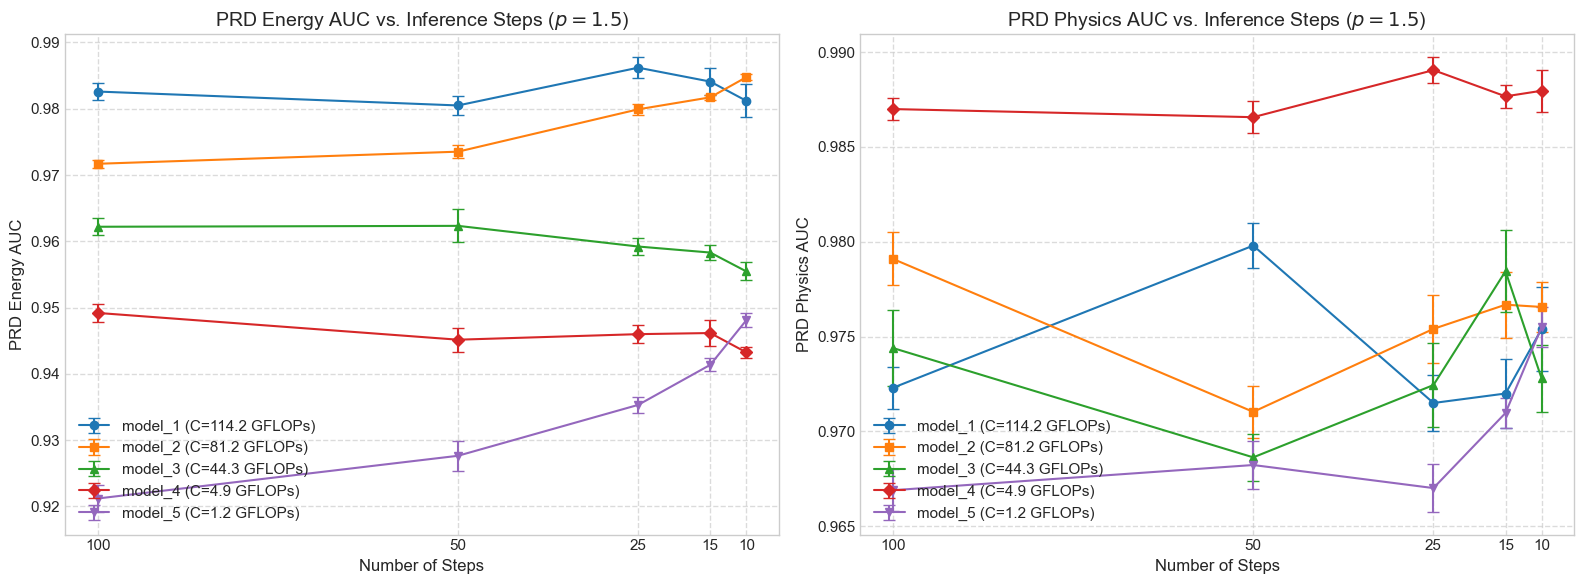

In [ ]:
all_steps = [100, 50, 25, 15, 10]
sorted_indices = np.argsort(all_steps)
sorted_steps = np.array(all_steps)[sorted_indices]
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'v']

for idx, (name, data) in enumerate(results.items()):

    energy_auc = np.array(data['PRD_energy_AUC'])[sorted_indices]
    energy_std = np.array(data['PRD_energy_AUC_std'])[sorted_indices]
    
    physics_auc = np.array(data['PRD_physics_AUC'])[sorted_indices]
    physics_std = np.array(data['PRD_physics_AUC_std'])[sorted_indices]
    
    ax1.errorbar(sorted_steps, energy_auc, yerr=energy_std, 
                 label=f"{name} (C={data['complexity']:.1f} GFLOPs)", 
                 color=colors[idx], marker=markers[idx], capsize=4, 
                 linewidth=1.5, markersize=6)
    
    ax2.errorbar(sorted_steps, physics_auc, yerr=physics_std, 
                 label=f"{name} (C={data['complexity']:.1f} GFLOPs)", 
                 color=colors[idx], marker=markers[idx], capsize=4, 
                 linewidth=1.5, markersize=6)

ax1.set_title(r'PRD Energy AUC vs. Inference Steps ($p=1.5$)', fontsize=14)
ax1.set_xlabel('Number of Steps', fontsize=12)
ax1.set_ylabel('PRD Energy AUC', fontsize=12)
ax1.set_xticks(sorted_steps)
ax1.invert_xaxis() 
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title(r'PRD Physics AUC vs. Inference Steps ($p=1.5$)', fontsize=14)
ax2.set_xlabel('Number of Steps', fontsize=12)
ax2.set_ylabel('PRD Physics AUC', fontsize=12)
ax2.set_xticks(sorted_steps)
ax2.invert_xaxis()
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('inference_acceleration_metrics.png', dpi=300, bbox_inches='tight')
plt.show()